# Recovered Diamond EDA Notebook

Moved from C:\Users\alihu\DiamaondCaptsoneANN.ipynb. Original outputs are preserved. File paths are updated for sideEDA; run the setup cell first. Historical experiments have not been rerun.


In [ ]:
from pathlib import Path
PROJECT_ROOT = next(folder for folder in (Path.cwd(), *Path.cwd().parents)
                    if (folder / "src" / "classification" / "pipeline.py").is_file())
EDA_DIR = PROJECT_ROOT / "sideEDA"


In [2]:
import os
from pathlib import Path

# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_DIR = Path(str(PROJECT_ROOT))

DATA_DIR = PROJECT_DIR / "data"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
SRC_DIR = PROJECT_DIR / "src"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / str(EDA_DIR / 'outputs')
FIGURE_DIR = OUTPUT_DIR / "figures"
REPORT_DIR = OUTPUT_DIR / "reports"
KAGGLE_CACHE_DIR = PROJECT_DIR / "kaggle_cache"

# Create folders automatically
for folder in [
    DATA_DIR,
    NOTEBOOK_DIR,
    SRC_DIR,
    MODEL_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
    REPORT_DIR,
    KAGGLE_CACHE_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# Tell KaggleHub to store downloaded files inside this project
os.environ["KAGGLEHUB_CACHE"] = str(KAGGLE_CACHE_DIR)

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)
print("Models directory:", MODEL_DIR)
print("Outputs directory:", OUTPUT_DIR)
print("Kaggle cache:", KAGGLE_CACHE_DIR)

Project directory: C:\Users\alihu\Projects\ML Course\Diamond
Data directory: C:\Users\alihu\Projects\ML Course\Diamond\data
Models directory: C:\Users\alihu\Projects\ML Course\Diamond\models
Outputs directory: C:\Users\alihu\Projects\ML Course\Diamond\outputs
Kaggle cache: C:\Users\alihu\Projects\ML Course\Diamond\kaggle_cache


In [5]:
from pathlib import Path

import kagglehub
import pandas as pd

# ============================================================
# PROJECT PATH
# ============================================================

PROJECT_DIR = Path(str(PROJECT_ROOT))
DATA_DIR = PROJECT_DIR / "data"

DATA_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# DOWNLOAD DATASET
# ============================================================

download_path = kagglehub.dataset_download(
    "shivam2503/diamonds",
    output_dir=str(DATA_DIR),
)

print("Dataset downloaded to:")
print(download_path)

# ============================================================
# FIND CSV FILE
# ============================================================

csv_files = list(DATA_DIR.rglob("*.csv"))

if not csv_files:
    raise FileNotFoundError("No CSV file was found inside the data folder.")

DIAMONDS_PATH = csv_files[0]

print("\nCSV file found:")
print(DIAMONDS_PATH)

# ============================================================
# LOAD CSV INTO PANDAS
# ============================================================

df = pd.read_csv(
    DIAMONDS_PATH,
    encoding="latin1"
)

# ============================================================
# CHECK DATASET
# ============================================================

print("\nDataset loaded successfully.")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset downloaded to:
C:\Users\alihu\Projects\ML Course\Diamond\data

CSV file found:
C:\Users\alihu\Projects\ML Course\Diamond\data\diamonds.csv

Dataset loaded successfully.
Shape: (53940, 11)

First 5 rows:
   Unnamed: 0  carat      cut color clarity  depth  table  price     x     y  \
0           1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98   
1           2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84   
2           3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07   
3           4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23   
4           5   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35   

      z  
0  2.43  
1  2.31  
2  2.31  
3  2.63  
4  2.75  

Columns:
['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

Data types:
Unnamed: 0      int64
carat         float64
cut            object
color          object
clarity        object
depth         float64


In [10]:
# ============================================================
# DROP UNNECESSARY INDEX COLUMN
# ============================================================

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Show first 50 rows
df.head(50)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [7]:
df.shape

(53940, 11)

In [8]:
# ============================================================
# QUESTION 1: HOW MANY CLARITY TYPES ARE THERE?
# ============================================================

clarity_counts = df["clarity"].value_counts()

print("Number of clarity classes:", df["clarity"].nunique())

print("\nClarity classes:")
print(df["clarity"].unique())

print("\nNumber of diamonds in each clarity class:")
print(clarity_counts)

print("\nPercentage of dataset:")
print((df["clarity"].value_counts(normalize=True) * 100).round(2))

Number of clarity classes: 8

Clarity classes:
['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']

Number of diamonds in each clarity class:
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64

Percentage of dataset:
clarity
SI1     24.22
VS2     22.73
SI2     17.04
VS1     15.15
VVS2     9.39
VVS1     6.78
IF       3.32
I1       1.37
Name: proportion, dtype: float64


In [9]:
# ============================================================
# QUESTION 2: WHAT DOES THE PRICE DISTRIBUTION LOOK LIKE?
# ============================================================

price = df["price"]

print("DIAMOND PRICE ANALYSIS")
print("=" * 50)

print(f"Minimum price:        ${price.min():,.2f}")
print(f"25th percentile:      ${price.quantile(0.25):,.2f}")
print(f"50th percentile:      ${price.quantile(0.50):,.2f}")
print(f"75th percentile:      ${price.quantile(0.75):,.2f}")
print(f"90th percentile:      ${price.quantile(0.90):,.2f}")
print(f"Maximum price:        ${price.max():,.2f}")

print("\nCENTRAL TENDENCY")
print("=" * 50)

print(f"Mean / Average:       ${price.mean():,.2f}")
print(f"Median:               ${price.median():,.2f}")
print(f"Mode:                 ${price.mode().iloc[0]:,.2f}")

print("\nSPREAD")
print("=" * 50)

print(f"Variance:              {price.var():,.2f}")
print(f"Standard deviation:    ${price.std():,.2f}")

DIAMOND PRICE ANALYSIS
Minimum price:        $326.00
25th percentile:      $950.00
50th percentile:      $2,401.00
75th percentile:      $5,324.25
90th percentile:      $9,821.00
Maximum price:        $18,823.00

CENTRAL TENDENCY
Mean / Average:       $3,932.80
Median:               $2,401.00
Mode:                 $605.00

SPREAD
Variance:              15,915,629.42
Standard deviation:    $3,989.44


In [11]:
# ============================================================
# EDA: HOW DOES EACH NUMERIC FEATURE DIFFER BY CLARITY CLASS?
# ============================================================

import pandas as pd

# Numeric features we want to compare against clarity
numeric_features = [
    "carat",
    "depth",
    "table",
    "price",
    "x",
    "y",
    "z",
]

# Order clarity from lowest to highest
clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

# ============================================================
# ANALYZE EACH FEATURE
# ============================================================

for feature in numeric_features:

    print("\n")
    print("=" * 120)
    print(f"FEATURE ANALYSIS: {feature.upper()} BY CLARITY")
    print("=" * 120)

    # Group the feature by clarity and calculate statistics
    feature_summary = df.groupby("clarity", observed=True)[feature].agg(
        Count="count",
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max",
        Variance="var",
        Std_Dev="std",
    )

    # Add percentiles
    feature_summary["P10"] = df.groupby("clarity", observed=True)[feature].quantile(0.10)
    feature_summary["P25"] = df.groupby("clarity", observed=True)[feature].quantile(0.25)
    feature_summary["P75"] = df.groupby("clarity", observed=True)[feature].quantile(0.75)
    feature_summary["P90"] = df.groupby("clarity", observed=True)[feature].quantile(0.90)

    # Full range: maximum - minimum
    feature_summary["Range"] = (
        feature_summary["Maximum"] - feature_summary["Minimum"]
    )

    # Interquartile range: where the middle 50% of observations live
    feature_summary["IQR"] = (
        feature_summary["P75"] - feature_summary["P25"]
    )

    # Reorder clarity from lowest to highest
    feature_summary = feature_summary.reindex(clarity_order)

    # Round values so the table is easier to read
    feature_summary = feature_summary.round(2)

    print(feature_summary)



FEATURE ANALYSIS: CARAT BY CLARITY
         Count  Mean  Median  Minimum  Maximum  Variance  Std_Dev   P10   P25  \
clarity                                                                         
I1         741  1.28    1.12     0.30     5.01      0.40     0.63  0.70  0.96   
SI2       9194  1.08    1.01     0.20     3.04      0.27     0.52  0.43  0.72   
SI1      13065  0.85    0.76     0.21     2.57      0.20     0.45  0.33  0.50   
VS2      12258  0.76    0.63     0.20     3.51      0.20     0.45  0.31  0.38   
VS1       8171  0.73    0.57     0.23     2.59      0.18     0.42  0.31  0.38   
VVS2      5066  0.60    0.44     0.23     2.07      0.13     0.36  0.28  0.32   
VVS1      3655  0.50    0.39     0.23     2.31      0.09     0.30  0.29  0.31   
IF        1790  0.51    0.35     0.23     2.29      0.10     0.31  0.30  0.31   

          P75   P90  Range   IQR  
clarity                           
I1       1.51  2.06   4.71  0.55  
SI2      1.26  2.01   2.84  0.54  
SI1      1.0

In [12]:
# ============================================================
# DATA CLEANING: DIAMOND DIMENSIONS (x, y, z)
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. CREATE A COPY
# ------------------------------------------------------------
# Keep the original df untouched in case we need to compare later.

clean_df = df.copy()

print("=" * 70)
print("DIAMOND DIMENSION CLEANING")
print("=" * 70)

print(f"\nOriginal rows: {len(clean_df):,}")


# ------------------------------------------------------------
# 2. DROP THE UNUSED INDEX COLUMN
# ------------------------------------------------------------

clean_df = clean_df.drop(columns=["Unnamed: 0"], errors="ignore")


# ------------------------------------------------------------
# 3. CHECK FOR IMPOSSIBLE DIMENSIONS
# ------------------------------------------------------------
# x = length
# y = width
# z = physical depth
#
# A real diamond cannot have a dimension <= 0.

dimension_columns = ["x", "y", "z"]

invalid_dimensions = (clean_df[dimension_columns] <= 0).any(axis=1)

print("\nIMPOSSIBLE DIMENSIONS")
print("-" * 70)

print(f"Rows with x, y, or z <= 0: {invalid_dimensions.sum():,}")

if invalid_dimensions.any():
    print("\nExamples:")
    print(
        clean_df.loc[
            invalid_dimensions,
            ["carat", "clarity", "price", "x", "y", "z"]
        ].head(20)
    )


# ------------------------------------------------------------
# 4. REMOVE IMPOSSIBLE DIMENSION ROWS
# ------------------------------------------------------------
# These are not normal statistical outliers.
# A diamond with zero length/width/depth is invalid data.

clean_df = clean_df.loc[~invalid_dimensions].copy()

print(f"\nRows after removing impossible dimensions: {len(clean_df):,}")


# ------------------------------------------------------------
# 5. CHECK FOR EXTREME VALUES USING IQR
# ------------------------------------------------------------
# We DO NOT automatically delete these.
#
# IQR = P75 - P25
#
# A 3 × IQR threshold is deliberately conservative.
# It identifies extremely unusual values for us to investigate.

extreme_masks = {}

print("\n")
print("=" * 70)
print("EXTREME DIMENSION CHECK")
print("=" * 70)

for column in dimension_columns:

    q1 = clean_df[column].quantile(0.25)
    q3 = clean_df[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - (3 * iqr)
    upper_bound = q3 + (3 * iqr)

    extreme_mask = (
        (clean_df[column] < lower_bound)
        | (clean_df[column] > upper_bound)
    )

    extreme_masks[column] = extreme_mask

    print(f"\n{column.upper()}")
    print("-" * 30)
    print(f"P25:              {q1:.2f}")
    print(f"P75:              {q3:.2f}")
    print(f"IQR:              {iqr:.2f}")
    print(f"Lower threshold:  {lower_bound:.2f}")
    print(f"Upper threshold:  {upper_bound:.2f}")
    print(f"Extreme rows:     {extreme_mask.sum():,}")


# ------------------------------------------------------------
# 6. COMBINE ALL EXTREME FLAGS
# ------------------------------------------------------------

any_extreme = (
    extreme_masks["x"]
    | extreme_masks["y"]
    | extreme_masks["z"]
)

extreme_df = clean_df.loc[
    any_extreme,
    [
        "carat",
        "cut",
        "color",
        "clarity",
        "price",
        "x",
        "y",
        "z",
    ]
].copy()


# ------------------------------------------------------------
# 7. SHOW THE MOST SUSPICIOUS VALUES
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("ROWS FLAGGED FOR INVESTIGATION")
print("=" * 70)

print(f"\nTotal extreme rows: {len(extreme_df):,}")

print("\nLargest Y values:")
print(
    clean_df[
        ["carat", "clarity", "price", "x", "y", "z"]
    ]
    .sort_values("y", ascending=False)
    .head(15)
)

print("\nLargest Z values:")
print(
    clean_df[
        ["carat", "clarity", "price", "x", "y", "z"]
    ]
    .sort_values("z", ascending=False)
    .head(15)
)

print("\nLargest X values:")
print(
    clean_df[
        ["carat", "clarity", "price", "x", "y", "z"]
    ]
    .sort_values("x", ascending=False)
    .head(15)
)


# ------------------------------------------------------------
# 8. SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("CLEANING SUMMARY")
print("=" * 70)

print(f"Original rows:                 {len(df):,}")
print(f"Impossible dimension rows:     {invalid_dimensions.sum():,}")
print(f"Rows remaining:                {len(clean_df):,}")
print(f"Extreme rows flagged:          {len(extreme_df):,}")

print(
    "\nNOTE: Extreme values were FLAGGED, not automatically removed."
)


# ------------------------------------------------------------
# 9. SAVE RESULTS
# ------------------------------------------------------------

PROJECT_DIR = Path(str(PROJECT_ROOT))
DATA_DIR = PROJECT_DIR / "data"

DATA_DIR.mkdir(parents=True, exist_ok=True)

clean_path = DATA_DIR / str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_cleaned.csv')
extreme_path = DATA_DIR / str(PROJECT_ROOT / 'sideEDA/data/diagnostics/diamonds_extreme_dimensions.csv')

clean_df.to_csv(clean_path, index=False)
extreme_df.to_csv(extreme_path, index=False)

print("\nFiles saved:")
print(clean_path)
print(extreme_path)

DIAMOND DIMENSION CLEANING

Original rows: 53,940

IMPOSSIBLE DIMENSIONS
----------------------------------------------------------------------
Rows with x, y, or z <= 0: 20

Examples:
       carat clarity  price     x     y    z
2207    1.00     SI2   3142  6.55  6.48  0.0
2314    1.01      I1   3167  6.66  6.60  0.0
4791    1.10     SI2   3696  6.50  6.47  0.0
5471    1.01     SI2   3837  6.50  6.47  0.0
10167   1.50      I1   4731  7.15  7.04  0.0
11182   1.07     SI2   4954  0.00  6.62  0.0
11963   1.00     VS2   5139  0.00  0.00  0.0
13601   1.15     VS2   5564  6.88  6.83  0.0
15951   1.14     VS1   6381  0.00  0.00  0.0
24394   2.18     SI2  12631  8.49  8.45  0.0
24520   1.56     VS2  12800  0.00  0.00  0.0
26123   2.25     SI1  15397  8.52  8.42  0.0
26243   1.20    VVS1  15686  0.00  0.00  0.0
27112   2.20     SI1  17265  8.42  8.37  0.0
27429   2.25     SI2  18034  0.00  0.00  0.0
27503   2.02     VS2  18207  8.02  7.95  0.0
27739   2.80     SI2  18788  8.90  8.85  0.0
49556

In [13]:
# ============================================================
# EDA: DOES DIAMOND SIZE MAKE SENSE FOR ITS CARAT WEIGHT?
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. START FROM OUR CLEANED DATA
# ------------------------------------------------------------

analysis_df = clean_df.copy()

# Make sure impossible dimensions are not included
analysis_df = analysis_df[
    (analysis_df["x"] > 0)
    & (analysis_df["y"] > 0)
    & (analysis_df["z"] > 0)
].copy()


# ------------------------------------------------------------
# 2. CREATE PHYSICAL SIZE FEATURES
# ------------------------------------------------------------
# x * y * z is NOT the exact volume of a diamond.
# It is simply a useful volume proxy for comparing physical size.

analysis_df["Volume_Proxy"] = (
    analysis_df["x"]
    * analysis_df["y"]
    * analysis_df["z"]
)

# Carat relative to physical size.
# Very strange values may indicate corrupted measurements.

analysis_df["Carat_Per_Volume"] = (
    analysis_df["carat"]
    / analysis_df["Volume_Proxy"]
)


# ------------------------------------------------------------
# 3. CREATE CARAT GROUPS
# ------------------------------------------------------------
# We compare diamonds against diamonds of similar weight.

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]

carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]

analysis_df["Carat_Group"] = pd.cut(
    analysis_df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ------------------------------------------------------------
# 4. FEATURES WE WANT TO CHECK
# ------------------------------------------------------------

size_features = [
    "x",
    "y",
    "z",
    "Volume_Proxy",
    "Carat_Per_Volume",
]


# ------------------------------------------------------------
# 5. BUILD SUMMARY TABLE FOR EACH CARAT GROUP
# ------------------------------------------------------------

summary_rows = []

for group_name, group_df in analysis_df.groupby(
    "Carat_Group",
    observed=True,
):

    for feature in size_features:

        values = group_df[feature]

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)

        iqr = q3 - q1

        summary_rows.append(
            {
                "Carat_Group": group_name,
                "Feature": feature,
                "Count": len(values),
                "Mean": values.mean(),
                "Median": values.median(),
                "P10": values.quantile(0.10),
                "P25": q1,
                "P75": q3,
                "P90": values.quantile(0.90),
                "IQR": iqr,
                "Extreme_Lower": q1 - (3 * iqr),
                "Extreme_Upper": q3 + (3 * iqr),
            }
        )

carat_size_summary = pd.DataFrame(summary_rows)

print("=" * 110)
print("TYPICAL SIZE OF DIAMONDS BY CARAT WEIGHT")
print("=" * 110)

print(
    carat_size_summary.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 6. CREATE FLAG COLUMNS
# ------------------------------------------------------------

analysis_df["Outside_Majority_Range"] = False
analysis_df["Extreme_Size_Mismatch"] = False

analysis_df["Mismatch_Features"] = ""


# ------------------------------------------------------------
# 7. COMPARE EACH DIAMOND TO ITS OWN CARAT GROUP
# ------------------------------------------------------------

for group_name in carat_labels:

    group_mask = (
        analysis_df["Carat_Group"].astype(str)
        == group_name
    )

    group_df = analysis_df.loc[group_mask]

    if len(group_df) == 0:
        continue

    for feature in size_features:

        values = group_df[feature]

        # ----------------------------------------
        # Majority range: P10 - P90
        # ----------------------------------------

        p10 = values.quantile(0.10)
        p90 = values.quantile(0.90)

        majority_mask = (
            group_mask
            & (
                (analysis_df[feature] < p10)
                | (analysis_df[feature] > p90)
            )
        )

        analysis_df.loc[
            majority_mask,
            "Outside_Majority_Range",
        ] = True


        # ----------------------------------------
        # Extreme range: 3 × IQR
        # ----------------------------------------

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)

        iqr = q3 - q1

        lower_extreme = q1 - (3 * iqr)
        upper_extreme = q3 + (3 * iqr)

        extreme_mask = (
            group_mask
            & (
                (analysis_df[feature] < lower_extreme)
                | (analysis_df[feature] > upper_extreme)
            )
        )

        analysis_df.loc[
            extreme_mask,
            "Extreme_Size_Mismatch",
        ] = True

        # Record WHICH feature caused the warning
        analysis_df.loc[
            extreme_mask,
            "Mismatch_Features",
        ] += feature + "; "


# ------------------------------------------------------------
# 8. CREATE SUSPICIOUS ROW TABLE
# ------------------------------------------------------------

suspicious_df = analysis_df[
    analysis_df["Extreme_Size_Mismatch"]
].copy()

columns_to_show = [
    "carat",
    "Carat_Group",
    "clarity",
    "cut",
    "color",
    "price",
    "x",
    "y",
    "z",
    "Volume_Proxy",
    "Carat_Per_Volume",
    "Mismatch_Features",
]

suspicious_df = suspicious_df[columns_to_show]


# ------------------------------------------------------------
# 9. PRINT SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 110)
print("CARAT VS PHYSICAL SIZE CHECK")
print("=" * 110)

print(
    f"Total diamonds checked: "
    f"{len(analysis_df):,}"
)

print(
    f"Outside P10-P90 majority range: "
    f"{analysis_df['Outside_Majority_Range'].sum():,}"
)

print(
    f"Extreme size/weight mismatches: "
    f"{analysis_df['Extreme_Size_Mismatch'].sum():,}"
)


# ------------------------------------------------------------
# 10. SHOW MOST SUSPICIOUS DIAMONDS
# ------------------------------------------------------------

print("\n")
print("=" * 110)
print("EXTREME SIZE / CARAT MISMATCHES")
print("=" * 110)

if len(suspicious_df) == 0:

    print("No extreme size-to-carat mismatches found.")

else:

    print(
        suspicious_df
        .sort_values(
            "Volume_Proxy",
            ascending=False,
        )
        .head(50)
        .round(4)
        .to_string(index=False)
    )


# ------------------------------------------------------------
# 11. SHOW NORMAL SIZE RANGES BY CARAT GROUP
# ------------------------------------------------------------

print("\n")
print("=" * 110)
print("NORMAL P10-P90 DIMENSION RANGE BY CARAT GROUP")
print("=" * 110)

for group_name in carat_labels:

    group_df = analysis_df[
        analysis_df["Carat_Group"].astype(str)
        == group_name
    ]

    if len(group_df) == 0:
        continue

    print(f"\nCARAT GROUP: {group_name}")

    print(
        f"X: "
        f"{group_df['x'].quantile(0.10):.2f}"
        f" - "
        f"{group_df['x'].quantile(0.90):.2f} mm"
    )

    print(
        f"Y: "
        f"{group_df['y'].quantile(0.10):.2f}"
        f" - "
        f"{group_df['y'].quantile(0.90):.2f} mm"
    )

    print(
        f"Z: "
        f"{group_df['z'].quantile(0.10):.2f}"
        f" - "
        f"{group_df['z'].quantile(0.90):.2f} mm"
    )

    print(
        f"Volume Proxy: "
        f"{group_df['Volume_Proxy'].quantile(0.10):.2f}"
        f" - "
        f"{group_df['Volume_Proxy'].quantile(0.90):.2f}"
    )


# ------------------------------------------------------------
# 12. SAVE FLAGGED ROWS
# ------------------------------------------------------------

PROJECT_DIR = Path(
    str(PROJECT_ROOT)
)

DATA_DIR = PROJECT_DIR / "data"

flagged_path = (
    DATA_DIR
    / str(PROJECT_ROOT / 'sideEDA/data/diagnostics/diamonds_size_carat_mismatches.csv')
)

suspicious_df.to_csv(
    flagged_path,
    index=False,
)

print("\nFlagged rows saved to:")
print(flagged_path)

TYPICAL SIZE OF DIAMONDS BY CARAT WEIGHT
Carat_Group          Feature  Count     Mean   Median      P10      P25      P75      P90     IQR  Extreme_Lower  Extreme_Upper
  0.20-0.39                x  13092   4.3886   4.3800   4.1900   4.3000   4.4900   4.6200  0.1900         3.7300         5.0600
  0.20-0.39                y  13092   4.3988   4.3900   4.2100   4.3100   4.5000   4.6300  0.1900         3.7400         5.0700
  0.20-0.39                z  13092   2.7092   2.7100   2.5800   2.6600   2.7700   2.8400  0.1100         2.3300         3.1000
  0.20-0.39     Volume_Proxy  13092  52.5141  52.0223  45.7543  49.6418  55.7741  60.6993  6.1323        31.2448        74.1711
  0.20-0.39 Carat_Per_Volume  13092   0.0061   0.0061   0.0059   0.0060   0.0061   0.0062  0.0001         0.0056         0.0065
  0.40-0.59                x  11128   5.0396   5.0900   4.7400   4.8100   5.2200   5.3200  0.4100         3.5800         6.4500
  0.40-0.59                y  11128   5.0492   5.1000   4.7500 

In [14]:
# ============================================================
# DATA QUALITY CHECK:
# CARAT GROUP + 30% VOLUME TOLERANCE
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. START WITH CLEAN DATA
# ------------------------------------------------------------

volume_df = clean_df.copy()


# ------------------------------------------------------------
# 2. CALCULATE VOLUME PROXY
# ------------------------------------------------------------
# This is not the exact geometric volume of a diamond.
# We are using it to compare physical size consistently.

volume_df["Volume_Proxy"] = (
    volume_df["x"]
    * volume_df["y"]
    * volume_df["z"]
)


# ------------------------------------------------------------
# 3. CREATE CARAT GROUPS
# ------------------------------------------------------------

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]

carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]

volume_df["Carat_Group"] = pd.cut(
    volume_df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ------------------------------------------------------------
# 4. FIND NORMAL P10-P90 VOLUME FOR EACH CARAT GROUP
# ------------------------------------------------------------

volume_ranges = (
    volume_df
    .groupby("Carat_Group", observed=True)["Volume_Proxy"]
    .agg(
        P10=lambda x: x.quantile(0.10),
        Median="median",
        P90=lambda x: x.quantile(0.90),
    )
)


# ------------------------------------------------------------
# 5. ADD 30% TOLERANCE
# ------------------------------------------------------------
# Example:
#
# Normal upper volume = 100
# 30% tolerance = 130
#
# We only flag values beyond that larger tolerance range.

TOLERANCE = 0.30

volume_ranges["Tolerance_Lower"] = (
    volume_ranges["P10"]
    * (1 - TOLERANCE)
)

volume_ranges["Tolerance_Upper"] = (
    volume_ranges["P90"]
    * (1 + TOLERANCE)
)


print("=" * 90)
print("VOLUME EXPECTATIONS WITH 30% TOLERANCE")
print("=" * 90)

print(volume_ranges.round(2))


# ------------------------------------------------------------
# 6. ADD EXPECTED LIMITS TO EVERY DIAMOND
# ------------------------------------------------------------

volume_df = volume_df.merge(
    volume_ranges,
    left_on="Carat_Group",
    right_index=True,
    how="left",
)


# ------------------------------------------------------------
# 7. CHECK WHETHER EACH DIAMOND IS NORMAL
# ------------------------------------------------------------

volume_df["Below_Volume_Limit"] = (
    volume_df["Volume_Proxy"]
    < volume_df["Tolerance_Lower"]
)

volume_df["Above_Volume_Limit"] = (
    volume_df["Volume_Proxy"]
    > volume_df["Tolerance_Upper"]
)


# ------------------------------------------------------------
# 8. CREATE FINAL CORRUPTION FLAG
# ------------------------------------------------------------

volume_df["Suspicious_Volume"] = (
    volume_df["Below_Volume_Limit"]
    | volume_df["Above_Volume_Limit"]
)


# ------------------------------------------------------------
# 9. EXPLAIN WHY EACH ROW WAS FLAGGED
# ------------------------------------------------------------

volume_df["Volume_Flag_Reason"] = "Normal"

volume_df.loc[
    volume_df["Below_Volume_Limit"],
    "Volume_Flag_Reason",
] = "Volume too small for carat weight"

volume_df.loc[
    volume_df["Above_Volume_Limit"],
    "Volume_Flag_Reason",
] = "Volume too large for carat weight"


# ------------------------------------------------------------
# 10. CREATE TABLE OF SUSPICIOUS DIAMONDS
# ------------------------------------------------------------

suspicious_volume_df = volume_df[
    volume_df["Suspicious_Volume"]
].copy()


columns_to_show = [
    "carat",
    "Carat_Group",
    "clarity",
    "cut",
    "color",
    "price",
    "x",
    "y",
    "z",
    "Volume_Proxy",
    "P10",
    "P90",
    "Tolerance_Lower",
    "Tolerance_Upper",
    "Volume_Flag_Reason",
]


# ------------------------------------------------------------
# 11. PRINT RESULTS
# ------------------------------------------------------------

print("\n")
print("=" * 110)
print("VOLUME QUALITY CHECK")
print("=" * 110)

print(f"Diamonds checked:      {len(volume_df):,}")

print(
    f"Suspicious diamonds:   "
    f"{volume_df['Suspicious_Volume'].sum():,}"
)

print(
    f"Percentage suspicious: "
    f"{volume_df['Suspicious_Volume'].mean() * 100:.3f}%"
)


print("\n")
print("=" * 110)
print("SUSPICIOUS DIAMONDS")
print("=" * 110)

print(
    suspicious_volume_df[
        columns_to_show
    ]
    .sort_values(
        "Volume_Proxy",
        ascending=False,
    )
    .round(2)
    .to_string(index=False)
)

VOLUME EXPECTATIONS WITH 30% TOLERANCE
                P10  Median     P90  Tolerance_Lower  Tolerance_Upper
Carat_Group                                                          
0.20-0.39     45.75   52.02   60.70            32.03            78.91
0.40-0.59     66.25   82.19   92.56            46.37           120.33
0.60-0.79    104.94  115.99  124.65            73.46           162.05
0.80-0.99    132.09  144.86  151.84            92.46           197.39
1.00-1.49    160.63  174.55  206.92           112.44           268.99
1.50-1.99    238.94  249.58  279.71           167.26           363.63
2.00-2.99    317.33  333.61  380.66           222.13           494.85
3.00+        470.95  485.92  628.25           329.67           816.72


VOLUME QUALITY CHECK
Diamonds checked:      53,920
Suspicious diamonds:   21
Percentage suspicious: 0.039%


SUSPICIOUS DIAMONDS
 carat Carat_Group clarity       cut color  price    x     y     z  Volume_Proxy    P10    P90  Tolerance_Lower  Tolerance_Upper  

In [15]:
# ============================================================
# REMOVE DIAMONDS OUTSIDE 30% VOLUME TOLERANCE
# ============================================================

# Save the rows we are removing for auditing
removed_volume_rows = volume_df[
    volume_df["Suspicious_Volume"]
].copy()

# Keep only diamonds that passed the volume check
final_clean_df = volume_df[
    ~volume_df["Suspicious_Volume"]
].copy()

print("=" * 70)
print("FINAL VOLUME CLEANING")
print("=" * 70)

print(f"Rows before removal:   {len(volume_df):,}")
print(f"Rows removed:          {len(removed_volume_rows):,}")
print(f"Rows remaining:        {len(final_clean_df):,}")

# ============================================================
# REMOVE TEMPORARY EDA / FLAG COLUMNS
# ============================================================

helper_columns = [
    "Carat_Group",
    "Volume_Proxy",
    "P10",
    "Median",
    "P90",
    "Tolerance_Lower",
    "Tolerance_Upper",
    "Below_Volume_Limit",
    "Above_Volume_Limit",
    "Suspicious_Volume",
    "Volume_Flag_Reason",
]

final_clean_df = final_clean_df.drop(
    columns=helper_columns,
    errors="ignore",
)

# ============================================================
# SAVE BOTH FILES
# ============================================================

final_path = DATA_DIR / str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')

removed_path = DATA_DIR / str(PROJECT_ROOT / 'sideEDA/data/diagnostics/diamonds_removed_volume_outliers.csv')

final_clean_df.to_csv(
    final_path,
    index=False,
)

removed_volume_rows.to_csv(
    removed_path,
    index=False,
)

print("\nFinal cleaned dataset:")
print(final_path)

print("\nRemoved rows saved for reference:")
print(removed_path)

FINAL VOLUME CLEANING
Rows before removal:   53,920
Rows removed:          21
Rows remaining:        53,899

Final cleaned dataset:
C:\Users\alihu\Projects\ML Course\Diamond\data\diamonds_final_cleaned.csv

Removed rows saved for reference:
C:\Users\alihu\Projects\ML Course\Diamond\data\diamonds_removed_volume_outliers.csv


In [16]:
# ============================================================
# EXPERIMENT: WHICH FEATURES ACTUALLY HELP PREDICT CLARITY?
# ============================================================

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# ============================================================
# 1. START WITH THE FINAL CLEANED DATASET
# ============================================================

experiment_df = final_clean_df.copy()

# Create volume again because we removed the temporary EDA columns earlier.
experiment_df["volume"] = (
    experiment_df["x"]
    * experiment_df["y"]
    * experiment_df["z"]
)


# ============================================================
# 2. TARGET
# ============================================================
# We are trying to predict diamond clarity.

TARGET = "clarity"

y = experiment_df[TARGET]


# ============================================================
# 3. FEATURE GROUPS WE WANT TO TEST
# ============================================================
# Each experiment gives the SAME model different information.
#
# Example:
# "Carat Only" asks:
# Can the model predict clarity using ONLY carat?
#
# "Cut Only" asks:
# Does cut actually contain useful clarity information?

feature_groups = {

    "Carat Only": [
        "carat"
    ],

    "Cut Only": [
        "cut"
    ],

    "Color Only": [
        "color"
    ],

    "Depth + Table": [
        "depth",
        "table"
    ],

    "Dimensions X Y Z": [
        "x",
        "y",
        "z"
    ],

    "Volume Only": [
        "volume"
    ],

    "Carat + Dimensions + Volume": [
        "carat",
        "x",
        "y",
        "z",
        "volume"
    ],

    "Cut + Color": [
        "cut",
        "color"
    ],

    "Carat + Cut + Color": [
        "carat",
        "cut",
        "color"
    ],

    "All Physical Features": [
        "carat",
        "depth",
        "table",
        "x",
        "y",
        "z",
        "volume"
    ],

    "All Features Except Price": [
        "carat",
        "cut",
        "color",
        "depth",
        "table",
        "x",
        "y",
        "z",
        "volume"
    ],

    "All Features Including Price": [
        "carat",
        "cut",
        "color",
        "depth",
        "table",
        "price",
        "x",
        "y",
        "z",
        "volume"
    ],
}


# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================
# We use the SAME train/test rows for every experiment.
# This makes the comparison fair.
#
# stratify=y keeps the clarity-class proportions similar
# between train and test.

train_indices, test_indices = train_test_split(
    experiment_df.index,
    test_size=0.20,
    random_state=42,
    stratify=y,
)


# ============================================================
# 5. MAJORITY-CLASS BASELINE
# ============================================================
# SI1 is the most common clarity class.
#
# A completely dumb classifier could predict SI1 every time
# and still get around 24% accuracy.
#
# Therefore, our feature experiments should beat this baseline.

majority_class = y.loc[train_indices].mode()[0]

baseline_predictions = np.repeat(
    majority_class,
    len(test_indices),
)

baseline_accuracy = accuracy_score(
    y.loc[test_indices],
    baseline_predictions,
)

baseline_f1 = f1_score(
    y.loc[test_indices],
    baseline_predictions,
    average="macro",
    zero_division=0,
)

print("=" * 90)
print("BASELINE")
print("=" * 90)

print(f"Most common class:      {majority_class}")
print(f"Baseline accuracy:      {baseline_accuracy:.2%}")
print(f"Baseline Macro F1:      {baseline_f1:.4f}")


# ============================================================
# 6. RUN EACH FEATURE EXPERIMENT
# ============================================================

results = []

for experiment_name, features in feature_groups.items():

    print("\n")
    print("=" * 90)
    print(experiment_name.upper())
    print("=" * 90)

    X = experiment_df[features]

    X_train = X.loc[train_indices]
    X_test = X.loc[test_indices]

    y_train = y.loc[train_indices]
    y_test = y.loc[test_indices]


    # --------------------------------------------------------
    # Identify categorical and numeric features automatically
    # --------------------------------------------------------

    categorical_features = [
        column
        for column in features
        if experiment_df[column].dtype == "object"
    ]

    numeric_features = [
        column
        for column in features
        if column not in categorical_features
    ]


    # --------------------------------------------------------
    # Preprocessing
    # --------------------------------------------------------
    # Categorical variables such as cut/color are converted
    # to numeric dummy variables.
    #
    # Numeric features pass straight through unchanged.

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_features,
            ),
            (
                "numeric",
                "passthrough",
                numeric_features,
            ),
        ]
    )


    # --------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    )


    # --------------------------------------------------------
    # Complete Pipeline
    # --------------------------------------------------------

    pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("model", model),
        ]
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    pipeline.fit(
        X_train,
        y_train,
    )


    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    predictions = pipeline.predict(
        X_test
    )


    # --------------------------------------------------------
    # Evaluate
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        predictions,
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0,
    )


    # --------------------------------------------------------
    # Save result
    # --------------------------------------------------------

    results.append(
        {
            "Experiment": experiment_name,
            "Features": ", ".join(features),
            "Number_of_Features": len(features),
            "Accuracy": accuracy,
            "Macro_F1": macro_f1,
            "Weighted_F1": weighted_f1,
            "Accuracy_Above_Baseline": (
                accuracy - baseline_accuracy
            ),
        }
    )


    print(f"Features:              {features}")
    print(f"Accuracy:              {accuracy:.2%}")
    print(f"Macro F1:              {macro_f1:.4f}")
    print(f"Weighted F1:           {weighted_f1:.4f}")
    print(
        f"Above baseline:        "
        f"{accuracy - baseline_accuracy:+.2%}"
    )


# ============================================================
# 7. CREATE FINAL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    "Macro_F1",
    ascending=False,
).reset_index(drop=True)


# Convert metrics to easier-to-read percentages.

results_df["Accuracy"] = (
    results_df["Accuracy"] * 100
).round(2)

results_df["Macro_F1"] = (
    results_df["Macro_F1"] * 100
).round(2)

results_df["Weighted_F1"] = (
    results_df["Weighted_F1"] * 100
).round(2)

results_df["Accuracy_Above_Baseline"] = (
    results_df["Accuracy_Above_Baseline"] * 100
).round(2)


print("\n")
print("=" * 120)
print("FINAL FEATURE SIGNAL RANKING")
print("=" * 120)

print(
    results_df[
        [
            "Experiment",
            "Accuracy",
            "Macro_F1",
            "Weighted_F1",
            "Accuracy_Above_Baseline",
        ]
    ].to_string(index=False)
)

BASELINE
Most common class:      SI1
Baseline accuracy:      24.23%
Baseline Macro F1:      0.0488


CARAT ONLY
Features:              ['carat']
Accuracy:              15.55%
Macro F1:              0.1406
Weighted F1:           0.1444
Above baseline:        -8.68%


CUT ONLY
Features:              ['cut']
Accuracy:              13.82%
Macro F1:              0.0839
Weighted F1:           0.1072
Above baseline:        -10.41%


COLOR ONLY
Features:              ['color']
Accuracy:              10.71%
Macro F1:              0.0686
Weighted F1:           0.1022
Above baseline:        -13.53%


DEPTH + TABLE
Features:              ['depth', 'table']
Accuracy:              13.91%
Macro F1:              0.1263
Weighted F1:           0.1508
Above baseline:        -10.32%


DIMENSIONS X Y Z
Features:              ['x', 'y', 'z']
Accuracy:              23.09%
Macro F1:              0.1930
Weighted F1:           0.2314
Above baseline:        -1.14%


VOLUME ONLY
Features:              ['volume']


NUMERIC FEATURES VS CLARITY
     Feature  Eta_Squared  Spearman
           z       0.1517   -0.3747
           x       0.1490   -0.3710
           y       0.1448   -0.3654
       carat       0.1372   -0.3741
Volume_Proxy       0.1342   -0.3697
       price       0.0271   -0.2115
       table       0.0261   -0.1616
       depth       0.0103   -0.0750


CATEGORICAL FEATURES VS CLARITY
Feature  Cramers_V
    cut     0.1428
  color     0.0796


P10-P90 FEATURE RANGE FOR EACH CLARITY CLASS


----------------------------------------------------------------------------------------------------
CLARITY: I1
----------------------------------------------------------------------------------------------------
     Feature    Mean  Median     P10     P90
       carat    1.28    1.12    0.70    2.06
       depth   62.74   62.20   59.60   66.73
       table   58.30   58.00   55.00   62.00
       price 3926.19 3346.00 1044.90 7199.10
           x    6.76    6.64    5.57    8.10
           y    6.71    

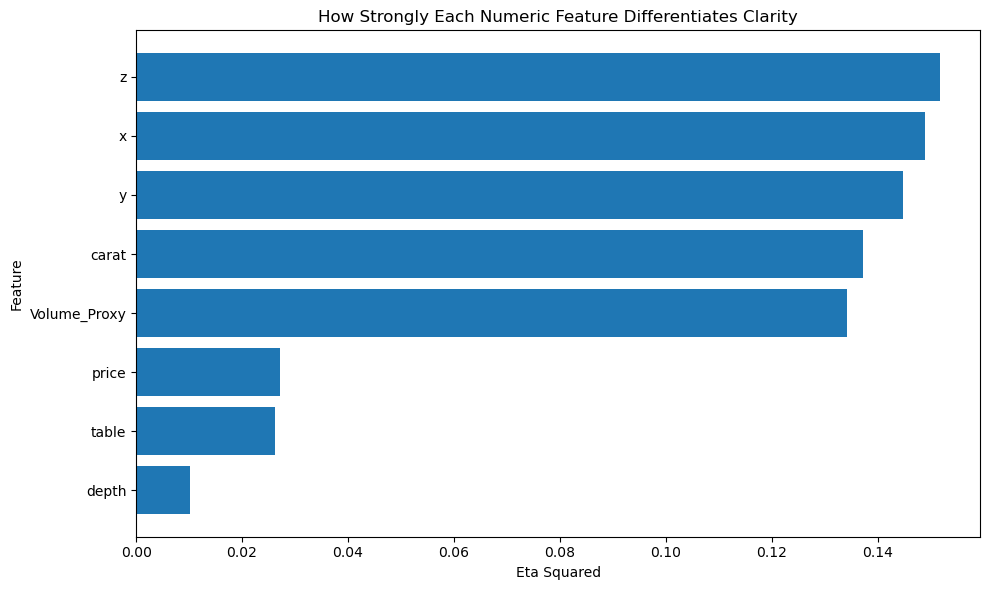

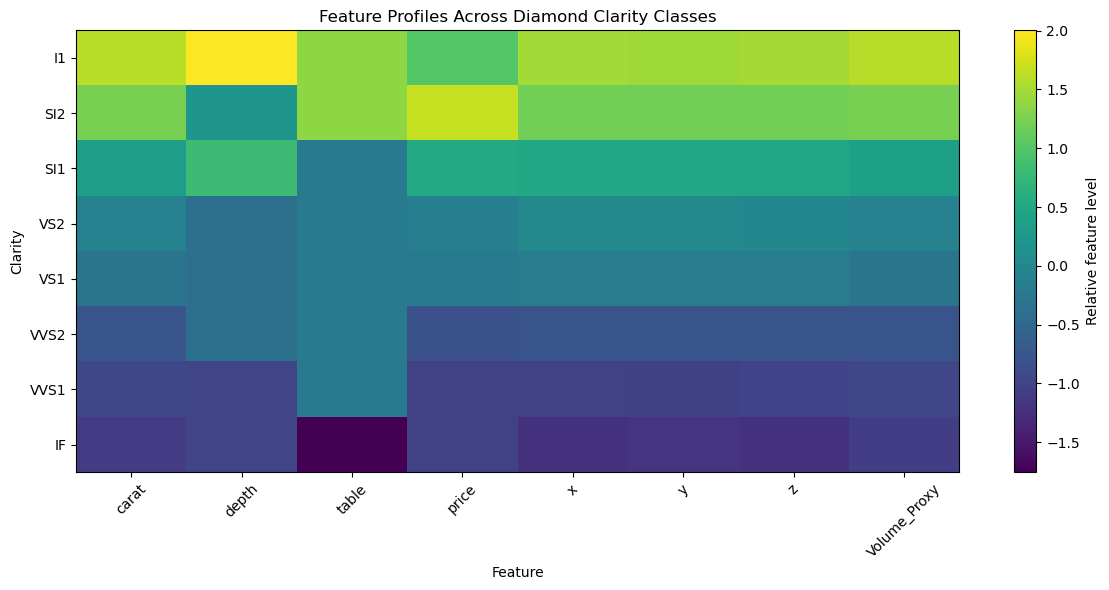

In [17]:
# ============================================================
# EXPERIMENT:
# WHICH FEATURES DIFFERENTIATE DIAMOND CLARITY?
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, spearmanr


# ============================================================
# 1. START WITH FINAL CLEAN DATA
# ============================================================

analysis_df = final_clean_df.copy()


# ============================================================
# 2. CREATE VOLUME FEATURE
# ============================================================

analysis_df["Volume_Proxy"] = (
    analysis_df["x"]
    * analysis_df["y"]
    * analysis_df["z"]
)


# ============================================================
# 3. ORDER CLARITY FROM LOWEST TO HIGHEST
# ============================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

clarity_score_map = {
    "I1": 1,
    "SI2": 2,
    "SI1": 3,
    "VS2": 4,
    "VS1": 5,
    "VVS2": 6,
    "VVS1": 7,
    "IF": 8,
}

analysis_df["Clarity_Score"] = (
    analysis_df["clarity"]
    .map(clarity_score_map)
)


# ============================================================
# 4. FEATURES TO INVESTIGATE
# ============================================================

numeric_features = [
    "carat",
    "depth",
    "table",
    "price",
    "x",
    "y",
    "z",
    "Volume_Proxy",
]

categorical_features = [
    "cut",
    "color",
]


# ============================================================
# 5. ETA-SQUARED FUNCTION
# ============================================================
# Eta-squared asks:
#
# "How much of this feature's variation is connected to
# differences between clarity classes?"
#
# 0 = almost no class separation
# 1 = extremely strong class separation

def eta_squared(data, feature, target):

    overall_mean = data[feature].mean()

    total_variation = (
        (data[feature] - overall_mean) ** 2
    ).sum()

    between_class_variation = 0

    for _, group in data.groupby(target):

        group_mean = group[feature].mean()

        between_class_variation += (
            len(group)
            * (group_mean - overall_mean) ** 2
        )

    if total_variation == 0:
        return 0

    return (
        between_class_variation
        / total_variation
    )


# ============================================================
# 6. CRAMER'S V FUNCTION
# ============================================================
# Cramer's V measures association between categorical features.
#
# Example:
#
# clarity vs cut
# clarity vs color
#
# 0 = little relationship
# 1 = very strong relationship

def cramers_v(data, feature, target):

    table = pd.crosstab(
        data[feature],
        data[target],
    )

    chi2 = chi2_contingency(table)[0]

    n = table.to_numpy().sum()

    rows, columns = table.shape

    denominator = min(
        rows - 1,
        columns - 1,
    )

    if denominator == 0:
        return 0

    return np.sqrt(
        (chi2 / n)
        / denominator
    )


# ============================================================
# 7. NUMERIC FEATURE ANALYSIS
# ============================================================

numeric_results = []

for feature in numeric_features:

    eta = eta_squared(
        analysis_df,
        feature,
        "clarity",
    )

    spearman, _ = spearmanr(
        analysis_df[feature],
        analysis_df["Clarity_Score"],
    )

    numeric_results.append(
        {
            "Feature": feature,
            "Eta_Squared": eta,
            "Spearman": spearman,
        }
    )


numeric_results_df = pd.DataFrame(
    numeric_results
)

numeric_results_df = numeric_results_df.sort_values(
    "Eta_Squared",
    ascending=False,
).reset_index(drop=True)


print("=" * 80)
print("NUMERIC FEATURES VS CLARITY")
print("=" * 80)

print(
    numeric_results_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 8. WHAT DOES SPEARMAN MEAN?
# ============================================================
#
# Positive:
# Feature tends to increase as clarity improves.
#
# Negative:
# Feature tends to decrease as clarity improves.
#
# Near zero:
# No consistent upward/downward relationship.


# ============================================================
# 9. CATEGORICAL FEATURE ANALYSIS
# ============================================================

categorical_results = []

for feature in categorical_features:

    association = cramers_v(
        analysis_df,
        feature,
        "clarity",
    )

    categorical_results.append(
        {
            "Feature": feature,
            "Cramers_V": association,
        }
    )


categorical_results_df = pd.DataFrame(
    categorical_results
)

categorical_results_df = (
    categorical_results_df
    .sort_values(
        "Cramers_V",
        ascending=False,
    )
    .reset_index(drop=True)
)


print("\n")
print("=" * 80)
print("CATEGORICAL FEATURES VS CLARITY")
print("=" * 80)

print(
    categorical_results_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 10. NUMERIC PROFILE FOR EVERY CLARITY CLASS
# ============================================================
#
# This gives us the same idea as your carat/volume experiment:
#
# What does each clarity class normally look like?

profile_rows = []

for clarity in clarity_order:

    clarity_df = analysis_df[
        analysis_df["clarity"] == clarity
    ]

    for feature in numeric_features:

        profile_rows.append(
            {
                "Clarity": clarity,
                "Feature": feature,
                "Count": len(clarity_df),
                "Mean": clarity_df[feature].mean(),
                "Median": clarity_df[feature].median(),
                "P10": clarity_df[feature].quantile(0.10),
                "P90": clarity_df[feature].quantile(0.90),
            }
        )


clarity_profile_df = pd.DataFrame(
    profile_rows
)


print("\n")
print("=" * 100)
print("P10-P90 FEATURE RANGE FOR EACH CLARITY CLASS")
print("=" * 100)

for clarity in clarity_order:

    print("\n")
    print("-" * 100)
    print(f"CLARITY: {clarity}")
    print("-" * 100)

    class_results = clarity_profile_df[
        clarity_profile_df["Clarity"] == clarity
    ]

    print(
        class_results[
            [
                "Feature",
                "Mean",
                "Median",
                "P10",
                "P90",
            ]
        ]
        .round(2)
        .to_string(index=False)
    )


# ============================================================
# 11. CUT DISTRIBUTION INSIDE EACH CLARITY
# ============================================================

cut_clarity = pd.crosstab(
    analysis_df["clarity"],
    analysis_df["cut"],
    normalize="index",
) * 100

cut_clarity = cut_clarity.reindex(
    clarity_order
)

print("\n")
print("=" * 100)
print("CUT DISTRIBUTION WITHIN EACH CLARITY CLASS (%)")
print("=" * 100)

print(
    cut_clarity
    .round(2)
    .to_string()
)


# ============================================================
# 12. COLOR DISTRIBUTION INSIDE EACH CLARITY
# ============================================================

color_clarity = pd.crosstab(
    analysis_df["clarity"],
    analysis_df["color"],
    normalize="index",
) * 100

color_clarity = color_clarity.reindex(
    clarity_order
)

print("\n")
print("=" * 100)
print("COLOR DISTRIBUTION WITHIN EACH CLARITY CLASS (%)")
print("=" * 100)

print(
    color_clarity
    .round(2)
    .to_string()
)


# ============================================================
# 13. VISUALIZE NUMERIC FEATURE STRENGTH
# ============================================================

plot_df = numeric_results_df.sort_values(
    "Eta_Squared"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Feature"],
    plot_df["Eta_Squared"],
)

plt.xlabel("Eta Squared")
plt.ylabel("Feature")

plt.title(
    "How Strongly Each Numeric Feature Differentiates Clarity"
)

plt.tight_layout()
plt.show()


# ============================================================
# 14. CREATE CLARITY × FEATURE MEDIAN MATRIX
# ============================================================
#
# This lets us SEE how each feature changes across the
# clarity classes.

median_matrix = (
    analysis_df
    .groupby("clarity")[numeric_features]
    .median()
    .reindex(clarity_order)
)


# Standardize each feature so different units can be compared.
#
# Otherwise price ($) would dominate x/y/z (mm).

standardized_matrix = (
    median_matrix - median_matrix.mean()
) / median_matrix.std()


# ============================================================
# 15. VISUALIZE CLARITY FEATURE PATTERNS
# ============================================================

plt.figure(figsize=(12, 6))

plt.imshow(
    standardized_matrix,
    aspect="auto",
)

plt.colorbar(
    label="Relative feature level"
)

plt.xticks(
    range(len(numeric_features)),
    numeric_features,
    rotation=45,
)

plt.yticks(
    range(len(clarity_order)),
    clarity_order,
)

plt.xlabel("Feature")
plt.ylabel("Clarity")

plt.title(
    "Feature Profiles Across Diamond Clarity Classes"
)

plt.tight_layout()
plt.show()



MODEL A - STRONGEST EDA SIGNALS

Features:
['x', 'y', 'z', 'carat', 'Volume_Proxy', 'cut']

PERFORMANCE
------------------------------------------------------------
Accuracy:           21.86%
Balanced Accuracy:  28.62%
Macro F1:           19.62%
Weighted F1:        21.69%

CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

          I1       0.07      0.55      0.12       147
         SI2       0.31      0.43      0.36      1836
         SI1       0.35      0.18      0.24      2612
         VS2       0.34      0.12      0.18      2450
         VS1       0.20      0.10      0.13      1633
        VVS2       0.18      0.20      0.19      1013
        VVS1       0.13      0.24      0.17       731
          IF       0.11      0.46      0.17       358

    accuracy                           0.22     10780
   macro avg       0.21      0.29      0.20     10780
weighted avg       0.27      0.22      0.22  

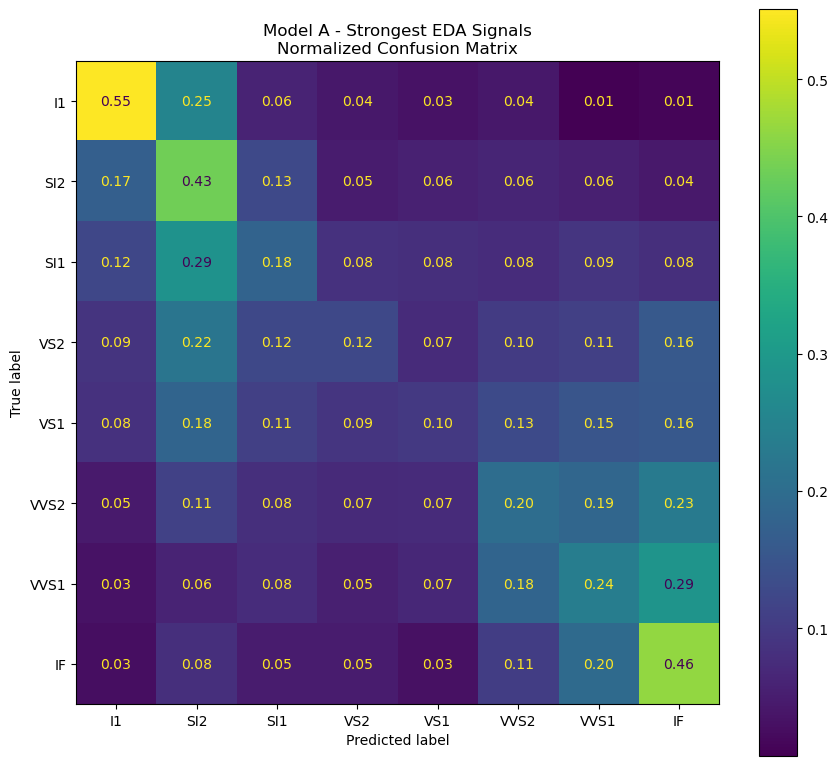

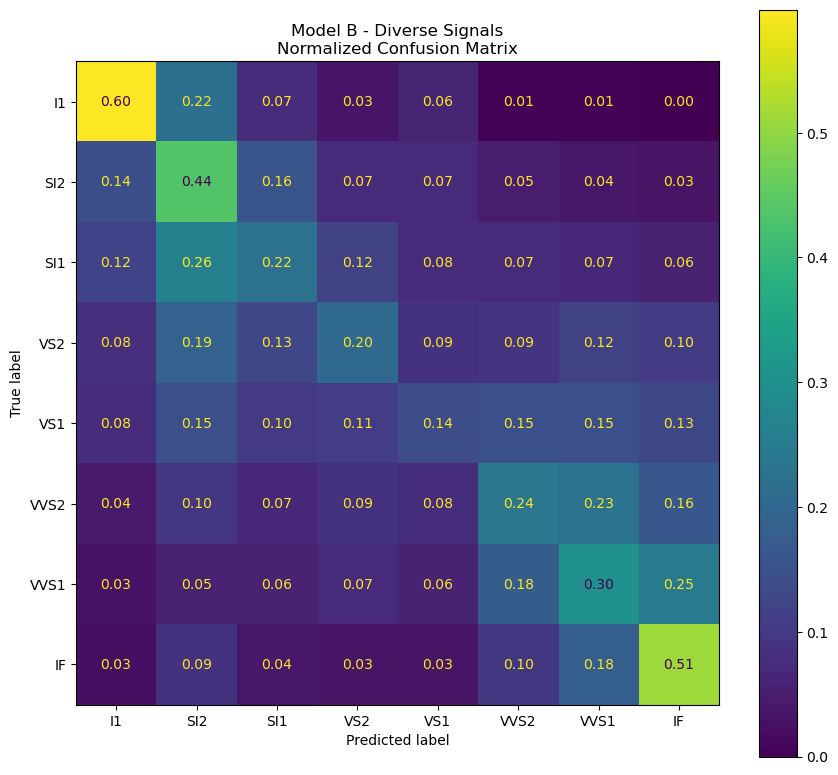

In [18]:
# ============================================================
# EXPERIMENT:
# XGBOOST CLARITY CLASSIFICATION
#
# MODEL A:
# Strongest features found during EDA
#
# MODEL B:
# More diverse / less redundant features
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ============================================================
# 1. START WITH FINAL CLEANED DATA
# ============================================================

model_df = final_clean_df.copy()


# ============================================================
# 2. CREATE ENGINEERED FEATURES
# ============================================================
# Volume proxy describes overall physical size.
#
# Carat_Per_Volume compares the diamond's weight with its
# physical dimensions.

model_df["Volume_Proxy"] = (
    model_df["x"]
    * model_df["y"]
    * model_df["z"]
)

model_df["Carat_Per_Volume"] = (
    model_df["carat"]
    / model_df["Volume_Proxy"]
)


# ============================================================
# 3. CLARITY TARGET
# ============================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

clarity_to_number = {
    clarity: number
    for number, clarity in enumerate(clarity_order)
}

number_to_clarity = {
    number: clarity
    for clarity, number in clarity_to_number.items()
}

model_df["Clarity_Target"] = (
    model_df["clarity"]
    .map(clarity_to_number)
)


# ============================================================
# 4. DEFINE THE TWO EXPERIMENTS
# ============================================================

feature_sets = {

    # --------------------------------------------------------
    # MODEL A
    # These had the strongest individual relationships
    # with clarity in our EDA.
    # --------------------------------------------------------

    "Model A - Strongest EDA Signals": [
        "x",
        "y",
        "z",
        "carat",
        "Volume_Proxy",
        "cut",
    ],

    # --------------------------------------------------------
    # MODEL B
    # Instead of giving the model many versions of size,
    # give it different kinds of information.
    # --------------------------------------------------------

    "Model B - Diverse Signals": [
        "carat",
        "cut",
        "color",
        "depth",
        "table",
        "Carat_Per_Volume",
    ],
}


# ============================================================
# 5. CREATE ONE FAIR TRAIN / TEST SPLIT
# ============================================================
# Every model sees EXACTLY the same training diamonds
# and EXACTLY the same testing diamonds.
#
# stratify keeps the clarity-class proportions similar.

train_indices, test_indices = train_test_split(
    model_df.index,
    test_size=0.20,
    random_state=42,
    stratify=model_df["Clarity_Target"],
)


# ============================================================
# 6. FUNCTION TO TRAIN ONE XGBOOST MODEL
# ============================================================

def run_xgboost_experiment(
    data,
    features,
    train_indices,
    test_indices,
):
    """
    Train and evaluate an XGBoost classifier for diamond clarity.

    Parameters
    ----------
    data : pd.DataFrame
        Complete cleaned diamond dataset.

    features : list[str]
        Features included in this experiment.

    train_indices : pd.Index
        Rows used for training.

    test_indices : pd.Index
        Rows used for testing.

    Returns
    -------
    dict
        Model, preprocessing pipeline, predictions and metrics.
    """

    # --------------------------------------------------------
    # Separate X and Y
    # --------------------------------------------------------

    X = data[features]

    y = data["Clarity_Target"]


    X_train = X.loc[train_indices]
    X_test = X.loc[test_indices]

    y_train = y.loc[train_indices]
    y_test = y.loc[test_indices]


    # --------------------------------------------------------
    # Detect categorical vs numeric columns
    # --------------------------------------------------------

    categorical_features = [
        feature
        for feature in features
        if data[feature].dtype == "object"
    ]

    numeric_features = [
        feature
        for feature in features
        if feature not in categorical_features
    ]


    # --------------------------------------------------------
    # Encode cut/color
    #
    # XGBoost needs numbers.
    #
    # One-hot encoding turns categories into binary columns.
    # --------------------------------------------------------

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                categorical_features,
            ),
            (
                "numeric",
                "passthrough",
                numeric_features,
            ),
        ]
    )


    # --------------------------------------------------------
    # Fit preprocessing ONLY on training data
    #
    # This prevents data leakage.
    # --------------------------------------------------------

    X_train_processed = preprocessor.fit_transform(
        X_train
    )

    X_test_processed = preprocessor.transform(
        X_test
    )


    # --------------------------------------------------------
    # ACCOUNT FOR CLASS IMBALANCE
    #
    # I1 and IF are much rarer than SI1 / VS2.
    #
    # Balanced sample weights make mistakes on rare classes
    # matter more during training.
    # --------------------------------------------------------

    training_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )


    # ========================================================
    # XGBOOST MODEL
    # ========================================================

    model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(clarity_order),

        n_estimators=350,
        learning_rate=0.05,

        max_depth=5,

        min_child_weight=2,

        subsample=0.80,

        colsample_bytree=0.80,

        reg_alpha=0.10,
        reg_lambda=1.00,

        eval_metric="mlogloss",

        tree_method="hist",

        random_state=42,
        n_jobs=-1,
    )


    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------

    model.fit(
        X_train_processed,
        y_train,
        sample_weight=training_weights,
    )


    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    predictions = model.predict(
        X_test_processed
    )


    # ========================================================
    # METRICS
    # ========================================================

    accuracy = accuracy_score(
        y_test,
        predictions,
    )

    balanced_accuracy = balanced_accuracy_score(
        y_test,
        predictions,
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0,
    )


    # ========================================================
    # FEATURE IMPORTANCE
    # ========================================================

    feature_names = (
        preprocessor
        .get_feature_names_out()
    )

    feature_importance = pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": model.feature_importances_,
        }
    )

    feature_importance = (
        feature_importance
        .sort_values(
            "Importance",
            ascending=False,
        )
        .reset_index(drop=True)
    )


    return {

        "model": model,

        "preprocessor": preprocessor,

        "X_test": X_test,

        "y_test": y_test,

        "predictions": predictions,

        "accuracy": accuracy,

        "balanced_accuracy": balanced_accuracy,

        "macro_f1": macro_f1,

        "weighted_f1": weighted_f1,

        "feature_importance": feature_importance,
    }


# ============================================================
# 7. RUN BOTH EXPERIMENTS
# ============================================================

experiment_results = {}

comparison_rows = []


for experiment_name, features in feature_sets.items():

    print("\n")
    print("=" * 100)
    print(experiment_name.upper())
    print("=" * 100)

    print("\nFeatures:")
    print(features)

    result = run_xgboost_experiment(
        data=model_df,
        features=features,
        train_indices=train_indices,
        test_indices=test_indices,
    )

    experiment_results[experiment_name] = result


    # --------------------------------------------------------
    # PRINT MAIN METRICS
    # --------------------------------------------------------

    print("\nPERFORMANCE")
    print("-" * 60)

    print(
        f"Accuracy:           "
        f"{result['accuracy']:.2%}"
    )

    print(
        f"Balanced Accuracy:  "
        f"{result['balanced_accuracy']:.2%}"
    )

    print(
        f"Macro F1:           "
        f"{result['macro_f1']:.2%}"
    )

    print(
        f"Weighted F1:        "
        f"{result['weighted_f1']:.2%}"
    )


    # --------------------------------------------------------
    # CLASS-BY-CLASS PERFORMANCE
    # --------------------------------------------------------

    print("\nCLASSIFICATION REPORT")
    print("-" * 60)

    print(
        classification_report(
            result["y_test"],
            result["predictions"],
            labels=list(range(len(clarity_order))),
            target_names=clarity_order,
            zero_division=0,
        )
    )


    # --------------------------------------------------------
    # MOST IMPORTANT FEATURES
    # --------------------------------------------------------

    print("\nTOP FEATURE IMPORTANCE")
    print("-" * 60)

    print(
        result["feature_importance"]
        .head(15)
        .round(4)
        .to_string(index=False)
    )


    # --------------------------------------------------------
    # SAVE COMPARISON RESULT
    # --------------------------------------------------------

    comparison_rows.append(
        {
            "Model": experiment_name,
            "Accuracy": result["accuracy"],
            "Balanced_Accuracy": result[
                "balanced_accuracy"
            ],
            "Macro_F1": result["macro_f1"],
            "Weighted_F1": result["weighted_f1"],
        }
    )


# ============================================================
# 8. FINAL MODEL COMPARISON
# ============================================================

comparison_df = pd.DataFrame(
    comparison_rows
)

comparison_df = comparison_df.sort_values(
    "Macro_F1",
    ascending=False,
).reset_index(drop=True)


# Convert metrics to %
display_comparison = comparison_df.copy()

for column in [
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "Weighted_F1",
]:

    display_comparison[column] = (
        display_comparison[column]
        * 100
    ).round(2)


print("\n")
print("=" * 100)
print("FINAL XGBOOST COMPARISON")
print("=" * 100)

print(
    display_comparison.to_string(
        index=False
    )
)


# ============================================================
# 9. IDENTIFY WINNER
# ============================================================

winner = comparison_df.iloc[0]

print("\n")
print("=" * 100)
print("WINNER BASED ON MACRO F1")
print("=" * 100)

print(
    f"\n{winner['Model']}"
)

print(
    f"Macro F1: "
    f"{winner['Macro_F1']:.2%}"
)


# ============================================================
# 10. NORMALIZED CONFUSION MATRIX FOR EACH MODEL
# ============================================================
# Each row represents the TRUE clarity class.
#
# This lets us see:
#
# I1 gets confused with what?
# SI2 gets confused with what?
# VVS1 vs VVS2?
# IF vs VVS1?
#
# Values are percentages instead of raw counts.

for experiment_name, result in experiment_results.items():

    confusion = confusion_matrix(
        result["y_test"],
        result["predictions"],
        labels=list(range(len(clarity_order))),
        normalize="true",
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=confusion,
        display_labels=clarity_order,
    )

    fig, ax = plt.subplots(
        figsize=(9, 8)
    )

    display.plot(
        ax=ax,
        cmap=None,
        values_format=".2f",
    )

    plt.title(
        f"{experiment_name}\n"
        "Normalized Confusion Matrix"
    )

    plt.tight_layout()

    plt.show()

In [19]:
# ============================================================
# EXPERIMENT C:
# PEER-RELATIVE / GROUNDED XGBOOST CLARITY MODEL
#
# Main question:
#
# Instead of only telling XGBoost what a diamond IS,
# tell it how the diamond COMPARES WITH SIMILAR-CARAT DIAMONDS.
#
# IMPORTANT:
# Peer averages/medians are calculated ONLY from training data.
# This prevents data leakage.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ============================================================
# 1. START WITH FINAL CLEANED DATASET
# ============================================================

model_df = final_clean_df.copy()


# ============================================================
# 2. CREATE BASIC PHYSICAL FEATURES
# ============================================================

model_df["Volume_Proxy"] = (
    model_df["x"]
    * model_df["y"]
    * model_df["z"]
)

model_df["Carat_Per_Volume"] = (
    model_df["carat"]
    / model_df["Volume_Proxy"]
)

# Shape ratio:
# close to 1 means length and width are similar

model_df["XY_Ratio"] = (
    model_df["x"]
    / model_df["y"]
)

# Thickness relative to the average face dimension

model_df["Z_to_Face_Size"] = (
    model_df["z"]
    / ((model_df["x"] + model_df["y"]) / 2)
)


# ============================================================
# 3. DEFINE CLARITY ORDER
# ============================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

clarity_to_number = {
    clarity: number
    for number, clarity in enumerate(clarity_order)
}

number_to_clarity = {
    number: clarity
    for clarity, number in clarity_to_number.items()
}

model_df["Clarity_Target"] = (
    model_df["clarity"]
    .map(clarity_to_number)
)


# ============================================================
# 4. CREATE CARAT GROUPS
# ============================================================
#
# These are the same broad groups we used during EDA.
#
# The group itself DOES NOT use clarity.
# It only uses carat weight.
# ============================================================

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]

carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]

model_df["Carat_Group"] = pd.cut(
    model_df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ============================================================
# 5. TRAIN / TEST SPLIT
# ============================================================
#
# We split BEFORE calculating peer statistics.
#
# This is extremely important.
#
# The test set must not help create its own reference averages.
# ============================================================

train_indices, test_indices = train_test_split(
    model_df.index,
    test_size=0.20,
    random_state=42,
    stratify=model_df["Clarity_Target"],
)

train_df = model_df.loc[train_indices].copy()
test_df = model_df.loc[test_indices].copy()


# ============================================================
# 6. CALCULATE PEER MEDIANS USING TRAINING DATA ONLY
# ============================================================
#
# For each carat group we calculate the typical:
#
# x
# y
# z
# volume
# depth
# table
#
# We use MEDIAN because it is more resistant to unusual values.
# ============================================================

peer_statistics = (
    train_df
    .groupby(
        "Carat_Group",
        observed=True,
    )
    .agg(
        Group_X_Median=("x", "median"),
        Group_Y_Median=("y", "median"),
        Group_Z_Median=("z", "median"),
        Group_Volume_Median=("Volume_Proxy", "median"),
        Group_Depth_Median=("depth", "median"),
        Group_Table_Median=("table", "median"),
    )
)


print("=" * 100)
print("TRAINING-DATA PEER MEDIANS")
print("=" * 100)

print(
    peer_statistics
    .round(4)
    .to_string()
)


# ============================================================
# 7. FUNCTION TO ADD PEER-RELATIVE FEATURES
# ============================================================

def add_peer_relative_features(
    data,
    peer_stats,
):
    """
    Add features describing how each diamond compares
    with diamonds from the same carat group.

    Peer statistics must come from training data only.
    """

    result = data.copy()

    # --------------------------------------------------------
    # Join each diamond with its peer-group medians
    # --------------------------------------------------------

    result = result.merge(
        peer_stats,
        left_on="Carat_Group",
        right_index=True,
        how="left",
    )


    # --------------------------------------------------------
    # Relative physical dimensions
    #
    # Example:
    #
    # X_vs_Group_Median = 1.05
    #
    # means:
    #
    # this diamond is about 5% longer than
    # the typical diamond in its carat group.
    # --------------------------------------------------------

    result["X_vs_Group_Median"] = (
        result["x"]
        / result["Group_X_Median"]
    )

    result["Y_vs_Group_Median"] = (
        result["y"]
        / result["Group_Y_Median"]
    )

    result["Z_vs_Group_Median"] = (
        result["z"]
        / result["Group_Z_Median"]
    )

    result["Volume_vs_Group_Median"] = (
        result["Volume_Proxy"]
        / result["Group_Volume_Median"]
    )


    # --------------------------------------------------------
    # Difference from normal proportions
    #
    # Example:
    #
    # Depth_Deviation = +2
    #
    # means the diamond depth percentage is
    # 2 percentage points above its peer median.
    # --------------------------------------------------------

    result["Depth_Deviation"] = (
        result["depth"]
        - result["Group_Depth_Median"]
    )

    result["Table_Deviation"] = (
        result["table"]
        - result["Group_Table_Median"]
    )


    return result


# ============================================================
# 8. ADD PEER FEATURES
# ============================================================

train_df = add_peer_relative_features(
    train_df,
    peer_statistics,
)

test_df = add_peer_relative_features(
    test_df,
    peer_statistics,
)


# ============================================================
# 9. MODEL C FEATURES
# ============================================================
#
# Raw useful information
#
# +
#
# contextual information describing how unusual the diamond
# is compared with similar-weight diamonds.
# ============================================================

model_c_features = [
    "carat",
    "cut",
    "color",
    "depth",
    "table",

    "Carat_Group",

    "Carat_Per_Volume",
    "XY_Ratio",
    "Z_to_Face_Size",

    "X_vs_Group_Median",
    "Y_vs_Group_Median",
    "Z_vs_Group_Median",
    "Volume_vs_Group_Median",

    "Depth_Deviation",
    "Table_Deviation",
]


# ============================================================
# 10. PREPARE X AND Y
# ============================================================

X_train = train_df[
    model_c_features
].copy()

X_test = test_df[
    model_c_features
].copy()

y_train = train_df[
    "Clarity_Target"
].copy()

y_test = test_df[
    "Clarity_Target"
].copy()


# ============================================================
# 11. DEFINE CATEGORICAL AND NUMERIC FEATURES
# ============================================================

categorical_features = [
    "cut",
    "color",
    "Carat_Group",
]

numeric_features = [
    feature
    for feature in model_c_features
    if feature not in categorical_features
]


# ============================================================
# 12. PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)


# ============================================================
# 13. FIT PREPROCESSING ON TRAINING DATA ONLY
# ============================================================

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)


# ============================================================
# 14. CLASS BALANCING
# ============================================================
#
# Use the same balanced weighting approach as Model B
# so the comparison remains fair.
# ============================================================

training_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train,
)


# ============================================================
# 15. XGBOOST
# ============================================================

model_c = XGBClassifier(
    objective="multi:softprob",

    num_class=len(
        clarity_order
    ),

    n_estimators=350,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=2,

    subsample=0.80,

    colsample_bytree=0.80,

    reg_alpha=0.10,

    reg_lambda=1.00,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1,
)


# ============================================================
# 16. TRAIN MODEL
# ============================================================

model_c.fit(
    X_train_processed,
    y_train,
    sample_weight=training_weights,
)


# ============================================================
# 17. PREDICT
# ============================================================

predictions = model_c.predict(
    X_test_processed
)


# ============================================================
# 18. MAIN METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    predictions,
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    predictions,
)

macro_f1 = f1_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0,
)

weighted_f1 = f1_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0,
)


print("\n")
print("=" * 100)
print("MODEL C - PEER RELATIVE FEATURES")
print("=" * 100)

print(
    f"Accuracy:           "
    f"{accuracy:.2%}"
)

print(
    f"Balanced Accuracy:  "
    f"{balanced_accuracy:.2%}"
)

print(
    f"Macro F1:           "
    f"{macro_f1:.2%}"
)

print(
    f"Weighted F1:        "
    f"{weighted_f1:.2%}"
)


# ============================================================
# 19. CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)

print(
    classification_report(
        y_test,
        predictions,

        labels=list(
            range(len(clarity_order))
        ),

        target_names=clarity_order,

        zero_division=0,
    )
)


# ============================================================
# 20. RAW CONFUSION MATRIX
# ============================================================
#
# Rows = TRUE clarity
# Columns = PREDICTED clarity
#
# This is printed as text so you can paste it into ChatGPT.
# ============================================================

confusion = confusion_matrix(
    y_test,
    predictions,
    labels=list(
        range(len(clarity_order))
    ),
)

confusion_df = pd.DataFrame(
    confusion,
    index=[
        f"True_{clarity}"
        for clarity in clarity_order
    ],
    columns=[
        f"Pred_{clarity}"
        for clarity in clarity_order
    ],
)


print("\n")
print("=" * 120)
print("RAW CONFUSION MATRIX")
print("=" * 120)

print(
    confusion_df.to_string()
)


# ============================================================
# 21. NORMALIZED CONFUSION MATRIX
# ============================================================
#
# Converts each TRUE class row into percentages.
#
# Much easier to interpret.
#
# Example:
#
# True VS1
#
# 20% VS1
# 35% VS2
# 25% VVS2
#
# means VS1 is being confused heavily with nearby classes.
# ============================================================

normalized_confusion = confusion_matrix(
    y_test,
    predictions,

    labels=list(
        range(len(clarity_order))
    ),

    normalize="true",
)

normalized_confusion_df = pd.DataFrame(
    normalized_confusion * 100,

    index=[
        f"True_{clarity}"
        for clarity in clarity_order
    ],

    columns=[
        f"Pred_{clarity}"
        for clarity in clarity_order
    ],
)


print("\n")
print("=" * 120)
print("NORMALIZED CONFUSION MATRIX (%)")
print("=" * 120)

print(
    normalized_confusion_df
    .round(2)
    .to_string()
)


# ============================================================
# 22. MOST CONFUSED CLASS FOR EACH TRUE CLASS
# ============================================================
#
# This gives exactly what you said you want:
#
# "When I1 is wrong, what does it usually become?"
#
# "When VS1 is wrong, what does it usually become?"
# ============================================================

print("\n")
print("=" * 120)
print("BIGGEST CONFUSION FOR EACH CLARITY CLASS")
print("=" * 120)


for true_index, true_class in enumerate(
    clarity_order
):

    row = confusion[
        true_index
    ].copy()

    # Remove correct predictions
    row[
        true_index
    ] = 0

    most_confused_index = (
        row.argmax()
    )

    most_confused_class = (
        clarity_order[
            most_confused_index
        ]
    )

    confusion_count = (
        row[
            most_confused_index
        ]
    )

    total_true = (
        confusion[
            true_index
        ].sum()
    )

    confusion_percentage = (
        confusion_count
        / total_true
        * 100
    )

    correct_percentage = (
        confusion[
            true_index,
            true_index
        ]
        / total_true
        * 100
    )

    print(
        f"{true_class:5s} "
        f"| Correct: {correct_percentage:6.2f}% "
        f"| Most confused with: "
        f"{most_confused_class:5s} "
        f"| {confusion_percentage:6.2f}% "
        f"({confusion_count} diamonds)"
    )


# ============================================================
# 23. TOP 20 CONFUSION PAIRS OVERALL
# ============================================================
#
# Example:
#
# True VS1 -> Predicted VS2
#
# This ranks the largest mistakes across the entire test set.
# ============================================================

confusion_pairs = []

for true_index, true_class in enumerate(
    clarity_order
):

    total_true = confusion[
        true_index
    ].sum()

    for predicted_index, predicted_class in enumerate(
        clarity_order
    ):

        if (
            true_index
            == predicted_index
        ):
            continue

        count = confusion[
            true_index,
            predicted_index
        ]

        percentage = (
            count
            / total_true
            * 100
        )

        confusion_pairs.append(
            {
                "True_Class": true_class,
                "Predicted_As": predicted_class,
                "Count": count,
                "Pct_of_True_Class": percentage,
            }
        )


confusion_pairs_df = pd.DataFrame(
    confusion_pairs
)

confusion_pairs_df = (
    confusion_pairs_df
    .sort_values(
        [
            "Count",
            "Pct_of_True_Class",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)


print("\n")
print("=" * 120)
print("TOP 20 CONFUSION PAIRS")
print("=" * 120)

print(
    confusion_pairs_df
    .head(20)
    .round(2)
    .to_string(
        index=False
    )
)


# ============================================================
# 24. FEATURE IMPORTANCE
# ============================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)

feature_importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": (
            model_c.feature_importances_
        ),
    }
)

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "Importance",
        ascending=False,
    )
    .reset_index(drop=True)
)


print("\n")
print("=" * 120)
print("TOP 25 MODEL C FEATURE IMPORTANCES")
print("=" * 120)

print(
    feature_importance_df
    .head(25)
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 25. COMPARE WITH PREVIOUS MODEL B
# ============================================================
#
# These were your previous results.
# ============================================================

model_b_accuracy = 0.2643
model_b_balanced_accuracy = 0.3320
model_b_macro_f1 = 0.2418
model_b_weighted_f1 = 0.2677


comparison_df = pd.DataFrame(
    [
        {
            "Model": "Model B - Diverse Signals",
            "Accuracy": (
                model_b_accuracy
                * 100
            ),
            "Balanced Accuracy": (
                model_b_balanced_accuracy
                * 100
            ),
            "Macro F1": (
                model_b_macro_f1
                * 100
            ),
            "Weighted F1": (
                model_b_weighted_f1
                * 100
            ),
        },

        {
            "Model": "Model C - Peer Relative",
            "Accuracy": (
                accuracy
                * 100
            ),
            "Balanced Accuracy": (
                balanced_accuracy
                * 100
            ),
            "Macro F1": (
                macro_f1
                * 100
            ),
            "Weighted F1": (
                weighted_f1
                * 100
            ),
        },
    ]
)


print("\n")
print("=" * 120)
print("MODEL B VS MODEL C")
print("=" * 120)

print(
    comparison_df
    .round(2)
    .to_string(
        index=False
    )
)


# ============================================================
# 26. IMPROVEMENT OVER MODEL B
# ============================================================

print("\n")
print("=" * 120)
print("MODEL C IMPROVEMENT OVER MODEL B")
print("=" * 120)

print(
    f"Accuracy improvement: "
    f"{(accuracy - model_b_accuracy) * 100:+.2f} percentage points"
)

print(
    f"Balanced Accuracy improvement: "
    f"{(balanced_accuracy - model_b_balanced_accuracy) * 100:+.2f} percentage points"
)

print(
    f"Macro F1 improvement: "
    f"{(macro_f1 - model_b_macro_f1) * 100:+.2f} percentage points"
)

print(
    f"Weighted F1 improvement: "
    f"{(weighted_f1 - model_b_weighted_f1) * 100:+.2f} percentage points"
)

TRAINING-DATA PEER MEDIANS
             Group_X_Median  Group_Y_Median  Group_Z_Median  Group_Volume_Median  Group_Depth_Median  Group_Table_Median
Carat_Group                                                                                                             
0.20-0.39              4.38            4.39            2.71              52.0086                61.8                57.0
0.40-0.59              5.09            5.10            3.15              82.1883                61.8                57.0
0.60-0.79              5.72            5.74            3.54             115.9752                61.8                57.0
0.80-0.99              6.14            6.15            3.82             144.7999                62.2                58.0
1.00-1.49              6.58            6.58            4.06             174.3846                61.9                58.0
1.50-1.99              7.42            7.41            4.58             249.6126                62.0                58.0
2.00-

In [20]:
# ============================================================
# EXPERIMENT D:
# CONTINUOUS SIZE-ADJUSTED CLARITY FEATURES
#
# QUESTION:
# After accounting for carat weight, do unusual dimensions
# provide additional information about clarity?
#
# MODEL C BASELINE:
# Accuracy:          27.70%
# Balanced Accuracy: 34.09%
# Macro F1:          25.35%
# Weighted F1:       28.02%
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    KFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from scipy.stats import spearmanr

from xgboost import XGBClassifier


# ============================================================
# 1. START WITH FINAL CLEAN DATA
# ============================================================

experiment_df = final_clean_df.copy()


# ============================================================
# 2. BASIC PHYSICAL FEATURES
# ============================================================

experiment_df["Volume_Proxy"] = (
    experiment_df["x"]
    * experiment_df["y"]
    * experiment_df["z"]
)

experiment_df["Carat_Per_Volume"] = (
    experiment_df["carat"]
    / experiment_df["Volume_Proxy"]
)

experiment_df["XY_Ratio"] = (
    experiment_df["x"]
    / experiment_df["y"]
)

experiment_df["Z_to_Face_Size"] = (
    experiment_df["z"]
    / ((experiment_df["x"] + experiment_df["y"]) / 2)
)


# ============================================================
# 3. CLARITY TARGET
# ============================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

clarity_to_number = {
    clarity: number
    for number, clarity in enumerate(clarity_order)
}

experiment_df["Clarity_Target"] = (
    experiment_df["clarity"]
    .map(clarity_to_number)
)


# ============================================================
# 4. SAME TRAIN / TEST SPLIT AS EARLIER EXPERIMENTS
# ============================================================

train_indices, test_indices = train_test_split(
    experiment_df.index,
    test_size=0.20,
    random_state=42,
    stratify=experiment_df["Clarity_Target"],
)

train_df = experiment_df.loc[train_indices].copy()
test_df = experiment_df.loc[test_indices].copy()


# ============================================================
# 5. EXPECTED-DIMENSION MODEL
# ============================================================
#
# This model learns:
#
# carat -> expected x
# carat -> expected y
# carat -> expected z
# carat -> expected volume
#
# We are NOT using clarity here.
# ============================================================

def build_expected_dimension_features(
    train_data,
    test_data,
    target_feature,
):
    """
    Learn the expected physical measurement from carat.

    Training expectations are produced out-of-fold so each
    training diamond is predicted by a model that did not
    train on that diamond.

    Test expectations are produced using a model trained only
    on the training dataset.
    """

    X_train_carat = train_data[["carat"]]
    X_test_carat = test_data[["carat"]]

    y_train_geometry = train_data[target_feature]

    # --------------------------------------------------------
    # Regression model for the carat -> dimension relationship
    # --------------------------------------------------------

    expected_model = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=15,
        min_samples_leaf=30,
        l2_regularization=1.0,
        random_state=42,
    )

    # --------------------------------------------------------
    # Out-of-fold predictions for TRAINING rows
    #
    # This avoids giving training rows overly optimistic
    # expected values.
    # --------------------------------------------------------

    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )

    train_expected = cross_val_predict(
        expected_model,
        X_train_carat,
        y_train_geometry,
        cv=cv,
        n_jobs=-1,
    )

    # --------------------------------------------------------
    # Fit on ALL training data
    # --------------------------------------------------------

    expected_model.fit(
        X_train_carat,
        y_train_geometry,
    )

    # --------------------------------------------------------
    # Predict expected value for TEST rows
    # --------------------------------------------------------

    test_expected = expected_model.predict(
        X_test_carat
    )


    # ========================================================
    # CREATE CONTEXTUAL FEATURES
    # ========================================================

    expected_column = (
        f"Expected_{target_feature}"
    )

    ratio_column = (
        f"{target_feature}_Ratio"
    )

    deviation_column = (
        f"{target_feature}_Deviation"
    )

    deviation_pct_column = (
        f"{target_feature}_Deviation_Pct"
    )

    absolute_deviation_column = (
        f"{target_feature}_Abs_Deviation_Pct"
    )


    # --------------------------------------------------------
    # Expected values
    # --------------------------------------------------------

    train_data[expected_column] = train_expected
    test_data[expected_column] = test_expected


    # --------------------------------------------------------
    # Actual / Expected
    #
    # 1.00 = exactly normal for this carat
    # 1.05 = 5% larger than expected
    # 0.95 = 5% smaller than expected
    # --------------------------------------------------------

    train_data[ratio_column] = (
        train_data[target_feature]
        / train_data[expected_column]
    )

    test_data[ratio_column] = (
        test_data[target_feature]
        / test_data[expected_column]
    )


    # --------------------------------------------------------
    # Actual - Expected
    # --------------------------------------------------------

    train_data[deviation_column] = (
        train_data[target_feature]
        - train_data[expected_column]
    )

    test_data[deviation_column] = (
        test_data[target_feature]
        - test_data[expected_column]
    )


    # --------------------------------------------------------
    # Percentage difference from expected
    # --------------------------------------------------------

    train_data[deviation_pct_column] = (
        (
            train_data[target_feature]
            - train_data[expected_column]
        )
        / train_data[expected_column]
        * 100
    )

    test_data[deviation_pct_column] = (
        (
            test_data[target_feature]
            - test_data[expected_column]
        )
        / test_data[expected_column]
        * 100
    )


    # --------------------------------------------------------
    # Absolute percentage deviation
    #
    # We don't care whether the diamond is larger or smaller.
    # We care how unusual it is.
    # --------------------------------------------------------

    train_data[absolute_deviation_column] = (
        train_data[deviation_pct_column].abs()
    )

    test_data[absolute_deviation_column] = (
        test_data[deviation_pct_column].abs()
    )


    return train_data, test_data


# ============================================================
# 6. CREATE EXPECTED X / Y / Z / VOLUME FEATURES
# ============================================================

geometry_features = [
    "x",
    "y",
    "z",
    "Volume_Proxy",
]

for feature in geometry_features:

    train_df, test_df = (
        build_expected_dimension_features(
            train_df,
            test_df,
            feature,
        )
    )


# ============================================================
# 7. SHOW EXAMPLES
# ============================================================

example_columns = [
    "carat",

    "x",
    "Expected_x",
    "x_Ratio",
    "x_Deviation_Pct",

    "z",
    "Expected_z",
    "z_Ratio",
    "z_Deviation_Pct",

    "Volume_Proxy",
    "Expected_Volume_Proxy",
    "Volume_Proxy_Ratio",
    "Volume_Proxy_Deviation_Pct",

    "clarity",
]


print("=" * 120)
print("EXAMPLE SIZE-ADJUSTED FEATURES")
print("=" * 120)

print(
    train_df[
        example_columns
    ]
    .head(20)
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 8. ETA-SQUARED
# ============================================================
#
# We now ask:
#
# Does the SIZE-ADJUSTED feature differ across clarity?
#
# This is much more interesting than raw x/y/z because
# carat has already been accounted for.
# ============================================================

def eta_squared(
    data,
    feature,
    target,
):
    overall_mean = data[feature].mean()

    total_variation = (
        (data[feature] - overall_mean) ** 2
    ).sum()

    between_class_variation = 0

    for _, group in data.groupby(
        target,
        observed=True,
    ):

        group_mean = group[feature].mean()

        between_class_variation += (
            len(group)
            * (group_mean - overall_mean) ** 2
        )

    if total_variation == 0:
        return 0.0

    return (
        between_class_variation
        / total_variation
    )


# ============================================================
# 9. ANALYZE NEW SIZE-ADJUSTED FEATURES VS CLARITY
# ============================================================

adjusted_features = [
    "x_Ratio",
    "x_Deviation_Pct",
    "x_Abs_Deviation_Pct",

    "y_Ratio",
    "y_Deviation_Pct",
    "y_Abs_Deviation_Pct",

    "z_Ratio",
    "z_Deviation_Pct",
    "z_Abs_Deviation_Pct",

    "Volume_Proxy_Ratio",
    "Volume_Proxy_Deviation_Pct",
    "Volume_Proxy_Abs_Deviation_Pct",

    "Carat_Per_Volume",
    "XY_Ratio",
    "Z_to_Face_Size",
]


relationship_results = []

for feature in adjusted_features:

    eta = eta_squared(
        train_df,
        feature,
        "clarity",
    )

    spearman, _ = spearmanr(
        train_df[feature],
        train_df["Clarity_Target"],
    )

    relationship_results.append(
        {
            "Feature": feature,
            "Eta_Squared": eta,
            "Spearman": spearman,
        }
    )


relationship_df = pd.DataFrame(
    relationship_results
)

relationship_df = relationship_df.sort_values(
    "Eta_Squared",
    ascending=False,
).reset_index(drop=True)


print("\n")
print("=" * 100)
print("SIZE-ADJUSTED FEATURES VS CLARITY")
print("=" * 100)

print(
    relationship_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 10. MODEL D FEATURES
# ============================================================
#
# We retain useful general information:
#
# carat
# cut
# color
# depth
# table
#
# Then add continuous size-adjusted geometry.
# ============================================================

model_d_features = [
    "carat",
    "cut",
    "color",
    "depth",
    "table",

    "Carat_Per_Volume",
    "XY_Ratio",
    "Z_to_Face_Size",

    "x_Ratio",
    "x_Deviation_Pct",
    "x_Abs_Deviation_Pct",

    "y_Ratio",
    "y_Deviation_Pct",
    "y_Abs_Deviation_Pct",

    "z_Ratio",
    "z_Deviation_Pct",
    "z_Abs_Deviation_Pct",

    "Volume_Proxy_Ratio",
    "Volume_Proxy_Deviation_Pct",
    "Volume_Proxy_Abs_Deviation_Pct",
]


# ============================================================
# 11. X AND Y
# ============================================================

X_train = train_df[
    model_d_features
].copy()

X_test = test_df[
    model_d_features
].copy()

y_train = train_df[
    "Clarity_Target"
]

y_test = test_df[
    "Clarity_Target"
]


# ============================================================
# 12. PREPROCESSING
# ============================================================

categorical_features = [
    "cut",
    "color",
]

numeric_features = [
    feature
    for feature in model_d_features
    if feature not in categorical_features
]


preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),

        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)


X_train_processed = (
    preprocessor.fit_transform(
        X_train
    )
)

X_test_processed = (
    preprocessor.transform(
        X_test
    )
)


# ============================================================
# 13. BALANCED TRAINING WEIGHTS
# ============================================================
#
# Keep this identical to Models B/C so the experiment
# comparison remains fair.
# ============================================================

training_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train,
)


# ============================================================
# 14. XGBOOST MODEL
# ============================================================

model_d = XGBClassifier(

    objective="multi:softprob",

    num_class=len(
        clarity_order
    ),

    n_estimators=350,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=2,

    subsample=0.80,

    colsample_bytree=0.80,

    reg_alpha=0.10,

    reg_lambda=1.00,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1,
)


# ============================================================
# 15. TRAIN
# ============================================================

model_d.fit(
    X_train_processed,
    y_train,
    sample_weight=training_weights,
)


# ============================================================
# 16. PREDICT
# ============================================================

predictions = model_d.predict(
    X_test_processed
)


# ============================================================
# 17. METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    predictions,
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    predictions,
)

macro_f1 = f1_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0,
)

weighted_f1 = f1_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0,
)


print("\n")
print("=" * 100)
print("MODEL D - CONTINUOUS SIZE-ADJUSTED FEATURES")
print("=" * 100)

print(
    f"Accuracy:           "
    f"{accuracy:.2%}"
)

print(
    f"Balanced Accuracy:  "
    f"{balanced_accuracy:.2%}"
)

print(
    f"Macro F1:           "
    f"{macro_f1:.2%}"
)

print(
    f"Weighted F1:        "
    f"{weighted_f1:.2%}"
)


# ============================================================
# 18. CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)

print(
    classification_report(
        y_test,
        predictions,

        labels=list(
            range(len(clarity_order))
        ),

        target_names=clarity_order,

        zero_division=0,
    )
)


# ============================================================
# 19. CONFUSION MATRIX AS TEXT
# ============================================================

confusion = confusion_matrix(
    y_test,
    predictions,

    labels=list(
        range(len(clarity_order))
    ),
)


normalized_confusion = confusion_matrix(
    y_test,
    predictions,

    labels=list(
        range(len(clarity_order))
    ),

    normalize="true",
)


normalized_confusion_df = pd.DataFrame(
    normalized_confusion * 100,

    index=[
        f"True_{clarity}"
        for clarity in clarity_order
    ],

    columns=[
        f"Pred_{clarity}"
        for clarity in clarity_order
    ],
)


print("\n")
print("=" * 120)
print("NORMALIZED CONFUSION MATRIX (%)")
print("=" * 120)

print(
    normalized_confusion_df
    .round(2)
    .to_string()
)


# ============================================================
# 20. BIGGEST CONFUSION FOR EACH CLASS
# ============================================================

print("\n")
print("=" * 120)
print("BIGGEST CONFUSION FOR EACH CLARITY CLASS")
print("=" * 120)


for true_index, true_class in enumerate(
    clarity_order
):

    row = confusion[
        true_index
    ].copy()

    row[
        true_index
    ] = 0

    most_confused_index = (
        row.argmax()
    )

    most_confused_class = (
        clarity_order[
            most_confused_index
        ]
    )

    confusion_count = (
        row[
            most_confused_index
        ]
    )

    total_true = (
        confusion[
            true_index
        ].sum()
    )

    correct_percentage = (
        confusion[
            true_index,
            true_index
        ]
        / total_true
        * 100
    )

    confusion_percentage = (
        confusion_count
        / total_true
        * 100
    )

    print(
        f"{true_class:5s} "
        f"| Correct: {correct_percentage:6.2f}% "
        f"| Most confused with: "
        f"{most_confused_class:5s} "
        f"| {confusion_percentage:6.2f}% "
        f"({confusion_count} diamonds)"
    )


# ============================================================
# 21. FEATURE IMPORTANCE
# ============================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)

importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": (
            model_d.feature_importances_
        ),
    }
)

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False,
    )
    .reset_index(drop=True)
)


print("\n")
print("=" * 120)
print("TOP 25 MODEL D FEATURES")
print("=" * 120)

print(
    importance_df
    .head(25)
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 22. MODEL C VS MODEL D
# ============================================================

model_c_accuracy = 0.2770
model_c_balanced_accuracy = 0.3409
model_c_macro_f1 = 0.2535
model_c_weighted_f1 = 0.2802


comparison_df = pd.DataFrame(
    [
        {
            "Model": "Model C - Carat Groups",
            "Accuracy": (
                model_c_accuracy * 100
            ),
            "Balanced Accuracy": (
                model_c_balanced_accuracy * 100
            ),
            "Macro F1": (
                model_c_macro_f1 * 100
            ),
            "Weighted F1": (
                model_c_weighted_f1 * 100
            ),
        },

        {
            "Model": "Model D - Continuous Adjustment",
            "Accuracy": (
                accuracy * 100
            ),
            "Balanced Accuracy": (
                balanced_accuracy * 100
            ),
            "Macro F1": (
                macro_f1 * 100
            ),
            "Weighted F1": (
                weighted_f1 * 100
            ),
        },
    ]
)


print("\n")
print("=" * 120)
print("MODEL C VS MODEL D")
print("=" * 120)

print(
    comparison_df
    .round(2)
    .to_string(index=False)
)


# ============================================================
# 23. IMPROVEMENT
# ============================================================

print("\n")
print("=" * 120)
print("MODEL D IMPROVEMENT OVER MODEL C")
print("=" * 120)

print(
    f"Accuracy: "
    f"{(accuracy - model_c_accuracy) * 100:+.2f} points"
)

print(
    f"Balanced Accuracy: "
    f"{(balanced_accuracy - model_c_balanced_accuracy) * 100:+.2f} points"
)

print(
    f"Macro F1: "
    f"{(macro_f1 - model_c_macro_f1) * 100:+.2f} points"
)

print(
    f"Weighted F1: "
    f"{(weighted_f1 - model_c_weighted_f1) * 100:+.2f} points"
)

EXAMPLE SIZE-ADJUSTED FEATURES
 carat    x  Expected_x  x_Ratio  x_Deviation_Pct    z  Expected_z  z_Ratio  z_Deviation_Pct  Volume_Proxy  Expected_Volume_Proxy  Volume_Proxy_Ratio  Volume_Proxy_Deviation_Pct clarity
  2.02 8.15      8.0950   1.0068           0.6792 5.02      5.0036   1.0033           0.3283      331.8044               327.4103              1.0134                      1.3421     SI2
  0.33 4.46      4.4499   1.0023           0.2264 2.77      2.7414   1.0104           1.0417       54.7291                54.3485              1.0070                      0.7003     VS2
  0.60 5.53      5.4226   1.0198           1.9814 3.28      3.3408   0.9818          -1.8207       99.2170                98.3798              1.0085                      0.8510     VS2
  0.50 5.12      5.0846   1.0070           0.6954 3.12      3.1508   0.9902          -0.9768       81.1500                81.4451              0.9964                     -0.3624     VS2
  0.54 5.24      5.2472   0.9986       

In [20]:
# ============================================================
# EXPERIMENT E:
# WHICH COMBINATIONS OF 2, 3, OR 4 FEATURES
# CONTAIN THE MOST CLARITY SIGNAL?
# ============================================================

import itertools
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ============================================================
# 1. PREPARE DATA
# ============================================================

experiment_df = final_clean_df.copy()

experiment_df["Volume_Proxy"] = (
    experiment_df["x"]
    * experiment_df["y"]
    * experiment_df["z"]
)

experiment_df["Carat_Per_Volume"] = (
    experiment_df["carat"]
    / experiment_df["Volume_Proxy"]
)

experiment_df["XY_Ratio"] = (
    experiment_df["x"]
    / experiment_df["y"]
)

experiment_df["Z_to_Face_Size"] = (
    experiment_df["z"]
    / ((experiment_df["x"] + experiment_df["y"]) / 2)
)


# ============================================================
# 2. TARGET
# ============================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

clarity_to_number = {
    clarity: index
    for index, clarity in enumerate(clarity_order)
}

experiment_df["Clarity_Target"] = (
    experiment_df["clarity"]
    .map(clarity_to_number)
)


# ============================================================
# 3. CANDIDATE FEATURES
# ============================================================

candidate_features = [
    "carat",
    "cut",
    "color",
    "depth",
    "table",
    "x",
    "y",
    "z",
    "Volume_Proxy",
    "Carat_Per_Volume",
    "XY_Ratio",
    "Z_to_Face_Size",
]


# ============================================================
# 4. HOLD OUT FINAL TEST SET
# ============================================================
#
# VERY IMPORTANT:
#
# We search for the best combinations using development data.
#
# The final test set stays untouched until we have selected
# the winning combinations.
# ============================================================

development_df, final_test_df = train_test_split(
    experiment_df,
    test_size=0.20,
    random_state=42,
    stratify=experiment_df["Clarity_Target"],
)


print("=" * 90)
print("DATA SPLIT")
print("=" * 90)

print(f"Development rows: {len(development_df):,}")
print(f"Final test rows:  {len(final_test_df):,}")


# ============================================================
# 5. FUNCTION TO TEST ONE FEATURE COMBINATION
# ============================================================

def evaluate_feature_combination(
    data,
    features,
    n_splits=3,
):
    """
    Evaluate one feature combination using stratified
    cross-validation and Macro F1.

    Returns
    -------
    mean_macro_f1 : float
    std_macro_f1 : float
    """

    X = data[list(features)].copy()

    y = data[
        "Clarity_Target"
    ].copy()

    categorical_features = [
        feature
        for feature in features
        if feature in ["cut", "color"]
    ]

    numeric_features = [
        feature
        for feature in features
        if feature not in categorical_features
    ]


    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )


    fold_scores = []


    # --------------------------------------------------------
    # CROSS VALIDATION
    # --------------------------------------------------------

    for train_index, validation_index in cv.split(
        X,
        y,
    ):

        X_train = X.iloc[
            train_index
        ]

        X_validation = X.iloc[
            validation_index
        ]

        y_train = y.iloc[
            train_index
        ]

        y_validation = y.iloc[
            validation_index
        ]


        # ----------------------------------------------------
        # PREPROCESSING
        # ----------------------------------------------------

        preprocessor = ColumnTransformer(
            transformers=[
                (
                    "categorical",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False,
                    ),
                    categorical_features,
                ),
                (
                    "numeric",
                    "passthrough",
                    numeric_features,
                ),
            ]
        )


        X_train_processed = (
            preprocessor.fit_transform(
                X_train
            )
        )

        X_validation_processed = (
            preprocessor.transform(
                X_validation
            )
        )


        # ----------------------------------------------------
        # BALANCED SAMPLE WEIGHTS
        # ----------------------------------------------------

        sample_weights = (
            compute_sample_weight(
                class_weight="balanced",
                y=y_train,
            )
        )


        # ----------------------------------------------------
        # LIGHTER XGBOOST
        #
        # We deliberately use a smaller model because
        # hundreds of combinations will be tested.
        # ----------------------------------------------------

        model = XGBClassifier(
            objective="multi:softprob",
            num_class=len(clarity_order),

            n_estimators=120,
            learning_rate=0.08,
            max_depth=4,

            min_child_weight=2,

            subsample=0.80,
            colsample_bytree=0.80,

            reg_alpha=0.10,
            reg_lambda=1.00,

            tree_method="hist",
            eval_metric="mlogloss",

            random_state=42,
            n_jobs=-1,
        )


        model.fit(
            X_train_processed,
            y_train,
            sample_weight=sample_weights,
        )


        predictions = model.predict(
            X_validation_processed
        )


        macro_f1 = f1_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0,
        )


        fold_scores.append(
            macro_f1
        )


    return (
        np.mean(fold_scores),
        np.std(fold_scores),
    )


# ============================================================
# 6. TEST EVERY COMBINATION OF 2, 3, AND 4 FEATURES
# ============================================================

search_results = []


for number_of_features in [
    2,
    3,
    4,
]:

    combinations = list(
        itertools.combinations(
            candidate_features,
            number_of_features,
        )
    )


    print("\n")
    print("=" * 100)
    print(
        f"TESTING ALL {number_of_features}-FEATURE COMBINATIONS"
    )
    print("=" * 100)

    print(
        f"Total combinations: {len(combinations)}"
    )


    for count, features in enumerate(
        combinations,
        start=1,
    ):

        mean_macro_f1, std_macro_f1 = (
            evaluate_feature_combination(
                development_df,
                features,
                n_splits=3,
            )
        )


        search_results.append(
            {
                "Number_of_Features": (
                    number_of_features
                ),
                "Features": (
                    " + ".join(features)
                ),
                "Feature_Tuple": features,
                "CV_Macro_F1": mean_macro_f1,
                "CV_Std": std_macro_f1,
            }
        )


        if count % 25 == 0:

            print(
                f"Completed "
                f"{count}/{len(combinations)}"
            )


# ============================================================
# 7. RESULTS TABLE
# ============================================================

search_results_df = pd.DataFrame(
    search_results
)


search_results_df = (
    search_results_df
    .sort_values(
        "CV_Macro_F1",
        ascending=False,
    )
    .reset_index(drop=True)
)


# ============================================================
# 8. SHOW TOP 10 PAIRS
# ============================================================

print("\n")
print("=" * 120)
print("TOP 10 TWO-FEATURE COMBINATIONS")
print("=" * 120)

top_pairs = (
    search_results_df[
        search_results_df[
            "Number_of_Features"
        ] == 2
    ]
    .head(10)
)

print(
    top_pairs[
        [
            "Features",
            "CV_Macro_F1",
            "CV_Std",
        ]
    ]
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 9. SHOW TOP 10 TRIPLES
# ============================================================

print("\n")
print("=" * 120)
print("TOP 10 THREE-FEATURE COMBINATIONS")
print("=" * 120)

top_triples = (
    search_results_df[
        search_results_df[
            "Number_of_Features"
        ] == 3
    ]
    .head(10)
)

print(
    top_triples[
        [
            "Features",
            "CV_Macro_F1",
            "CV_Std",
        ]
    ]
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 10. SHOW TOP 10 FOUR-FEATURE COMBINATIONS
# ============================================================

print("\n")
print("=" * 120)
print("TOP 10 FOUR-FEATURE COMBINATIONS")
print("=" * 120)

top_four = (
    search_results_df[
        search_results_df[
            "Number_of_Features"
        ] == 4
    ]
    .head(10)
)

print(
    top_four[
        [
            "Features",
            "CV_Macro_F1",
            "CV_Std",
        ]
    ]
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 11. WHICH FEATURES KEEP APPEARING IN THE BEST COMBINATIONS?
# ============================================================
#
# If cut appears in 18/20 of the best combinations,
# that's strong evidence it contributes complementary signal.
# ============================================================

top_20_combinations = (
    search_results_df
    .head(20)
)

feature_frequency = {
    feature: 0
    for feature in candidate_features
}


for combination in top_20_combinations[
    "Feature_Tuple"
]:

    for feature in combination:

        feature_frequency[
            feature
        ] += 1


frequency_df = pd.DataFrame(
    {
        "Feature": list(
            feature_frequency.keys()
        ),
        "Times_In_Top_20": list(
            feature_frequency.values()
        ),
    }
)

frequency_df = (
    frequency_df
    .sort_values(
        "Times_In_Top_20",
        ascending=False,
    )
    .reset_index(drop=True)
)


print("\n")
print("=" * 100)
print("FEATURES MOST COMMON IN THE TOP 20 COMBINATIONS")
print("=" * 100)

print(
    frequency_df.to_string(
        index=False
    )
)


# ============================================================
# 12. GET WINNER FROM EACH GROUP
# ============================================================

best_combinations = {}


for size in [
    2,
    3,
    4,
]:

    best_row = (
        search_results_df[
            search_results_df[
                "Number_of_Features"
            ] == size
        ]
        .iloc[0]
    )

    best_combinations[
        size
    ] = best_row[
        "Feature_Tuple"
    ]


print("\n")
print("=" * 100)
print("WINNING FEATURE COMBINATIONS")
print("=" * 100)

for size, features in (
    best_combinations.items()
):

    print(
        f"\nBest {size}-feature combination:"
    )

    print(
        " + ".join(features)
    )


# ============================================================
# 13. FINAL TEST FUNCTION
# ============================================================
#
# NOW, and only now, do we touch the final test set.
# ============================================================

def final_test_combination(
    development_data,
    test_data,
    features,
):
    """
    Train on all development data and evaluate once on
    the untouched final test set.
    """

    X_train = development_data[
        list(features)
    ].copy()

    y_train = development_data[
        "Clarity_Target"
    ].copy()

    X_test = test_data[
        list(features)
    ].copy()

    y_test = test_data[
        "Clarity_Target"
    ].copy()


    categorical_features = [
        feature
        for feature in features
        if feature in ["cut", "color"]
    ]

    numeric_features = [
        feature
        for feature in features
        if feature not in categorical_features
    ]


    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                categorical_features,
            ),
            (
                "numeric",
                "passthrough",
                numeric_features,
            ),
        ]
    )


    X_train_processed = (
        preprocessor.fit_transform(
            X_train
        )
    )

    X_test_processed = (
        preprocessor.transform(
            X_test
        )
    )


    sample_weights = (
        compute_sample_weight(
            class_weight="balanced",
            y=y_train,
        )
    )


    model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(clarity_order),

        n_estimators=350,
        learning_rate=0.05,
        max_depth=5,

        min_child_weight=2,

        subsample=0.80,
        colsample_bytree=0.80,

        reg_alpha=0.10,
        reg_lambda=1.00,

        tree_method="hist",
        eval_metric="mlogloss",

        random_state=42,
        n_jobs=-1,
    )


    model.fit(
        X_train_processed,
        y_train,
        sample_weight=sample_weights,
    )


    predictions = model.predict(
        X_test_processed
    )


    return {
        "Accuracy": accuracy_score(
            y_test,
            predictions,
        ),

        "Balanced_Accuracy": (
            balanced_accuracy_score(
                y_test,
                predictions,
            )
        ),

        "Macro_F1": f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0,
        ),

        "Weighted_F1": f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0,
        ),
    }


# ============================================================
# 14. FINAL TEST OF WINNING 2 / 3 / 4 FEATURE SETS
# ============================================================

final_results = []


for size, features in (
    best_combinations.items()
):

    result = final_test_combination(
        development_df,
        final_test_df,
        features,
    )


    final_results.append(
        {
            "Feature_Count": size,
            "Features": (
                " + ".join(features)
            ),
            "Accuracy": (
                result["Accuracy"] * 100
            ),
            "Balanced_Accuracy": (
                result[
                    "Balanced_Accuracy"
                ] * 100
            ),
            "Macro_F1": (
                result["Macro_F1"] * 100
            ),
            "Weighted_F1": (
                result[
                    "Weighted_F1"
                ] * 100
            ),
        }
    )


final_results_df = pd.DataFrame(
    final_results
)


print("\n")
print("=" * 120)
print("FINAL TEST RESULTS - BEST 2 VS 3 VS 4 FEATURES")
print("=" * 120)

print(
    final_results_df
    .round(2)
    .to_string(index=False)
)

DATA SPLIT
Development rows: 43,119
Final test rows:  10,780


TESTING ALL 2-FEATURE COMBINATIONS
Total combinations: 66
Completed 25/66
Completed 50/66


TESTING ALL 3-FEATURE COMBINATIONS
Total combinations: 220
Completed 25/220
Completed 50/220
Completed 75/220
Completed 100/220
Completed 125/220
Completed 150/220
Completed 175/220
Completed 200/220


TESTING ALL 4-FEATURE COMBINATIONS
Total combinations: 495
Completed 25/495
Completed 50/495
Completed 75/495



KeyboardInterrupt



KeyboardInterrupt: 

In [22]:
%pip install shap

   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ------------------------ --------------- 7.9/12.8 MB 36.6 MB/s eta 0:00:01
   ---------------------------------------- 12.8/12.8 MB 31.5 MB/s  0:00:00

  Attempting uninstall: numpy

    Found existing installation: numpy 2.5.2

   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
    Uninstalling numpy-2.5.2:
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [num

  You can safely remove it manually.
  You can safely remove it manually.


In [24]:
# ==================================================================================================
# EXPERIMENT F
# ==================================================================================================
#
# PART A:
# USE XGBOOST'S BUILT-IN SHAP VALUES TO UNDERSTAND:
#
# 1. Which features influence clarity predictions the most?
# 2. Which PAIRS of features does XGBoost use together?
#
#
# PART B:
# TEST THE CLARITY CLASSES THAT THE MODEL CONFUSES.
#
# Ask:
#
# Can CARAT + X + Y + Z + VOLUME + PHYSICAL RATIOS
# actually distinguish these clarity classes?
#
#
# IMPORTANT:
# This experiment DOES NOT require the external "shap" package.
#
# It uses XGBoost's built-in:
#
# pred_contribs=True
# pred_interactions=True
#
# ==================================================================================================


# ==================================================================================================
# 1. IMPORT LIBRARIES
# ==================================================================================================

import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==================================================================================================
# PART A
# REBUILD OUR BEST MODEL C
# ==================================================================================================


# ==================================================================================================
# 2. COPY CLEAN DATASET
# ==================================================================================================

model_df = final_clean_df.copy()


# ==================================================================================================
# 3. CREATE PHYSICAL FEATURES
# ==================================================================================================

# Physical size proxy

model_df["Volume_Proxy"] = (
    model_df["x"]
    * model_df["y"]
    * model_df["z"]
)


# Weight relative to physical volume

model_df["Carat_Per_Volume"] = (
    model_df["carat"]
    / model_df["Volume_Proxy"]
)


# Length vs width proportion

model_df["XY_Ratio"] = (
    model_df["x"]
    / model_df["y"]
)


# Physical depth relative to face size

model_df["Z_to_Face_Size"] = (
    model_df["z"]
    / (
        (
            model_df["x"]
            + model_df["y"]
        )
        / 2
    )
)


# ==================================================================================================
# 4. DEFINE CLARITY ORDER
# ==================================================================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]


clarity_to_number = {
    clarity: index
    for index, clarity in enumerate(clarity_order)
}


model_df["Clarity_Target"] = (
    model_df["clarity"]
    .map(clarity_to_number)
)


# ==================================================================================================
# 5. CREATE CARAT GROUPS
# ==================================================================================================

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]


carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]


model_df["Carat_Group"] = pd.cut(
    model_df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ==================================================================================================
# 6. TRAIN / TEST SPLIT
# ==================================================================================================
#
# Same idea as Model C.
#
# We split BEFORE creating peer statistics.
#
# Test data must not influence training averages.
# ==================================================================================================

train_indices, test_indices = train_test_split(
    model_df.index,
    test_size=0.20,
    random_state=42,
    stratify=model_df["Clarity_Target"],
)


train_df = (
    model_df
    .loc[train_indices]
    .copy()
)


test_df = (
    model_df
    .loc[test_indices]
    .copy()
)


print("=" * 100)
print("DATA SPLIT")
print("=" * 100)

print(
    f"Training rows: {len(train_df):,}"
)

print(
    f"Test rows:     {len(test_df):,}"
)


# ==================================================================================================
# 7. CALCULATE PEER MEDIANS FROM TRAINING DATA ONLY
# ==================================================================================================

peer_statistics = (
    train_df
    .groupby(
        "Carat_Group",
        observed=True,
    )
    .agg(

        Group_X_Median=(
            "x",
            "median",
        ),

        Group_Y_Median=(
            "y",
            "median",
        ),

        Group_Z_Median=(
            "z",
            "median",
        ),

        Group_Volume_Median=(
            "Volume_Proxy",
            "median",
        ),

        Group_Depth_Median=(
            "depth",
            "median",
        ),

        Group_Table_Median=(
            "table",
            "median",
        ),
    )
)


# ==================================================================================================
# 8. FUNCTION TO ADD PEER-RELATIVE FEATURES
# ==================================================================================================

def add_peer_features(
    data,
    peer_stats,
):

    result = data.copy()


    # Attach the expected / typical values
    # for that carat group

    result = result.merge(
        peer_stats,
        left_on="Carat_Group",
        right_index=True,
        how="left",
    )


    # ----------------------------------------------------------------------------------------------
    # Dimension compared with similar-weight diamonds
    # ----------------------------------------------------------------------------------------------

    result["X_vs_Group_Median"] = (
        result["x"]
        / result["Group_X_Median"]
    )


    result["Y_vs_Group_Median"] = (
        result["y"]
        / result["Group_Y_Median"]
    )


    result["Z_vs_Group_Median"] = (
        result["z"]
        / result["Group_Z_Median"]
    )


    result["Volume_vs_Group_Median"] = (
        result["Volume_Proxy"]
        / result["Group_Volume_Median"]
    )


    # ----------------------------------------------------------------------------------------------
    # Difference from normal depth/table for the carat group
    # ----------------------------------------------------------------------------------------------

    result["Depth_Deviation"] = (
        result["depth"]
        - result["Group_Depth_Median"]
    )


    result["Table_Deviation"] = (
        result["table"]
        - result["Group_Table_Median"]
    )


    return result


train_df = add_peer_features(
    train_df,
    peer_statistics,
)


test_df = add_peer_features(
    test_df,
    peer_statistics,
)


# ==================================================================================================
# 9. MODEL C FEATURES
# ==================================================================================================

model_c_features = [

    # Basic diamond information

    "carat",
    "cut",
    "color",
    "depth",
    "table",


    # Size category

    "Carat_Group",


    # Physical relationships

    "Carat_Per_Volume",
    "XY_Ratio",
    "Z_to_Face_Size",


    # Peer-relative physical features

    "X_vs_Group_Median",
    "Y_vs_Group_Median",
    "Z_vs_Group_Median",

    "Volume_vs_Group_Median",

    "Depth_Deviation",
    "Table_Deviation",
]


# ==================================================================================================
# 10. DEFINE CATEGORICAL / NUMERICAL FEATURES
# ==================================================================================================

categorical_features = [
    "cut",
    "color",
    "Carat_Group",
]


numeric_features = [
    feature
    for feature in model_c_features
    if feature not in categorical_features
]


# ==================================================================================================
# 11. PREPARE TRAINING / TEST DATA
# ==================================================================================================

X_train = (
    train_df[
        model_c_features
    ]
    .copy()
)


X_test = (
    test_df[
        model_c_features
    ]
    .copy()
)


y_train = (
    train_df[
        "Clarity_Target"
    ]
    .copy()
)


y_test = (
    test_df[
        "Clarity_Target"
    ]
    .copy()
)


# ==================================================================================================
# 12. PREPROCESSING
# ==================================================================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            categorical_features,
        ),


        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)


X_train_processed = (
    preprocessor
    .fit_transform(
        X_train
    )
)


X_test_processed = (
    preprocessor
    .transform(
        X_test
    )
)


# ==================================================================================================
# 13. BALANCE CLARITY CLASSES
# ==================================================================================================

training_weights = (
    compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )
)


# ==================================================================================================
# 14. TRAIN MODEL C
# ==================================================================================================

model_c = XGBClassifier(

    objective="multi:softprob",

    num_class=len(
        clarity_order
    ),

    n_estimators=350,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=2,

    subsample=0.80,

    colsample_bytree=0.80,

    reg_alpha=0.10,

    reg_lambda=1.00,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1,
)


model_c.fit(

    X_train_processed,

    y_train,

    sample_weight=training_weights,
)


# ==================================================================================================
# 15. CHECK MODEL C PERFORMANCE AGAIN
# ==================================================================================================

model_c_predictions = (
    model_c.predict(
        X_test_processed
    )
)


model_c_accuracy = accuracy_score(
    y_test,
    model_c_predictions,
)


model_c_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        model_c_predictions,
    )
)


model_c_macro_f1 = f1_score(
    y_test,
    model_c_predictions,
    average="macro",
    zero_division=0,
)


print("\n")
print("=" * 120)
print("MODEL C CHECK")
print("=" * 120)


print(
    f"Accuracy:          "
    f"{model_c_accuracy:.2%}"
)


print(
    f"Balanced Accuracy: "
    f"{model_c_balanced_accuracy:.2%}"
)


print(
    f"Macro F1:          "
    f"{model_c_macro_f1:.2%}"
)


# ==================================================================================================
# PART A1
# XGBOOST BUILT-IN SHAP FEATURE ANALYSIS
# ==================================================================================================
#
# We now ask:
#
# WHICH FEATURES ACTUALLY PUSH THE MODEL'S PREDICTIONS?
#
# We sample 1,000 test diamonds.
#
# No external shap library needed.
# ==================================================================================================


# ==================================================================================================
# 16. SAMPLE TEST DATA FOR SHAP
# ==================================================================================================

random_generator = np.random.RandomState(
    42
)


shap_sample_size = min(
    1000,
    len(X_test_processed),
)


shap_sample_indices = (
    random_generator.choice(

        len(X_test_processed),

        size=shap_sample_size,

        replace=False,
    )
)


X_shap = (
    X_test_processed[
        shap_sample_indices
    ]
)


# ==================================================================================================
# 17. GET HUMAN-READABLE FEATURE NAMES
# ==================================================================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)


clean_feature_names = [

    feature_name
    .replace(
        "categorical__",
        ""
    )
    .replace(
        "numeric__",
        ""
    )

    for feature_name
    in feature_names
]


print("\n")
print("=" * 120)
print("NUMBER OF MODEL FEATURES AFTER ONE-HOT ENCODING")
print("=" * 120)

print(
    len(clean_feature_names)
)


# ==================================================================================================
# 18. CREATE XGBOOST DMATRIX
# ==================================================================================================
#
# IMPORTANT:
#
# We do NOT provide feature names to DMatrix here.
#
# The sklearn model was trained using the transformed NumPy matrix,
# so this avoids feature-name mismatch problems.
# ==================================================================================================

shap_matrix = xgb.DMatrix(
    X_shap
)


booster = (
    model_c
    .get_booster()
)


# ==================================================================================================
# 19. CALCULATE SHAP CONTRIBUTIONS
# ==================================================================================================
#
# pred_contribs=True
#
# asks XGBoost:
#
# For every prediction, how much did each feature contribute?
# ==================================================================================================

print("\n")
print("=" * 120)
print("CALCULATING XGBOOST SHAP FEATURE CONTRIBUTIONS")
print("=" * 120)


shap_values = (
    booster.predict(

        shap_matrix,

        pred_contribs=True,
    )
)


print(
    "SHAP output shape:",
    shap_values.shape,
)


# ==================================================================================================
# 20. CONVERT SHAP OUTPUT INTO GLOBAL FEATURE IMPORTANCE
# ==================================================================================================
#
# Multiclass XGBoost usually returns:
#
# rows × classes × (features + bias)
#
# The final column is the BIAS / base prediction.
#
# We remove that because it is not a real feature.
# ==================================================================================================

if shap_values.ndim == 3:


    feature_shap_values = (

        shap_values[
            :,
            :,
            :-1,
        ]
    )


    global_shap_importance = (

        np.abs(
            feature_shap_values
        )

        .mean(
            axis=(0, 1)
        )
    )


elif shap_values.ndim == 2:


    feature_shap_values = (

        shap_values[
            :,
            :-1,
        ]
    )


    global_shap_importance = (

        np.abs(
            feature_shap_values
        )

        .mean(
            axis=0
        )
    )


else:

    raise ValueError(

        "Unexpected SHAP output shape: "
        f"{shap_values.shape}"
    )


# ==================================================================================================
# 21. CREATE SHAP FEATURE TABLE
# ==================================================================================================

shap_importance_df = pd.DataFrame(
    {

        "Feature":
            clean_feature_names,

        "Mean_Abs_SHAP":
            global_shap_importance,
    }
)


shap_importance_df = (

    shap_importance_df

    .sort_values(
        "Mean_Abs_SHAP",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 120)
print("TOP 25 SHAP FEATURES")
print("=" * 120)


print(

    shap_importance_df

    .head(25)

    .round(6)

    .to_string(
        index=False
    )
)


# ==================================================================================================
# PART A2
# SHAP INTERACTION ANALYSIS
# ==================================================================================================
#
# Now we ask:
#
# Which TWO features work together?
#
#
# Examples:
#
# carat + cut_Fair
#
# Carat_Group + cut_Ideal
#
# carat + color_G
#
#
# This helps identify useful interaction engineering ideas.
# ==================================================================================================


# ==================================================================================================
# 22. CALCULATE SHAP INTERACTIONS
# ==================================================================================================

print("\n")
print("=" * 120)
print("CALCULATING XGBOOST SHAP INTERACTIONS")
print("This can take longer than ordinary SHAP.")
print("=" * 120)


interaction_values = (

    booster.predict(

        shap_matrix,

        pred_interactions=True,
    )
)


print(
    "Interaction output shape:",
    interaction_values.shape,
)


# ==================================================================================================
# 23. CONVERT INTERACTIONS INTO AN AVERAGE INTERACTION MATRIX
# ==================================================================================================

if interaction_values.ndim == 4:


    # Typical multiclass structure:
    #
    # rows
    # × classes
    # × features+1
    # × features+1


    interaction_features = (

        interaction_values[
            :,
            :,
            :-1,
            :-1,
        ]
    )


    mean_interaction = (

        np.abs(
            interaction_features
        )

        .mean(
            axis=(0, 1)
        )
    )


elif interaction_values.ndim == 3:


    # Binary / alternate format


    interaction_features = (

        interaction_values[
            :,
            :-1,
            :-1,
        ]
    )


    mean_interaction = (

        np.abs(
            interaction_features
        )

        .mean(
            axis=0
        )
    )


else:

    raise ValueError(

        "Unexpected interaction output shape: "
        f"{interaction_values.shape}"
    )


# ==================================================================================================
# 24. EXTRACT UNIQUE INTERACTION PAIRS
# ==================================================================================================
#
# We only use:
#
# feature 1 < feature 2
#
# so:
#
# carat + cut
#
# and
#
# cut + carat
#
# are NOT counted twice.
# ==================================================================================================

interaction_rows = []


for first_index in range(
    len(clean_feature_names)
):


    for second_index in range(
        first_index + 1,
        len(clean_feature_names),
    ):


        interaction_rows.append(
            {

                "Feature_1":
                    clean_feature_names[
                        first_index
                    ],

                "Feature_2":
                    clean_feature_names[
                        second_index
                    ],

                "Interaction_Strength":
                    mean_interaction[
                        first_index,
                        second_index,
                    ],
            }
        )


interaction_df = pd.DataFrame(
    interaction_rows
)


interaction_df = (

    interaction_df

    .sort_values(
        "Interaction_Strength",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 120)
print("TOP 30 SHAP FEATURE INTERACTIONS")
print("=" * 120)


print(

    interaction_df

    .head(30)

    .round(6)

    .to_string(
        index=False
    )
)


# ==================================================================================================
# PART B
# WHY ARE CERTAIN CLARITY CLASSES CONFUSED?
# ==================================================================================================
#
# Now we completely change the question.
#
#
# Instead of predicting all 8 classes at once:
#
# take two classes that Model C confuses.
#
#
# Example:
#
# SI2 vs SI1
#
#
# Then ask:
#
# Can physical information ALONE distinguish them?
#
#
# Physical information:
#
# carat
# x
# y
# z
# volume
# carat / volume
# x / y
# z / face size
#
#
# If the answer is NO:
#
# then the dataset may simply be missing the actual
# information needed for clarity.
# ==================================================================================================


# ==================================================================================================
# 25. PREPARE PHYSICAL DATASET
# ==================================================================================================

physical_df = (
    final_clean_df
    .copy()
)


physical_df["Volume_Proxy"] = (

    physical_df["x"]

    * physical_df["y"]

    * physical_df["z"]
)


physical_df["Carat_Per_Volume"] = (

    physical_df["carat"]

    / physical_df["Volume_Proxy"]
)


physical_df["XY_Ratio"] = (

    physical_df["x"]

    / physical_df["y"]
)


physical_df["Z_to_Face_Size"] = (

    physical_df["z"]

    / (
        (
            physical_df["x"]
            + physical_df["y"]
        )
        / 2
    )
)


# ==================================================================================================
# 26. CLARITY PAIRS WE WANT TO INVESTIGATE
# ==================================================================================================

confused_pairs = [

    ("SI2", "SI1"),

    ("SI1", "VS2"),

    ("VS2", "VS1"),

    ("VVS2", "VVS1"),

    ("VVS1", "IF"),
]


# ==================================================================================================
# 27. PHYSICAL FEATURES ONLY
# ==================================================================================================

physical_features = [

    "carat",

    "x",

    "y",

    "z",

    "Volume_Proxy",

    "Carat_Per_Volume",

    "XY_Ratio",

    "Z_to_Face_Size",
]


# ==================================================================================================
# 28. STORAGE FOR FINAL RESULTS
# ==================================================================================================

pair_results = []


pair_top_features = []


# ==================================================================================================
# 29. LOOP THROUGH EACH CONFUSED CLARITY PAIR
# ==================================================================================================

for class_a, class_b in confused_pairs:


    print("\n")
    print("=" * 120)

    print(
        f"PAIRWISE PHYSICAL TEST: "
        f"{class_a} VS {class_b}"
    )

    print("=" * 120)


    # ----------------------------------------------------------------------------------------------
    # Keep only these two clarity classes
    # ----------------------------------------------------------------------------------------------

    pair_df = (

        physical_df[

            physical_df[
                "clarity"
            ]

            .isin(
                [
                    class_a,
                    class_b,
                ]
            )
        ]

        .copy()
    )


    # ----------------------------------------------------------------------------------------------
    # Binary target
    #
    # First class = 0
    # Second class = 1
    # ----------------------------------------------------------------------------------------------

    pair_df[
        "Binary_Target"
    ] = (

        pair_df[
            "clarity"
        ]

        .map(
            {
                class_a: 0,
                class_b: 1,
            }
        )
    )


    print(
        f"\nRows: {len(pair_df):,}"
    )


    print(
        "\nClass counts:"
    )


    print(

        pair_df[
            "clarity"
        ]

        .value_counts()

        .to_string()
    )


    # ==================================================================================================
    # 30. MEDIAN PHYSICAL DIFFERENCES
    # ==================================================================================================
    #
    # Before ML, let's simply LOOK at whether the two classes
    # have different physical characteristics.
    # ==================================================================================================

    median_summary = (

        pair_df

        .groupby(
            "clarity"
        )[physical_features]

        .median()

        .T
    )


    print("\n")
    print("-" * 100)
    print("MEDIAN PHYSICAL DIFFERENCES")
    print("-" * 100)


    print(

        median_summary

        .round(4)

        .to_string()
    )


    # ==================================================================================================
    # 31. PREPARE X / Y
    # ==================================================================================================

    X = (

        pair_df[
            physical_features
        ]

        .copy()
    )


    y = (

        pair_df[
            "Binary_Target"
        ]

        .copy()
    )


    # ==================================================================================================
    # 32. STRATIFIED 5-FOLD CROSS VALIDATION
    # ==================================================================================================

    cv = StratifiedKFold(

        n_splits=5,

        shuffle=True,

        random_state=42,
    )


    all_true = []

    all_predictions = []

    all_probabilities = []

    all_importances = []


    # ==================================================================================================
    # 33. TRAIN EACH FOLD
    # ==================================================================================================

    for fold_number, (
        train_index,
        validation_index,
    ) in enumerate(
        cv.split(
            X,
            y,
        ),
        start=1,
    ):


        X_train_pair = (
            X.iloc[
                train_index
            ]
        )


        X_validation_pair = (
            X.iloc[
                validation_index
            ]
        )


        y_train_pair = (
            y.iloc[
                train_index
            ]
        )


        y_validation_pair = (
            y.iloc[
                validation_index
            ]
        )


        # ----------------------------------------------------------------------------------------------
        # Balance the two classes
        # ----------------------------------------------------------------------------------------------

        pair_weights = (

            compute_sample_weight(

                class_weight="balanced",

                y=y_train_pair,
            )
        )


        # ----------------------------------------------------------------------------------------------
        # Binary XGBoost
        # ----------------------------------------------------------------------------------------------

        pair_model = XGBClassifier(

            objective="binary:logistic",

            n_estimators=250,

            learning_rate=0.05,

            max_depth=4,

            min_child_weight=2,

            subsample=0.80,

            colsample_bytree=0.80,

            reg_alpha=0.10,

            reg_lambda=1.00,

            eval_metric="logloss",

            tree_method="hist",

            random_state=42,

            n_jobs=-1,
        )


        pair_model.fit(

            X_train_pair,

            y_train_pair,

            sample_weight=pair_weights,
        )


        pair_predictions = (

            pair_model.predict(
                X_validation_pair
            )
        )


        pair_probabilities = (

            pair_model.predict_proba(
                X_validation_pair
            )[:, 1]
        )


        all_true.extend(
            y_validation_pair.tolist()
        )


        all_predictions.extend(
            pair_predictions.tolist()
        )


        all_probabilities.extend(
            pair_probabilities.tolist()
        )


        all_importances.append(

            pair_model
            .feature_importances_
        )


    # ==================================================================================================
    # 34. PAIRWISE PERFORMANCE
    # ==================================================================================================

    pair_accuracy = accuracy_score(

        all_true,

        all_predictions,
    )


    pair_balanced_accuracy = (

        balanced_accuracy_score(

            all_true,

            all_predictions,
        )
    )


    pair_macro_f1 = f1_score(

        all_true,

        all_predictions,

        average="macro",

        zero_division=0,
    )


    pair_roc_auc = roc_auc_score(

        all_true,

        all_probabilities,
    )


    pair_confusion = confusion_matrix(

        all_true,

        all_predictions,
    )


    print("\n")
    print("-" * 100)
    print("PAIRWISE MODEL PERFORMANCE")
    print("-" * 100)


    print(

        f"Accuracy:          "
        f"{pair_accuracy:.2%}"
    )


    print(

        f"Balanced Accuracy: "
        f"{pair_balanced_accuracy:.2%}"
    )


    print(

        f"Macro F1:          "
        f"{pair_macro_f1:.2%}"
    )


    print(

        f"ROC AUC:           "
        f"{pair_roc_auc:.3f}"
    )


    # ==================================================================================================
    # 35. TEXT CONFUSION MATRIX
    # ==================================================================================================

    confusion_df = pd.DataFrame(

        pair_confusion,

        index=[
            f"Actual_{class_a}",
            f"Actual_{class_b}",
        ],

        columns=[
            f"Predicted_{class_a}",
            f"Predicted_{class_b}",
        ],
    )


    print("\n")
    print("-" * 100)
    print("CONFUSION MATRIX")
    print("-" * 100)


    print(
        confusion_df.to_string()
    )


    # ==================================================================================================
    # 36. AVERAGE PHYSICAL FEATURE IMPORTANCE
    # ==================================================================================================

    average_importance = (

        np.mean(

            all_importances,

            axis=0,
        )
    )


    pair_importance_df = pd.DataFrame(
        {

            "Feature":
                physical_features,

            "Importance":
                average_importance,
        }
    )


    pair_importance_df = (

        pair_importance_df

        .sort_values(
            "Importance",
            ascending=False,
        )

        .reset_index(
            drop=True
        )
    )


    print("\n")
    print("-" * 100)
    print("PHYSICAL FEATURE IMPORTANCE")
    print("-" * 100)


    print(

        pair_importance_df

        .round(4)

        .to_string(
            index=False
        )
    )


    # ==================================================================================================
    # 37. SAVE PAIR RESULTS
    # ==================================================================================================

    pair_results.append(
        {

            "Pair":
                f"{class_a} vs {class_b}",

            "Rows":
                len(pair_df),

            "Accuracy":
                pair_accuracy * 100,

            "Balanced_Accuracy":
                pair_balanced_accuracy * 100,

            "Macro_F1":
                pair_macro_f1 * 100,

            "ROC_AUC":
                pair_roc_auc,
        }
    )


    # Save top 3 physical features for this pair

    for _, feature_row in (

        pair_importance_df

        .head(3)

        .iterrows()
    ):


        pair_top_features.append(
            {

                "Pair":
                    f"{class_a} vs {class_b}",

                "Feature":
                    feature_row[
                        "Feature"
                    ],

                "Importance":
                    feature_row[
                        "Importance"
                    ],
            }
        )


# ==================================================================================================
# 38. FINAL PAIRWISE RESULTS TABLE
# ==================================================================================================

pair_results_df = pd.DataFrame(
    pair_results
)


pair_results_df = (

    pair_results_df

    .sort_values(
        "Balanced_Accuracy",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 120)
print("FINAL CONFUSED-CLASS PHYSICAL SEPARATION RESULTS")
print("=" * 120)


print(

    pair_results_df

    .round(2)

    .to_string(
        index=False
    )
)


# ==================================================================================================
# 39. TOP PHYSICAL FEATURES FOR EACH CONFUSED PAIR
# ==================================================================================================

pair_top_features_df = pd.DataFrame(
    pair_top_features
)


print("\n")
print("=" * 120)
print("TOP 3 PHYSICAL FEATURES FOR EACH CONFUSED PAIR")
print("=" * 120)


print(

    pair_top_features_df

    .round(4)

    .to_string(
        index=False
    )
)


# ==================================================================================================
# 40. SIMPLE INTERPRETATION GUIDE
# ==================================================================================================

print("\n")
print("=" * 120)
print("HOW TO READ THE PAIRWISE BALANCED ACCURACY")
print("=" * 120)


print(
    """

50% approximately:
The physical features basically cannot distinguish the two clarity classes.

55% to 60%:
There is weak physical signal.

60% to 70%:
There is meaningful physical separation.

70% to 80%:
There is strong physical separation.

80%+:
Physical information separates the classes very strongly.
If the multiclass model still confuses them, the multiclass setup may be the bigger problem.

"""
)


# ==================================================================================================
# 41. WHAT TO COPY BACK INTO CHATGPT
# ==================================================================================================

print("=" * 120)
print("COPY THESE RESULTS BACK INTO CHATGPT")
print("=" * 120)


print(
    """

1. MODEL C CHECK

2. TOP 25 SHAP FEATURES

3. TOP 30 SHAP FEATURE INTERACTIONS

4. FINAL CONFUSED-CLASS PHYSICAL SEPARATION RESULTS

5. TOP 3 PHYSICAL FEATURES FOR EACH CONFUSED PAIR

You do NOT need to paste every confusion matrix unless one pair has a surprisingly high or low score.

"""
)

DATA SPLIT
Training rows: 43,119
Test rows:     10,780


MODEL C CHECK
Accuracy:          27.70%
Balanced Accuracy: 34.09%
Macro F1:          25.35%


NUMBER OF MODEL FEATURES AFTER ONE-HOT ENCODING
32


CALCULATING XGBOOST SHAP FEATURE CONTRIBUTIONS
SHAP output shape: (1000, 8, 33)


TOP 25 SHAP FEATURES
               Feature  Mean_Abs_SHAP
                 carat       0.451530
              XY_Ratio       0.166470
      Carat_Per_Volume       0.133428
               color_G       0.081114
 Carat_Group_0.20-0.39       0.067163
        Z_to_Face_Size       0.066822
               color_D       0.064969
             cut_Ideal       0.061433
               color_E       0.057509
     Z_vs_Group_Median       0.056699
Volume_vs_Group_Median       0.048287
       Depth_Deviation       0.041863
                 table       0.039386
     X_vs_Group_Median       0.039344
     Y_vs_Group_Median       0.037385
                 depth       0.031793
               color_J       0.026199
 Carat_Gr

In [25]:
# ============================================================
# EXPERIMENT G:
# SHAP-GUIDED INTERACTION ENGINEERING
#
# QUESTION:
# Do explicit combinations of carat with shape, volume,
# cut, and color improve clarity prediction?
#
# BASELINE:
# Model C
# Accuracy:           27.70%
# Balanced Accuracy:  34.09%
# Macro F1:           25.35%
# Weighted F1:        28.02%
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ============================================================
# 1. START WITH CLEAN DATA
# ============================================================

model_df = final_clean_df.copy()


# ============================================================
# 2. BASIC PHYSICAL FEATURES
# ============================================================

model_df["Volume_Proxy"] = (
    model_df["x"]
    * model_df["y"]
    * model_df["z"]
)

model_df["Carat_Per_Volume"] = (
    model_df["carat"]
    / model_df["Volume_Proxy"]
)

model_df["XY_Ratio"] = (
    model_df["x"]
    / model_df["y"]
)

model_df["Z_to_Face_Size"] = (
    model_df["z"]
    / ((model_df["x"] + model_df["y"]) / 2)
)


# ============================================================
# 3. CLARITY TARGET
# ============================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

clarity_to_number = {
    clarity: index
    for index, clarity in enumerate(clarity_order)
}

model_df["Clarity_Target"] = (
    model_df["clarity"]
    .map(clarity_to_number)
)


# ============================================================
# 4. CARAT GROUPS
# ============================================================

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]

carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]

model_df["Carat_Group"] = pd.cut(
    model_df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ============================================================
# 5. NEW SHAP-GUIDED NUMERIC INTERACTIONS
# ============================================================
#
# SHAP told us these pairs were interacting strongly.
#
# We now make those relationships explicit.
# ============================================================

model_df["Carat_XY_Interaction"] = (
    model_df["carat"]
    * model_df["XY_Ratio"]
)

model_df["Carat_VolumeDensity_Interaction"] = (
    model_df["carat"]
    * model_df["Carat_Per_Volume"]
)

model_df["Carat_ZFace_Interaction"] = (
    model_df["carat"]
    * model_df["Z_to_Face_Size"]
)


# ============================================================
# 6. NEW CARAT + CUT / COLOR CONTEXT FEATURES
# ============================================================
#
# Instead of:
#
# Carat group = 1.00-1.49
# Cut = Ideal
#
# separately,
#
# the model can now also see:
#
# 1.00-1.49_Ideal
#
# ============================================================

model_df["CaratGroup_Cut"] = (
    model_df["Carat_Group"].astype(str)
    + "_"
    + model_df["cut"].astype(str)
)

model_df["CaratGroup_Color"] = (
    model_df["Carat_Group"].astype(str)
    + "_"
    + model_df["color"].astype(str)
)


# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================

train_indices, test_indices = train_test_split(
    model_df.index,
    test_size=0.20,
    random_state=42,
    stratify=model_df["Clarity_Target"],
)

train_df = model_df.loc[
    train_indices
].copy()

test_df = model_df.loc[
    test_indices
].copy()


# ============================================================
# 8. PEER STATISTICS FROM TRAINING DATA ONLY
# ============================================================

peer_statistics = (
    train_df
    .groupby(
        "Carat_Group",
        observed=True,
    )
    .agg(
        Group_X_Median=("x", "median"),
        Group_Y_Median=("y", "median"),
        Group_Z_Median=("z", "median"),
        Group_Volume_Median=("Volume_Proxy", "median"),
        Group_Depth_Median=("depth", "median"),
        Group_Table_Median=("table", "median"),
    )
)


# ============================================================
# 9. PEER-RELATIVE FEATURES
# ============================================================

def add_peer_features(
    data,
    peer_stats,
):

    result = data.copy()

    result = result.merge(
        peer_stats,
        left_on="Carat_Group",
        right_index=True,
        how="left",
    )

    result["X_vs_Group_Median"] = (
        result["x"]
        / result["Group_X_Median"]
    )

    result["Y_vs_Group_Median"] = (
        result["y"]
        / result["Group_Y_Median"]
    )

    result["Z_vs_Group_Median"] = (
        result["z"]
        / result["Group_Z_Median"]
    )

    result["Volume_vs_Group_Median"] = (
        result["Volume_Proxy"]
        / result["Group_Volume_Median"]
    )

    result["Depth_Deviation"] = (
        result["depth"]
        - result["Group_Depth_Median"]
    )

    result["Table_Deviation"] = (
        result["table"]
        - result["Group_Table_Median"]
    )

    return result


train_df = add_peer_features(
    train_df,
    peer_statistics,
)

test_df = add_peer_features(
    test_df,
    peer_statistics,
)


# ============================================================
# 10. MODEL G FEATURES
# ============================================================

model_g_features = [

    # ORIGINAL / MODEL C SIGNALS

    "carat",
    "cut",
    "color",

    "depth",
    "table",

    "Carat_Group",

    "Carat_Per_Volume",
    "XY_Ratio",
    "Z_to_Face_Size",

    "X_vs_Group_Median",
    "Y_vs_Group_Median",
    "Z_vs_Group_Median",

    "Volume_vs_Group_Median",

    "Depth_Deviation",
    "Table_Deviation",


    # NEW SHAP-GUIDED INTERACTIONS

    "Carat_XY_Interaction",

    "Carat_VolumeDensity_Interaction",

    "Carat_ZFace_Interaction",

    "CaratGroup_Cut",

    "CaratGroup_Color",
]


# ============================================================
# 11. CATEGORICAL FEATURES
# ============================================================

categorical_features = [

    "cut",

    "color",

    "Carat_Group",

    "CaratGroup_Cut",

    "CaratGroup_Color",
]


numeric_features = [

    feature

    for feature in model_g_features

    if feature
    not in categorical_features
]


# ============================================================
# 12. X AND Y
# ============================================================

X_train = (
    train_df[
        model_g_features
    ]
    .copy()
)

X_test = (
    test_df[
        model_g_features
    ]
    .copy()
)

y_train = (
    train_df[
        "Clarity_Target"
    ]
)

y_test = (
    test_df[
        "Clarity_Target"
    ]
)


# ============================================================
# 13. PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            categorical_features,
        ),

        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)


X_train_processed = (
    preprocessor
    .fit_transform(
        X_train
    )
)

X_test_processed = (
    preprocessor
    .transform(
        X_test
    )
)


print("=" * 100)
print("MODEL G FEATURE COUNT")
print("=" * 100)

print(
    "Original columns:",
    len(model_g_features)
)

print(
    "After encoding:",
    X_train_processed.shape[1]
)


# ============================================================
# 14. BALANCED WEIGHTS
# ============================================================

training_weights = (
    compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )
)


# ============================================================
# 15. XGBOOST
# ============================================================

model_g = XGBClassifier(

    objective="multi:softprob",

    num_class=len(
        clarity_order
    ),

    n_estimators=350,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=2,

    subsample=0.80,

    colsample_bytree=0.80,

    reg_alpha=0.10,

    reg_lambda=1.00,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1,
)


# ============================================================
# 16. TRAIN
# ============================================================

model_g.fit(

    X_train_processed,

    y_train,

    sample_weight=training_weights,
)


# ============================================================
# 17. PREDICT
# ============================================================

predictions = (
    model_g.predict(
        X_test_processed
    )
)


# ============================================================
# 18. METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    predictions,
)

balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        predictions,
    )
)

macro_f1 = f1_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0,
)

weighted_f1 = f1_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0,
)


print("\n")
print("=" * 100)
print("MODEL G - SHAP-GUIDED INTERACTIONS")
print("=" * 100)

print(
    f"Accuracy:           "
    f"{accuracy:.2%}"
)

print(
    f"Balanced Accuracy:  "
    f"{balanced_accuracy:.2%}"
)

print(
    f"Macro F1:           "
    f"{macro_f1:.2%}"
)

print(
    f"Weighted F1:        "
    f"{weighted_f1:.2%}"
)


# ============================================================
# 19. CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)

print(
    classification_report(

        y_test,

        predictions,

        labels=list(
            range(
                len(clarity_order)
            )
        ),

        target_names=clarity_order,

        zero_division=0,
    )
)


# ============================================================
# 20. CONFUSION MATRIX
# ============================================================

confusion = confusion_matrix(
    y_test,
    predictions,
    labels=list(
        range(
            len(clarity_order)
        )
    ),
)


print("\n")
print("=" * 110)
print("BIGGEST CONFUSION FOR EACH CLASS")
print("=" * 110)


for true_index, true_class in enumerate(
    clarity_order
):

    row = confusion[
        true_index
    ].copy()

    total = row.sum()

    correct = (
        row[
            true_index
        ]
        / total
        * 100
    )

    row[
        true_index
    ] = 0

    confused_index = (
        row.argmax()
    )

    confused_class = (
        clarity_order[
            confused_index
        ]
    )

    confused_pct = (
        row[
            confused_index
        ]
        / total
        * 100
    )

    print(

        f"{true_class:5s} "

        f"| Correct: "
        f"{correct:6.2f}% "

        f"| Most confused with: "
        f"{confused_class:5s} "

        f"| {confused_pct:6.2f}%"
    )


# ============================================================
# 21. FEATURE IMPORTANCE
# ============================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)


importance_df = pd.DataFrame(
    {

        "Feature":
            feature_names,

        "Importance":
            model_g.feature_importances_,
    }
)


importance_df = (

    importance_df

    .sort_values(
        "Importance",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 120)
print("TOP 30 MODEL G FEATURES")
print("=" * 120)


print(

    importance_df

    .head(30)

    .round(4)

    .to_string(
        index=False
    )
)


# ============================================================
# 22. MODEL C VS MODEL G
# ============================================================

model_c_accuracy = 0.2770

model_c_balanced_accuracy = 0.3409

model_c_macro_f1 = 0.2535

model_c_weighted_f1 = 0.2802


comparison_df = pd.DataFrame(
    [

        {
            "Model":
                "Model C - Peer Relative",

            "Accuracy":
                model_c_accuracy * 100,

            "Balanced Accuracy":
                model_c_balanced_accuracy * 100,

            "Macro F1":
                model_c_macro_f1 * 100,

            "Weighted F1":
                model_c_weighted_f1 * 100,
        },

        {
            "Model":
                "Model G - SHAP Interactions",

            "Accuracy":
                accuracy * 100,

            "Balanced Accuracy":
                balanced_accuracy * 100,

            "Macro F1":
                macro_f1 * 100,

            "Weighted F1":
                weighted_f1 * 100,
        },
    ]
)


print("\n")
print("=" * 120)
print("MODEL C VS MODEL G")
print("=" * 120)


print(

    comparison_df

    .round(2)

    .to_string(
        index=False
    )
)


# ============================================================
# 23. IMPROVEMENT
# ============================================================

print("\n")
print("=" * 120)
print("MODEL G IMPROVEMENT OVER MODEL C")
print("=" * 120)


print(

    f"Accuracy: "

    f"{(accuracy - model_c_accuracy) * 100:+.2f} points"
)


print(

    f"Balanced Accuracy: "

    f"{(balanced_accuracy - model_c_balanced_accuracy) * 100:+.2f} points"
)


print(

    f"Macro F1: "

    f"{(macro_f1 - model_c_macro_f1) * 100:+.2f} points"
)


print(

    f"Weighted F1: "

    f"{(weighted_f1 - model_c_weighted_f1) * 100:+.2f} points"
)

MODEL G FEATURE COUNT
Original columns: 20
After encoding: 131


MODEL G - SHAP-GUIDED INTERACTIONS
Accuracy:           27.81%
Balanced Accuracy:  34.61%
Macro F1:           25.66%
Weighted F1:        28.26%


CLASSIFICATION REPORT
              precision    recall  f1-score   support

          I1       0.10      0.62      0.18       147
         SI2       0.34      0.42      0.38      1836
         SI1       0.40      0.25      0.31      2612
         VS2       0.40      0.22      0.28      2450
         VS1       0.27      0.16      0.20      1633
        VVS2       0.24      0.27      0.26      1013
        VVS1       0.17      0.30      0.22       731
          IF       0.15      0.53      0.23       358

    accuracy                           0.28     10780
   macro avg       0.26      0.35      0.26     10780
weighted avg       0.33      0.28      0.28     10780



BIGGEST CONFUSION FOR EACH CLASS
I1    | Correct:  61.90% | Most confused with: SI2   |  20.41%
SI2   | Correct:  4

In [26]:
# ==========================================================================================
# EXPERIMENT H
# HIERARCHICAL CLARITY CLASSIFICATION
#
# STAGE 1:
# Predict LOW / MEDIUM / HIGH clarity region.
#
# STAGE 2:
# Route the diamond to a specialist classifier:
#
# LOW:
# I1 / SI2 / SI1
#
# MEDIUM:
# VS2 / VS1
#
# HIGH:
# VVS2 / VVS1 / IF
#
# BASELINE TO BEAT:
#
# Model G
# Accuracy:           27.81%
# Balanced Accuracy:  34.61%
# Macro F1:           25.66%
# Weighted F1:        28.26%
# ==========================================================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 1. PREPARE DATA
# ==========================================================================================

model_df = final_clean_df.copy()


# ==========================================================================================
# 2. PHYSICAL FEATURES
# ==========================================================================================

model_df["Volume_Proxy"] = (
    model_df["x"]
    * model_df["y"]
    * model_df["z"]
)

model_df["Carat_Per_Volume"] = (
    model_df["carat"]
    / model_df["Volume_Proxy"]
)

model_df["XY_Ratio"] = (
    model_df["x"]
    / model_df["y"]
)

model_df["Z_to_Face_Size"] = (
    model_df["z"]
    / ((model_df["x"] + model_df["y"]) / 2)
)


# ==========================================================================================
# 3. ORIGINAL 8-CLASS CLARITY TARGET
# ==========================================================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

clarity_to_number = {
    clarity: index
    for index, clarity in enumerate(clarity_order)
}

number_to_clarity = {
    index: clarity
    for clarity, index in clarity_to_number.items()
}

model_df["Clarity_Target"] = (
    model_df["clarity"]
    .map(clarity_to_number)
)


# ==========================================================================================
# 4. CREATE LOW / MEDIUM / HIGH TARGET
# ==========================================================================================

clarity_region_map = {

    "I1": "LOW",
    "SI2": "LOW",
    "SI1": "LOW",

    "VS2": "MEDIUM",
    "VS1": "MEDIUM",

    "VVS2": "HIGH",
    "VVS1": "HIGH",
    "IF": "HIGH",
}

model_df["Clarity_Region"] = (
    model_df["clarity"]
    .map(clarity_region_map)
)


region_to_number = {
    "LOW": 0,
    "MEDIUM": 1,
    "HIGH": 2,
}

number_to_region = {
    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
}

model_df["Region_Target"] = (
    model_df["Clarity_Region"]
    .map(region_to_number)
)


# ==========================================================================================
# 5. CARAT GROUPS
# ==========================================================================================

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]

carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]

model_df["Carat_Group"] = pd.cut(
    model_df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ==========================================================================================
# 6. MODEL G INTERACTION FEATURES
# ==========================================================================================

model_df["Carat_XY_Interaction"] = (
    model_df["carat"]
    * model_df["XY_Ratio"]
)

model_df["Carat_VolumeDensity_Interaction"] = (
    model_df["carat"]
    * model_df["Carat_Per_Volume"]
)

model_df["Carat_ZFace_Interaction"] = (
    model_df["carat"]
    * model_df["Z_to_Face_Size"]
)

model_df["CaratGroup_Cut"] = (
    model_df["Carat_Group"].astype(str)
    + "_"
    + model_df["cut"].astype(str)
)

model_df["CaratGroup_Color"] = (
    model_df["Carat_Group"].astype(str)
    + "_"
    + model_df["color"].astype(str)
)


# ==========================================================================================
# 7. TRAIN / TEST SPLIT
#
# Keep the same 80/20 stratified split.
# ==========================================================================================

train_indices, test_indices = train_test_split(
    model_df.index,
    test_size=0.20,
    random_state=42,
    stratify=model_df["Clarity_Target"],
)

train_df = model_df.loc[
    train_indices
].copy()

test_df = model_df.loc[
    test_indices
].copy()


# ==========================================================================================
# 8. TRAINING-ONLY PEER STATISTICS
# ==========================================================================================

peer_statistics = (
    train_df
    .groupby(
        "Carat_Group",
        observed=True,
    )
    .agg(
        Group_X_Median=("x", "median"),
        Group_Y_Median=("y", "median"),
        Group_Z_Median=("z", "median"),
        Group_Volume_Median=("Volume_Proxy", "median"),
        Group_Depth_Median=("depth", "median"),
        Group_Table_Median=("table", "median"),
    )
)


# ==========================================================================================
# 9. ADD PEER FEATURES
# ==========================================================================================

def add_peer_features(
    data,
    peer_stats,
):

    result = data.copy()

    result = result.merge(
        peer_stats,
        left_on="Carat_Group",
        right_index=True,
        how="left",
    )

    result["X_vs_Group_Median"] = (
        result["x"]
        / result["Group_X_Median"]
    )

    result["Y_vs_Group_Median"] = (
        result["y"]
        / result["Group_Y_Median"]
    )

    result["Z_vs_Group_Median"] = (
        result["z"]
        / result["Group_Z_Median"]
    )

    result["Volume_vs_Group_Median"] = (
        result["Volume_Proxy"]
        / result["Group_Volume_Median"]
    )

    result["Depth_Deviation"] = (
        result["depth"]
        - result["Group_Depth_Median"]
    )

    result["Table_Deviation"] = (
        result["table"]
        - result["Group_Table_Median"]
    )

    return result


train_df = add_peer_features(
    train_df,
    peer_statistics,
)

test_df = add_peer_features(
    test_df,
    peer_statistics,
)


# ==========================================================================================
# 10. FEATURES
# ==========================================================================================

model_features = [

    "carat",
    "cut",
    "color",
    "depth",
    "table",

    "Carat_Group",

    "Carat_Per_Volume",
    "XY_Ratio",
    "Z_to_Face_Size",

    "X_vs_Group_Median",
    "Y_vs_Group_Median",
    "Z_vs_Group_Median",

    "Volume_vs_Group_Median",

    "Depth_Deviation",
    "Table_Deviation",

    "Carat_XY_Interaction",
    "Carat_VolumeDensity_Interaction",
    "Carat_ZFace_Interaction",

    "CaratGroup_Cut",
    "CaratGroup_Color",
]


categorical_features = [

    "cut",
    "color",

    "Carat_Group",

    "CaratGroup_Cut",
    "CaratGroup_Color",
]


numeric_features = [

    feature

    for feature in model_features

    if feature not in categorical_features
]


# ==========================================================================================
# 11. PREPROCESSING
# ==========================================================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            categorical_features,
        ),

        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)


X_train = train_df[
    model_features
].copy()

X_test = test_df[
    model_features
].copy()


X_train_processed = (
    preprocessor
    .fit_transform(
        X_train
    )
)

X_test_processed = (
    preprocessor
    .transform(
        X_test
    )
)


# ==========================================================================================
# PART 1
# STAGE-1 REGION CLASSIFIER
# LOW / MEDIUM / HIGH
# ==========================================================================================

y_train_region = train_df[
    "Region_Target"
]

y_test_region = test_df[
    "Region_Target"
]


region_weights = (
    compute_sample_weight(
        class_weight="balanced",
        y=y_train_region,
    )
)


region_model = XGBClassifier(

    objective="multi:softprob",

    num_class=3,

    n_estimators=350,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=2,

    subsample=0.80,

    colsample_bytree=0.80,

    reg_alpha=0.10,

    reg_lambda=1.00,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1,
)


region_model.fit(

    X_train_processed,

    y_train_region,

    sample_weight=region_weights,
)


region_predictions = (
    region_model.predict(
        X_test_processed
    )
)


# ==========================================================================================
# 12. REGION PERFORMANCE
# ==========================================================================================

region_accuracy = accuracy_score(
    y_test_region,
    region_predictions,
)

region_balanced_accuracy = (
    balanced_accuracy_score(
        y_test_region,
        region_predictions,
    )
)

region_macro_f1 = f1_score(
    y_test_region,
    region_predictions,
    average="macro",
)


print("\n")
print("=" * 110)
print("STAGE 1 - LOW / MEDIUM / HIGH CLASSIFIER")
print("=" * 110)

print(
    f"Accuracy:          "
    f"{region_accuracy:.2%}"
)

print(
    f"Balanced Accuracy: "
    f"{region_balanced_accuracy:.2%}"
)

print(
    f"Macro F1:          "
    f"{region_macro_f1:.2%}"
)


print("\n")

print(
    classification_report(

        y_test_region,

        region_predictions,

        labels=[0, 1, 2],

        target_names=[
            "LOW",
            "MEDIUM",
            "HIGH",
        ],

        zero_division=0,
    )
)


# ==========================================================================================
# 13. REGION CONFUSION MATRIX
# ==========================================================================================

region_confusion = confusion_matrix(
    y_test_region,
    region_predictions,
    labels=[0, 1, 2],
    normalize="true",
)


region_confusion_df = pd.DataFrame(

    region_confusion * 100,

    index=[
        "Actual_LOW",
        "Actual_MEDIUM",
        "Actual_HIGH",
    ],

    columns=[
        "Pred_LOW",
        "Pred_MEDIUM",
        "Pred_HIGH",
    ],
)


print("\n")
print("=" * 110)
print("REGION CONFUSION MATRIX (%)")
print("=" * 110)

print(
    region_confusion_df
    .round(2)
    .to_string()
)


# ==========================================================================================
# PART 2
# TRAIN SPECIALIST MODELS
# ==========================================================================================

region_classes = {

    "LOW": [
        "I1",
        "SI2",
        "SI1",
    ],

    "MEDIUM": [
        "VS2",
        "VS1",
    ],

    "HIGH": [
        "VVS2",
        "VVS1",
        "IF",
    ],
}


specialist_models = {}

specialist_class_maps = {}


# ==========================================================================================
# 14. TRAIN EACH SPECIALIST
# ==========================================================================================

for region_name, region_clarities in region_classes.items():


    print("\n")
    print("=" * 110)

    print(
        f"TRAINING {region_name} SPECIALIST"
    )

    print("=" * 110)


    region_mask = (
        train_df[
            "Clarity_Region"
        ]
        == region_name
    )


    region_train_df = (
        train_df[
            region_mask
        ]
        .copy()
    )


    X_region = (
        preprocessor.transform(
            region_train_df[
                model_features
            ]
        )
    )


    # --------------------------------------------------------------------------------------
    # Specialist gets its own local labels
    #
    # Example LOW:
    #
    # I1  = 0
    # SI2 = 1
    # SI1 = 2
    # --------------------------------------------------------------------------------------

    local_map = {

        clarity: index

        for index, clarity
        in enumerate(
            region_clarities
        )
    }


    reverse_local_map = {

        index: clarity

        for clarity, index
        in local_map.items()
    }


    specialist_class_maps[
        region_name
    ] = reverse_local_map


    y_region = (

        region_train_df[
            "clarity"
        ]

        .map(
            local_map
        )
    )


    specialist_weights = (

        compute_sample_weight(

            class_weight="balanced",

            y=y_region,
        )
    )


    # --------------------------------------------------------------------------------------
    # Binary specialist for MEDIUM
    # Multiclass specialist for LOW / HIGH
    # --------------------------------------------------------------------------------------

    if len(
        region_clarities
    ) == 2:


        specialist = XGBClassifier(

            objective="binary:logistic",

            n_estimators=300,

            learning_rate=0.05,

            max_depth=4,

            min_child_weight=2,

            subsample=0.80,

            colsample_bytree=0.80,

            reg_alpha=0.10,

            reg_lambda=1.00,

            eval_metric="logloss",

            tree_method="hist",

            random_state=42,

            n_jobs=-1,
        )


    else:


        specialist = XGBClassifier(

            objective="multi:softprob",

            num_class=len(
                region_clarities
            ),

            n_estimators=350,

            learning_rate=0.05,

            max_depth=5,

            min_child_weight=2,

            subsample=0.80,

            colsample_bytree=0.80,

            reg_alpha=0.10,

            reg_lambda=1.00,

            eval_metric="mlogloss",

            tree_method="hist",

            random_state=42,

            n_jobs=-1,
        )


    specialist.fit(

        X_region,

        y_region,

        sample_weight=specialist_weights,
    )


    specialist_models[
        region_name
    ] = specialist


    print(
        "Classes:",
        region_clarities
    )

    print(
        "Training rows:",
        len(region_train_df)
    )


# ==========================================================================================
# PART 3
# END-TO-END HIERARCHICAL PREDICTION
# ==========================================================================================

hierarchical_predictions = []


for row_position in range(
    len(test_df)
):


    # --------------------------------------------------------------------------------------
    # Stage 1 decides region
    # --------------------------------------------------------------------------------------

    predicted_region_number = int(
        region_predictions[
            row_position
        ]
    )


    predicted_region = (
        number_to_region[
            predicted_region_number
        ]
    )


    # --------------------------------------------------------------------------------------
    # Send row to that region's specialist
    # --------------------------------------------------------------------------------------

    specialist = (
        specialist_models[
            predicted_region
        ]
    )


    row_features = (
        X_test_processed[
            row_position:
            row_position + 1
        ]
    )


    local_prediction = int(

        specialist.predict(
            row_features
        )[0]
    )


    predicted_clarity = (

        specialist_class_maps[
            predicted_region
        ][
            local_prediction
        ]
    )


    hierarchical_predictions.append(
        clarity_to_number[
            predicted_clarity
        ]
    )


hierarchical_predictions = np.array(
    hierarchical_predictions
)


# ==========================================================================================
# 15. END-TO-END METRICS
# ==========================================================================================

y_test_clarity = test_df[
    "Clarity_Target"
]


hierarchical_accuracy = accuracy_score(
    y_test_clarity,
    hierarchical_predictions,
)

hierarchical_balanced_accuracy = (
    balanced_accuracy_score(
        y_test_clarity,
        hierarchical_predictions,
    )
)

hierarchical_macro_f1 = f1_score(
    y_test_clarity,
    hierarchical_predictions,
    average="macro",
    zero_division=0,
)

hierarchical_weighted_f1 = f1_score(
    y_test_clarity,
    hierarchical_predictions,
    average="weighted",
    zero_division=0,
)


print("\n")
print("=" * 110)
print("MODEL H - FULL HIERARCHICAL RESULTS")
print("=" * 110)

print(
    f"Accuracy:           "
    f"{hierarchical_accuracy:.2%}"
)

print(
    f"Balanced Accuracy:  "
    f"{hierarchical_balanced_accuracy:.2%}"
)

print(
    f"Macro F1:           "
    f"{hierarchical_macro_f1:.2%}"
)

print(
    f"Weighted F1:        "
    f"{hierarchical_weighted_f1:.2%}"
)


print("\n")

print(
    classification_report(

        y_test_clarity,

        hierarchical_predictions,

        labels=list(
            range(8)
        ),

        target_names=clarity_order,

        zero_division=0,
    )
)


# ==========================================================================================
# PART 4
# ORACLE ROUTING
#
# VERY IMPORTANT DIAGNOSTIC
#
# Here we pretend Stage 1 ALWAYS knows whether the diamond
# belongs to LOW / MEDIUM / HIGH.
#
# This tells us:
#
# "How good are the specialists themselves?"
#
# If oracle routing is much better than actual routing:
#
# Stage 1 is the bottleneck.
# ==========================================================================================

oracle_predictions = []


for row_position in range(
    len(test_df)
):


    true_region = (
        test_df.iloc[
            row_position
        ][
            "Clarity_Region"
        ]
    )


    specialist = (
        specialist_models[
            true_region
        ]
    )


    row_features = (
        X_test_processed[
            row_position:
            row_position + 1
        ]
    )


    local_prediction = int(

        specialist.predict(
            row_features
        )[0]
    )


    predicted_clarity = (

        specialist_class_maps[
            true_region
        ][
            local_prediction
        ]
    )


    oracle_predictions.append(

        clarity_to_number[
            predicted_clarity
        ]
    )


oracle_predictions = np.array(
    oracle_predictions
)


oracle_accuracy = accuracy_score(
    y_test_clarity,
    oracle_predictions,
)

oracle_balanced_accuracy = (
    balanced_accuracy_score(
        y_test_clarity,
        oracle_predictions,
    )
)

oracle_macro_f1 = f1_score(
    y_test_clarity,
    oracle_predictions,
    average="macro",
    zero_division=0,
)

oracle_weighted_f1 = f1_score(
    y_test_clarity,
    oracle_predictions,
    average="weighted",
    zero_division=0,
)


print("\n")
print("=" * 110)
print("ORACLE ROUTING - HOW GOOD ARE THE SPECIALISTS?")
print("=" * 110)

print(
    f"Accuracy:           "
    f"{oracle_accuracy:.2%}"
)

print(
    f"Balanced Accuracy:  "
    f"{oracle_balanced_accuracy:.2%}"
)

print(
    f"Macro F1:           "
    f"{oracle_macro_f1:.2%}"
)

print(
    f"Weighted F1:        "
    f"{oracle_weighted_f1:.2%}"
)


# ==========================================================================================
# 16. MODEL G VS MODEL H VS ORACLE
# ==========================================================================================

comparison_df = pd.DataFrame(
    [

        {
            "Model":
                "Model G - Global",

            "Accuracy":
                27.81,

            "Balanced Accuracy":
                34.61,

            "Macro F1":
                25.66,

            "Weighted F1":
                28.26,
        },


        {
            "Model":
                "Model H - Hierarchical",

            "Accuracy":
                hierarchical_accuracy
                * 100,

            "Balanced Accuracy":
                hierarchical_balanced_accuracy
                * 100,

            "Macro F1":
                hierarchical_macro_f1
                * 100,

            "Weighted F1":
                hierarchical_weighted_f1
                * 100,
        },


        {
            "Model":
                "Oracle Hierarchy",

            "Accuracy":
                oracle_accuracy
                * 100,

            "Balanced Accuracy":
                oracle_balanced_accuracy
                * 100,

            "Macro F1":
                oracle_macro_f1
                * 100,

            "Weighted F1":
                oracle_weighted_f1
                * 100,
        },
    ]
)


print("\n")
print("=" * 120)
print("MODEL G VS MODEL H VS ORACLE")
print("=" * 120)

print(

    comparison_df

    .round(2)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 17. BIGGEST FINAL CONFUSION
# ==========================================================================================

final_confusion = confusion_matrix(
    y_test_clarity,
    hierarchical_predictions,
    labels=list(
        range(8)
    ),
)


print("\n")
print("=" * 110)
print("MODEL H - BIGGEST CONFUSION FOR EACH CLASS")
print("=" * 110)


for true_index, true_class in enumerate(
    clarity_order
):


    row = (
        final_confusion[
            true_index
        ]
        .copy()
    )


    total = (
        row.sum()
    )


    correct_percentage = (

        row[
            true_index
        ]

        / total

        * 100
    )


    row[
        true_index
    ] = 0


    confused_index = (
        row.argmax()
    )


    confused_class = (
        clarity_order[
            confused_index
        ]
    )


    confused_percentage = (

        row[
            confused_index
        ]

        / total

        * 100
    )


    print(

        f"{true_class:5s}"

        f" | Correct: "
        f"{correct_percentage:6.2f}%"

        f" | Most confused with: "
        f"{confused_class:5s}"

        f" | {confused_percentage:6.2f}%"
    )



STAGE 1 - LOW / MEDIUM / HIGH CLASSIFIER
Accuracy:          53.82%
Balanced Accuracy: 55.87%
Macro F1:          52.71%


              precision    recall  f1-score   support

         LOW       0.65      0.63      0.64      4595
      MEDIUM       0.51      0.36      0.42      4083
        HIGH       0.42      0.69      0.52      2102

    accuracy                           0.54     10780
   macro avg       0.53      0.56      0.53     10780
weighted avg       0.55      0.54      0.53     10780



REGION CONFUSION MATRIX (%)
               Pred_LOW  Pred_MEDIUM  Pred_HIGH
Actual_LOW        62.81        22.57      14.62
Actual_MEDIUM     31.57        36.00      32.43
Actual_HIGH       13.61        17.60      68.79


TRAINING LOW SPECIALIST
Classes: ['I1', 'SI2', 'SI1']
Training rows: 18382


TRAINING MEDIUM SPECIALIST
Classes: ['VS2', 'VS1']
Training rows: 16330


TRAINING HIGH SPECIALIST
Classes: ['VVS2', 'VVS1', 'IF']
Training rows: 8407


MODEL H - FULL HIERARCHICAL RESULTS
Accura

In [27]:
# ==========================================================================================
# EXPERIMENT I
# PROTOTYPE-DISTANCE HIERARCHICAL CLASSIFICATION
#
# QUESTION:
#
# Can we improve routing and specialist classification by explicitly telling
# the model how similar each diamond is to:
#
# REGION PROTOTYPES:
# LOW / MEDIUM / HIGH
#
# AND
#
# CLARITY PROTOTYPES:
# I1 / SI2 / SI1 / VS2 / VS1 / VVS2 / VVS1 / IF
#
#
# BASELINES:
#
# Model G:
# Accuracy:           27.81%
# Balanced Accuracy:  34.61%
# Macro F1:           25.66%
#
# Model H:
# Accuracy:           28.94%
# Balanced Accuracy:  32.88%
# Macro F1:           26.54%
#
# Model H Oracle:
# Accuracy:           56.97%
# Balanced Accuracy:  54.74%
# Macro F1:           50.66%
# ==========================================================================================


import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)
from sklearn.preprocessing import (
    OneHotEncoder,
    RobustScaler,
)
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 1. START WITH CLEAN DATA
# ==========================================================================================

model_df = final_clean_df.copy()


# ==========================================================================================
# 2. CREATE PHYSICAL FEATURES
# ==========================================================================================

model_df["Volume_Proxy"] = (
    model_df["x"]
    * model_df["y"]
    * model_df["z"]
)

model_df["Carat_Per_Volume"] = (
    model_df["carat"]
    / model_df["Volume_Proxy"]
)

model_df["XY_Ratio"] = (
    model_df["x"]
    / model_df["y"]
)

model_df["Z_to_Face_Size"] = (
    model_df["z"]
    / ((model_df["x"] + model_df["y"]) / 2)
)


# ==========================================================================================
# 3. CLARITY ORDER
# ==========================================================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

clarity_to_number = {
    clarity: index
    for index, clarity in enumerate(clarity_order)
}

number_to_clarity = {
    index: clarity
    for clarity, index in clarity_to_number.items()
}

model_df["Clarity_Target"] = (
    model_df["clarity"]
    .map(clarity_to_number)
)


# ==========================================================================================
# 4. LOW / MEDIUM / HIGH
# ==========================================================================================

clarity_region_map = {

    "I1": "LOW",
    "SI2": "LOW",
    "SI1": "LOW",

    "VS2": "MEDIUM",
    "VS1": "MEDIUM",

    "VVS2": "HIGH",
    "VVS1": "HIGH",
    "IF": "HIGH",
}

model_df["Clarity_Region"] = (
    model_df["clarity"]
    .map(clarity_region_map)
)


region_order = [
    "LOW",
    "MEDIUM",
    "HIGH",
]

region_to_number = {
    region: index
    for index, region in enumerate(region_order)
}

number_to_region = {
    index: region
    for region, index in region_to_number.items()
}

model_df["Region_Target"] = (
    model_df["Clarity_Region"]
    .map(region_to_number)
)


# ==========================================================================================
# 5. CARAT GROUP
# ==========================================================================================

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]

carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]

model_df["Carat_Group"] = pd.cut(
    model_df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ==========================================================================================
# 6. MODEL G INTERACTIONS
# ==========================================================================================

model_df["Carat_XY_Interaction"] = (
    model_df["carat"]
    * model_df["XY_Ratio"]
)

model_df["Carat_VolumeDensity_Interaction"] = (
    model_df["carat"]
    * model_df["Carat_Per_Volume"]
)

model_df["Carat_ZFace_Interaction"] = (
    model_df["carat"]
    * model_df["Z_to_Face_Size"]
)

model_df["CaratGroup_Cut"] = (
    model_df["Carat_Group"].astype(str)
    + "_"
    + model_df["cut"].astype(str)
)

model_df["CaratGroup_Color"] = (
    model_df["Carat_Group"].astype(str)
    + "_"
    + model_df["color"].astype(str)
)


# ==========================================================================================
# 7. TRAIN / TEST SPLIT
# ==========================================================================================

train_indices, test_indices = train_test_split(
    model_df.index,
    test_size=0.20,
    random_state=42,
    stratify=model_df["Clarity_Target"],
)

train_df = model_df.loc[
    train_indices
].copy()

test_df = model_df.loc[
    test_indices
].copy()


print("=" * 100)
print("DATA SPLIT")
print("=" * 100)

print(
    f"Training rows: {len(train_df):,}"
)

print(
    f"Test rows:     {len(test_df):,}"
)


# ==========================================================================================
# 8. PEER FEATURES FROM MODEL C/G/H
# ==========================================================================================

peer_statistics = (
    train_df
    .groupby(
        "Carat_Group",
        observed=True,
    )
    .agg(
        Group_X_Median=("x", "median"),
        Group_Y_Median=("y", "median"),
        Group_Z_Median=("z", "median"),
        Group_Volume_Median=("Volume_Proxy", "median"),
        Group_Depth_Median=("depth", "median"),
        Group_Table_Median=("table", "median"),
    )
)


def add_peer_features(
    data,
    peer_stats,
):

    result = data.copy()

    result = result.join(
        peer_stats,
        on="Carat_Group",
    )

    result["X_vs_Group_Median"] = (
        result["x"]
        / result["Group_X_Median"]
    )

    result["Y_vs_Group_Median"] = (
        result["y"]
        / result["Group_Y_Median"]
    )

    result["Z_vs_Group_Median"] = (
        result["z"]
        / result["Group_Z_Median"]
    )

    result["Volume_vs_Group_Median"] = (
        result["Volume_Proxy"]
        / result["Group_Volume_Median"]
    )

    result["Depth_Deviation"] = (
        result["depth"]
        - result["Group_Depth_Median"]
    )

    result["Table_Deviation"] = (
        result["table"]
        - result["Group_Table_Median"]
    )

    return result


train_df = add_peer_features(
    train_df,
    peer_statistics,
)

test_df = add_peer_features(
    test_df,
    peer_statistics,
)


# ==========================================================================================
# PART A
# BUILD CLASS / REGION PROTOTYPES
# ==========================================================================================
#
# A prototype is the typical profile for a group.
#
# Example:
#
# MEDIUM prototype might represent typical:
#
# carat
# volume
# carat/volume
# shape
# depth
# table
#
#
# IMPORTANT:
#
# Features are scaled before distance is calculated.
#
# Otherwise:
#
# Volume = 150
#
# would mathematically dominate:
#
# XY Ratio = 0.99
#
# purely because the numerical scales are different.
# ==========================================================================================


# ==========================================================================================
# 9. FEATURES USED TO DEFINE A PROTOTYPE
# ==========================================================================================

prototype_numeric_features = [

    "carat",

    "Volume_Proxy",

    "Carat_Per_Volume",

    "XY_Ratio",

    "Z_to_Face_Size",

    "depth",

    "table",
]


# ==========================================================================================
# 10. BUILD PROTOTYPE FEATURES
# ==========================================================================================

def build_prototype_features(
    reference_df,
    target_df,
    label_column,
    labels,
    prefix,
):
    """
    Build similarity features for target_df using prototypes
    calculated ONLY from reference_df.

    Numeric features:
        Euclidean distance
        Manhattan distance

    Categorical information:
        Probability of this diamond's CUT within the group
        Probability of this diamond's COLOR within the group

    Lower numeric distance = more similar.

    Higher Cut/Color probability = more typical of that group.
    """

    # --------------------------------------------------------------------------------------
    # Scale numeric prototype variables
    # --------------------------------------------------------------------------------------

    scaler = RobustScaler()

    reference_scaled = scaler.fit_transform(
        reference_df[
            prototype_numeric_features
        ]
    )

    target_scaled = scaler.transform(
        target_df[
            prototype_numeric_features
        ]
    )


    reference_scaled_df = pd.DataFrame(
        reference_scaled,
        columns=prototype_numeric_features,
        index=reference_df.index,
    )


    target_scaled_df = pd.DataFrame(
        target_scaled,
        columns=prototype_numeric_features,
        index=target_df.index,
    )


    output = pd.DataFrame(
        index=target_df.index
    )


    # --------------------------------------------------------------------------------------
    # Generate features for every class / region
    # --------------------------------------------------------------------------------------

    for label in labels:


        label_mask = (
            reference_df[
                label_column
            ]
            == label
        )


        label_reference_scaled = (
            reference_scaled_df[
                label_mask
            ]
        )


        # ----------------------------------------------------------------------------------
        # Numeric prototype = median standardized profile
        # ----------------------------------------------------------------------------------

        prototype = (
            label_reference_scaled[
                prototype_numeric_features
            ]
            .median()
        )


        difference = (
            target_scaled_df[
                prototype_numeric_features
            ]
            - prototype
        )


        # ----------------------------------------------------------------------------------
        # Euclidean distance
        #
        # Straight-line distance from prototype
        # ----------------------------------------------------------------------------------

        output[
            f"{prefix}_Euclidean_{label}"
        ] = np.sqrt(
            (
                difference ** 2
            )
            .sum(axis=1)
        )


        # ----------------------------------------------------------------------------------
        # Manhattan distance
        #
        # Total absolute difference
        # ----------------------------------------------------------------------------------

        output[
            f"{prefix}_Manhattan_{label}"
        ] = (
            difference
            .abs()
            .sum(axis=1)
        )


        # ----------------------------------------------------------------------------------
        # CUT typicality
        #
        # Example:
        #
        # If Ideal is extremely common among HIGH diamonds,
        # then an Ideal diamond gets a high HIGH cut probability.
        # ----------------------------------------------------------------------------------

        label_rows = (
            reference_df[
                label_mask
            ]
        )


        cut_counts = (
            label_rows[
                "cut"
            ]
            .value_counts()
        )


        total_label_rows = (
            len(
                label_rows
            )
        )


        number_of_cut_categories = (
            reference_df[
                "cut"
            ]
            .nunique()
        )


        output[
            f"{prefix}_CutProb_{label}"
        ] = (
            target_df[
                "cut"
            ]
            .map(
                lambda cut_value:

                    (
                        cut_counts.get(
                            cut_value,
                            0,
                        )
                        + 1
                    )
                    /
                    (
                        total_label_rows
                        + number_of_cut_categories
                    )
            )
        )


        # ----------------------------------------------------------------------------------
        # COLOR typicality
        # ----------------------------------------------------------------------------------

        color_counts = (
            label_rows[
                "color"
            ]
            .value_counts()
        )


        number_of_color_categories = (
            reference_df[
                "color"
            ]
            .nunique()
        )


        output[
            f"{prefix}_ColorProb_{label}"
        ] = (
            target_df[
                "color"
            ]
            .map(
                lambda color_value:

                    (
                        color_counts.get(
                            color_value,
                            0,
                        )
                        + 1
                    )
                    /
                    (
                        total_label_rows
                        + number_of_color_categories
                    )
            )
        )


    return output


# ==========================================================================================
# 11. OUT-OF-FOLD PROTOTYPES FOR TRAINING DATA
# ==========================================================================================
#
# CRITICAL:
#
# We cannot calculate an SI1 prototype using a training diamond
# and then give that same diamond the resulting SI1 distance.
#
# That would allow its own target to influence its feature.
#
# Therefore:
#
# Fold 1 builds prototype from folds 2-5.
# Fold 1 receives those features.
#
# Repeat.
# ==========================================================================================

def build_oof_prototype_features(
    data,
    label_column,
    labels,
    prefix,
):

    splitter = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )


    complete_features = None


    for reference_position, target_position in splitter.split(
        data,
        data[
            label_column
        ],
    ):


        reference_fold = (
            data.iloc[
                reference_position
            ]
        )


        target_fold = (
            data.iloc[
                target_position
            ]
        )


        fold_features = (
            build_prototype_features(
                reference_df=reference_fold,
                target_df=target_fold,
                label_column=label_column,
                labels=labels,
                prefix=prefix,
            )
        )


        if complete_features is None:

            complete_features = pd.DataFrame(
                index=data.index,
                columns=fold_features.columns,
                dtype=float,
            )


        complete_features.loc[
            target_fold.index,
            fold_features.columns,
        ] = fold_features


    return complete_features.astype(
        float
    )


# ==========================================================================================
# 12. REGION PROTOTYPES
#
# LOW / MEDIUM / HIGH
# ==========================================================================================

print("\n")
print("=" * 100)
print("CREATING LOW / MEDIUM / HIGH PROTOTYPE FEATURES")
print("=" * 100)


train_region_prototypes = (
    build_oof_prototype_features(

        data=train_df,

        label_column="Clarity_Region",

        labels=region_order,

        prefix="Region",
    )
)


test_region_prototypes = (
    build_prototype_features(

        reference_df=train_df,

        target_df=test_df,

        label_column="Clarity_Region",

        labels=region_order,

        prefix="Region",
    )
)


# ==========================================================================================
# 13. EXACT CLARITY PROTOTYPES
#
# I1 / SI2 / SI1 / VS2 / VS1 / VVS2 / VVS1 / IF
# ==========================================================================================

print("\n")
print("=" * 100)
print("CREATING EXACT CLARITY PROTOTYPE FEATURES")
print("=" * 100)


train_class_prototypes = (
    build_oof_prototype_features(

        data=train_df,

        label_column="clarity",

        labels=clarity_order,

        prefix="Class",
    )
)


test_class_prototypes = (
    build_prototype_features(

        reference_df=train_df,

        target_df=test_df,

        label_column="clarity",

        labels=clarity_order,

        prefix="Class",
    )
)


# ==========================================================================================
# 14. ADD PROTOTYPE FEATURES
# ==========================================================================================

train_df = pd.concat(
    [
        train_df,
        train_region_prototypes,
        train_class_prototypes,
    ],
    axis=1,
)


test_df = pd.concat(
    [
        test_df,
        test_region_prototypes,
        test_class_prototypes,
    ],
    axis=1,
)


# ==========================================================================================
# 15. SHOW EXAMPLE PROTOTYPE FEATURES
# ==========================================================================================

prototype_example_columns = [

    "clarity",

    "Clarity_Region",

    "Region_Euclidean_LOW",

    "Region_Euclidean_MEDIUM",

    "Region_Euclidean_HIGH",

    "Class_Euclidean_I1",

    "Class_Euclidean_SI2",

    "Class_Euclidean_SI1",

    "Class_Euclidean_VS2",

    "Class_Euclidean_VS1",

    "Class_Euclidean_VVS2",

    "Class_Euclidean_VVS1",

    "Class_Euclidean_IF",
]


print("\n")
print("=" * 120)
print("EXAMPLE PROTOTYPE DISTANCES")
print("=" * 120)


print(
    test_df[
        prototype_example_columns
    ]
    .head(20)
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 16. ORIGINAL MODEL G FEATURES
# ==========================================================================================

base_features = [

    "carat",

    "cut",

    "color",

    "depth",

    "table",

    "Carat_Group",

    "Carat_Per_Volume",

    "XY_Ratio",

    "Z_to_Face_Size",

    "X_vs_Group_Median",

    "Y_vs_Group_Median",

    "Z_vs_Group_Median",

    "Volume_vs_Group_Median",

    "Depth_Deviation",

    "Table_Deviation",

    "Carat_XY_Interaction",

    "Carat_VolumeDensity_Interaction",

    "Carat_ZFace_Interaction",

    "CaratGroup_Cut",

    "CaratGroup_Color",
]


base_categorical_features = [

    "cut",

    "color",

    "Carat_Group",

    "CaratGroup_Cut",

    "CaratGroup_Color",
]


# ==========================================================================================
# PART B
# IMPROVE THE ROUTER
# ==========================================================================================


# ==========================================================================================
# 17. REGION PROTOTYPE FEATURE LIST
# ==========================================================================================

region_prototype_features = list(
    train_region_prototypes.columns
)


router_features = (
    base_features
    + region_prototype_features
)


router_categorical_features = [

    feature

    for feature in base_categorical_features

    if feature in router_features
]


router_numeric_features = [

    feature

    for feature in router_features

    if feature not in router_categorical_features
]


# ==========================================================================================
# 18. ROUTER PREPROCESSOR
# ==========================================================================================

router_preprocessor = ColumnTransformer(
    transformers=[

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            router_categorical_features,
        ),

        (
            "numeric",
            "passthrough",
            router_numeric_features,
        ),
    ]
)


X_router_train = (
    router_preprocessor
    .fit_transform(
        train_df[
            router_features
        ]
    )
)


X_router_test = (
    router_preprocessor
    .transform(
        test_df[
            router_features
        ]
    )
)


y_router_train = (
    train_df[
        "Region_Target"
    ]
)


y_router_test = (
    test_df[
        "Region_Target"
    ]
)


router_weights = (
    compute_sample_weight(
        class_weight="balanced",
        y=y_router_train,
    )
)


# ==========================================================================================
# 19. TRAIN PROTOTYPE-AWARE ROUTER
# ==========================================================================================

router_model = XGBClassifier(

    objective="multi:softprob",

    num_class=3,

    n_estimators=400,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=2,

    subsample=0.80,

    colsample_bytree=0.80,

    reg_alpha=0.10,

    reg_lambda=1.00,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1,
)


router_model.fit(

    X_router_train,

    y_router_train,

    sample_weight=router_weights,
)


router_predictions = (
    router_model.predict(
        X_router_test
    )
)


# ==========================================================================================
# 20. ROUTER PERFORMANCE
# ==========================================================================================

router_accuracy = accuracy_score(
    y_router_test,
    router_predictions,
)


router_balanced_accuracy = (
    balanced_accuracy_score(
        y_router_test,
        router_predictions,
    )
)


router_macro_f1 = f1_score(
    y_router_test,
    router_predictions,
    average="macro",
)


print("\n")
print("=" * 120)
print("PROTOTYPE-AWARE LOW / MEDIUM / HIGH ROUTER")
print("=" * 120)


print(
    f"Accuracy:          "
    f"{router_accuracy:.2%}"
)

print(
    f"Balanced Accuracy: "
    f"{router_balanced_accuracy:.2%}"
)

print(
    f"Macro F1:          "
    f"{router_macro_f1:.2%}"
)


print("\n")

print(
    classification_report(

        y_router_test,

        router_predictions,

        labels=[0, 1, 2],

        target_names=region_order,

        zero_division=0,
    )
)


# ==========================================================================================
# 21. REGION CONFUSION
# ==========================================================================================

router_confusion = confusion_matrix(

    y_router_test,

    router_predictions,

    normalize="true",
)


router_confusion_df = pd.DataFrame(

    router_confusion * 100,

    index=[
        "Actual_LOW",
        "Actual_MEDIUM",
        "Actual_HIGH",
    ],

    columns=[
        "Pred_LOW",
        "Pred_MEDIUM",
        "Pred_HIGH",
    ],
)


print("\n")
print("=" * 120)
print("PROTOTYPE ROUTER CONFUSION MATRIX (%)")
print("=" * 120)


print(
    router_confusion_df
    .round(2)
    .to_string()
)


# ==========================================================================================
# PART C
# BUILD PROTOTYPE-AWARE SPECIALISTS
# ==========================================================================================

region_classes = {

    "LOW": [
        "I1",
        "SI2",
        "SI1",
    ],

    "MEDIUM": [
        "VS2",
        "VS1",
    ],

    "HIGH": [
        "VVS2",
        "VVS1",
        "IF",
    ],
}


specialist_models = {}

specialist_preprocessors = {}

specialist_features = {}

specialist_reverse_maps = {}


# ==========================================================================================
# 22. TRAIN EACH SPECIALIST
# ==========================================================================================

for region_name, classes in region_classes.items():


    print("\n")
    print("=" * 120)

    print(
        f"TRAINING PROTOTYPE-AWARE {region_name} SPECIALIST"
    )

    print("=" * 120)


    # --------------------------------------------------------------------------------------
    # Only prototype distances for classes inside this specialist
    # --------------------------------------------------------------------------------------

    relevant_class_features = []


    for clarity_class in classes:


        relevant_class_features.extend(
            [

                f"Class_Euclidean_{clarity_class}",

                f"Class_Manhattan_{clarity_class}",

                f"Class_CutProb_{clarity_class}",

                f"Class_ColorProb_{clarity_class}",
            ]
        )


    current_features = (
        base_features
        + relevant_class_features
    )


    specialist_features[
        region_name
    ] = current_features


    specialist_categorical = [

        feature

        for feature in base_categorical_features

        if feature in current_features
    ]


    specialist_numeric = [

        feature

        for feature in current_features

        if feature not in specialist_categorical
    ]


    current_preprocessor = (
        ColumnTransformer(
            transformers=[

                (
                    "categorical",

                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False,
                    ),

                    specialist_categorical,
                ),

                (
                    "numeric",
                    "passthrough",
                    specialist_numeric,
                ),
            ]
        )
    )


    region_train_df = (

        train_df[

            train_df[
                "Clarity_Region"
            ]
            == region_name
        ]

        .copy()
    )


    X_specialist_train = (

        current_preprocessor

        .fit_transform(

            region_train_df[
                current_features
            ]
        )
    )


    local_map = {

        clarity: index

        for index, clarity
        in enumerate(classes)
    }


    reverse_map = {

        index: clarity

        for clarity, index
        in local_map.items()
    }


    y_specialist_train = (

        region_train_df[
            "clarity"
        ]

        .map(
            local_map
        )
    )


    specialist_weights = (
        compute_sample_weight(

            class_weight="balanced",

            y=y_specialist_train,
        )
    )


    # --------------------------------------------------------------------------------------
    # Medium = binary
    # Low / High = multiclass
    # --------------------------------------------------------------------------------------

    if len(
        classes
    ) == 2:


        specialist_model = XGBClassifier(

            objective="binary:logistic",

            n_estimators=350,

            learning_rate=0.05,

            max_depth=4,

            min_child_weight=2,

            subsample=0.80,

            colsample_bytree=0.80,

            reg_alpha=0.10,

            reg_lambda=1.00,

            eval_metric="logloss",

            tree_method="hist",

            random_state=42,

            n_jobs=-1,
        )


    else:


        specialist_model = XGBClassifier(

            objective="multi:softprob",

            num_class=len(
                classes
            ),

            n_estimators=400,

            learning_rate=0.05,

            max_depth=5,

            min_child_weight=2,

            subsample=0.80,

            colsample_bytree=0.80,

            reg_alpha=0.10,

            reg_lambda=1.00,

            eval_metric="mlogloss",

            tree_method="hist",

            random_state=42,

            n_jobs=-1,
        )


    specialist_model.fit(

        X_specialist_train,

        y_specialist_train,

        sample_weight=specialist_weights,
    )


    specialist_models[
        region_name
    ] = specialist_model


    specialist_preprocessors[
        region_name
    ] = current_preprocessor


    specialist_reverse_maps[
        region_name
    ] = reverse_map


    print(
        "Classes:",
        classes
    )

    print(
        "Training rows:",
        len(region_train_df)
    )


# ==========================================================================================
# PART D
# REAL HIERARCHICAL PREDICTION
# ==========================================================================================


# ==========================================================================================
# 23. PREDICT USING ROUTER + SPECIALISTS
# ==========================================================================================

hierarchical_predictions = np.empty(
    len(test_df),
    dtype=int,
)


for region_number, region_name in number_to_region.items():


    region_positions = np.where(
        router_predictions
        == region_number
    )[0]


    if len(
        region_positions
    ) == 0:

        continue


    region_test_rows = (
        test_df.iloc[
            region_positions
        ]
    )


    current_features = (
        specialist_features[
            region_name
        ]
    )


    current_preprocessor = (
        specialist_preprocessors[
            region_name
        ]
    )


    current_model = (
        specialist_models[
            region_name
        ]
    )


    X_specialist_test = (

        current_preprocessor

        .transform(

            region_test_rows[
                current_features
            ]
        )
    )


    local_predictions = (
        current_model.predict(
            X_specialist_test
        )
    )


    predicted_clarity_names = [

        specialist_reverse_maps[
            region_name
        ][
            int(local_prediction)
        ]

        for local_prediction
        in local_predictions
    ]


    hierarchical_predictions[
        region_positions
    ] = [

        clarity_to_number[
            clarity
        ]

        for clarity
        in predicted_clarity_names
    ]


# ==========================================================================================
# 24. REAL HIERARCHICAL RESULTS
# ==========================================================================================

y_test_clarity = (
    test_df[
        "Clarity_Target"
    ]
)


hierarchical_accuracy = accuracy_score(
    y_test_clarity,
    hierarchical_predictions,
)


hierarchical_balanced_accuracy = (
    balanced_accuracy_score(
        y_test_clarity,
        hierarchical_predictions,
    )
)


hierarchical_macro_f1 = f1_score(
    y_test_clarity,
    hierarchical_predictions,
    average="macro",
    zero_division=0,
)


hierarchical_weighted_f1 = f1_score(
    y_test_clarity,
    hierarchical_predictions,
    average="weighted",
    zero_division=0,
)


print("\n")
print("=" * 120)
print("MODEL I - PROTOTYPE-DISTANCE HIERARCHY")
print("=" * 120)


print(
    f"Accuracy:           "
    f"{hierarchical_accuracy:.2%}"
)

print(
    f"Balanced Accuracy:  "
    f"{hierarchical_balanced_accuracy:.2%}"
)

print(
    f"Macro F1:           "
    f"{hierarchical_macro_f1:.2%}"
)

print(
    f"Weighted F1:        "
    f"{hierarchical_weighted_f1:.2%}"
)


print("\n")

print(
    classification_report(

        y_test_clarity,

        hierarchical_predictions,

        labels=list(
            range(8)
        ),

        target_names=clarity_order,

        zero_division=0,
    )
)


# ==========================================================================================
# PART E
# ORACLE PROTOTYPE SPECIALISTS
#
# Give each diamond the CORRECT LOW/MEDIUM/HIGH specialist.
#
# This answers:
#
# Did class-distance features improve the specialists themselves?
# ==========================================================================================

oracle_predictions = np.empty(
    len(test_df),
    dtype=int,
)


for region_name in region_order:


    region_positions = np.where(

        test_df[
            "Clarity_Region"
        ]
        .to_numpy()

        == region_name

    )[0]


    region_test_rows = (
        test_df.iloc[
            region_positions
        ]
    )


    current_features = (
        specialist_features[
            region_name
        ]
    )


    X_specialist_test = (

        specialist_preprocessors[
            region_name
        ]

        .transform(

            region_test_rows[
                current_features
            ]
        )
    )


    local_predictions = (

        specialist_models[
            region_name
        ]

        .predict(
            X_specialist_test
        )
    )


    predicted_clarity_names = [

        specialist_reverse_maps[
            region_name
        ][
            int(prediction)
        ]

        for prediction
        in local_predictions
    ]


    oracle_predictions[
        region_positions
    ] = [

        clarity_to_number[
            clarity
        ]

        for clarity
        in predicted_clarity_names
    ]


# ==========================================================================================
# 25. ORACLE RESULTS
# ==========================================================================================

oracle_accuracy = accuracy_score(
    y_test_clarity,
    oracle_predictions,
)


oracle_balanced_accuracy = (
    balanced_accuracy_score(
        y_test_clarity,
        oracle_predictions,
    )
)


oracle_macro_f1 = f1_score(
    y_test_clarity,
    oracle_predictions,
    average="macro",
    zero_division=0,
)


oracle_weighted_f1 = f1_score(
    y_test_clarity,
    oracle_predictions,
    average="weighted",
    zero_division=0,
)


print("\n")
print("=" * 120)
print("PROTOTYPE ORACLE - PERFECT ROUTING")
print("=" * 120)


print(
    f"Accuracy:           "
    f"{oracle_accuracy:.2%}"
)

print(
    f"Balanced Accuracy:  "
    f"{oracle_balanced_accuracy:.2%}"
)

print(
    f"Macro F1:           "
    f"{oracle_macro_f1:.2%}"
)

print(
    f"Weighted F1:        "
    f"{oracle_weighted_f1:.2%}"
)


# ==========================================================================================
# 26. FINAL COMPARISON
# ==========================================================================================

comparison_df = pd.DataFrame(
    [

        {
            "Model":
                "Model G - Global",

            "Accuracy":
                27.81,

            "Balanced_Accuracy":
                34.61,

            "Macro_F1":
                25.66,

            "Weighted_F1":
                28.26,
        },


        {
            "Model":
                "Model H - Hierarchy",

            "Accuracy":
                28.94,

            "Balanced_Accuracy":
                32.88,

            "Macro_F1":
                26.54,

            "Weighted_F1":
                29.18,
        },


        {
            "Model":
                "Old Oracle",

            "Accuracy":
                56.97,

            "Balanced_Accuracy":
                54.74,

            "Macro_F1":
                50.66,

            "Weighted_F1":
                57.69,
        },


        {
            "Model":
                "Model I - Prototype Hierarchy",

            "Accuracy":
                hierarchical_accuracy
                * 100,

            "Balanced_Accuracy":
                hierarchical_balanced_accuracy
                * 100,

            "Macro_F1":
                hierarchical_macro_f1
                * 100,

            "Weighted_F1":
                hierarchical_weighted_f1
                * 100,
        },


        {
            "Model":
                "Prototype Oracle",

            "Accuracy":
                oracle_accuracy
                * 100,

            "Balanced_Accuracy":
                oracle_balanced_accuracy
                * 100,

            "Macro_F1":
                oracle_macro_f1
                * 100,

            "Weighted_F1":
                oracle_weighted_f1
                * 100,
        },
    ]
)


print("\n")
print("=" * 120)
print("FINAL MODEL COMPARISON")
print("=" * 120)


print(
    comparison_df
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 27. WHAT CHANGED?
# ==========================================================================================

print("\n")
print("=" * 120)
print("PROTOTYPE IMPROVEMENTS")
print("=" * 120)


print(

    f"Router Balanced Accuracy: "
    f"old = 55.87% | "
    f"new = {router_balanced_accuracy * 100:.2f}%"
)


print(

    f"Hierarchy Macro F1: "
    f"old = 26.54% | "
    f"new = {hierarchical_macro_f1 * 100:.2f}%"
)


print(

    f"Oracle Macro F1: "
    f"old = 50.66% | "
    f"new = {oracle_macro_f1 * 100:.2f}%"
)

DATA SPLIT
Training rows: 43,119
Test rows:     10,780


CREATING LOW / MEDIUM / HIGH PROTOTYPE FEATURES


CREATING EXACT CLARITY PROTOTYPE FEATURES


EXAMPLE PROTOTYPE DISTANCES
clarity Clarity_Region  Region_Euclidean_LOW  Region_Euclidean_MEDIUM  Region_Euclidean_HIGH  Class_Euclidean_I1  Class_Euclidean_SI2  Class_Euclidean_SI1  Class_Euclidean_VS2  Class_Euclidean_VS1  Class_Euclidean_VVS2  Class_Euclidean_VVS1  Class_Euclidean_IF
    SI2            LOW                 2.880                    2.721                  2.646               3.513                2.955                2.921                2.740                2.704                 2.688                 2.656               2.823
    VS2         MEDIUM                 1.522                    1.350                  1.455               1.817                1.669                1.369                1.349                1.360                 1.390                 1.442               1.551
    VS1         MEDIUM                

In [4]:
# ==========================================================================================
# ANN EXPERIMENT 1 — DIAMOND CLARITY CLASSIFICATION
# ==========================================================================================
#
# GOAL:
# Predict diamond clarity using the features that our EDA / SHAP experiments
# suggested contain the most useful signal.
#
# FEATURES:
#
# 1. carat
#       Diamond weight
#
# 2. Volume_Proxy = x * y * z
#       Approximate physical size
#
# 3. Carat_Per_Volume
#       Weight relative to size
#
# 4. XY_Ratio
#       Relationship between length and width
#
# 5. Z_to_Face_Size
#       Depth/height relative to visible face size
#
# 6. cut
#       Categorical quality information
#
# 7. color
#       Categorical quality information
#
#
# TARGET:
#
# I1 → SI2 → SI1 → VS2 → VS1 → VVS2 → VVS1 → IF
#
#
# XGBOOST MODEL G BASELINE:
#
# Accuracy:           27.81%
# Balanced Accuracy:  34.61%
# Macro F1:           25.66%
# Weighted F1:        28.26%
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path
import random

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.utils.class_weight import compute_class_weight


# ==========================================================================================
# 2. REPRODUCIBILITY
# ==========================================================================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)

np.random.seed(RANDOM_STATE)

tf.random.set_seed(RANDOM_STATE)


# ==========================================================================================
# 3. FIND AND LOAD CLEANED DATASET
# ==========================================================================================
#
# The script checks several likely locations automatically.
#
# This means it should work whether your notebook is:
#
# Diamond/
#
# or:
#
# Diamond/notebooks/
#
# ==========================================================================================

possible_paths = [

    Path(str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')),

    Path(str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')),

    Path(str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')),

    Path(str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')),
]


DATA_PATH = None


for path in possible_paths:

    if path.exists():

        DATA_PATH = path

        break


if DATA_PATH is None:

    raise FileNotFoundError(
        "\nCould not find diamonds_final_cleaned.csv.\n\n"
        "Expected it in one of these locations:\n"
        "data/diamonds_final_cleaned.csv\n"
        "../data/diamonds_final_cleaned.csv\n"
        "diamonds_final_cleaned.csv\n"
        "../diamonds_final_cleaned.csv\n"
    )


ann_df = pd.read_csv(DATA_PATH)


print("=" * 100)
print("DATASET LOADED")
print("=" * 100)

print(f"File: {DATA_PATH.resolve()}")

print(f"Rows: {len(ann_df):,}")

print(f"Columns: {len(ann_df.columns)}")

print("\nColumns:")

print(
    ann_df.columns.tolist()
)


# ==========================================================================================
# 4. VERIFY REQUIRED COLUMNS
# ==========================================================================================

required_columns = [

    "carat",

    "cut",

    "color",

    "clarity",

    "x",

    "y",

    "z",
]


missing_columns = [

    column

    for column in required_columns

    if column not in ann_df.columns
]


if missing_columns:

    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


# ==========================================================================================
# 5. REMOVE ANY IMPOSSIBLE DIMENSIONS IF THEY STILL EXIST
# ==========================================================================================
#
# We already cleaned these earlier.
#
# This is just a safety check.
# ==========================================================================================

starting_rows = len(ann_df)


ann_df = ann_df[

    (ann_df["x"] > 0)

    &

    (ann_df["y"] > 0)

    &

    (ann_df["z"] > 0)

].copy()


removed_rows = (

    starting_rows

    - len(ann_df)
)


print("\n")
print("=" * 100)
print("DIMENSION CHECK")
print("=" * 100)

print(
    f"Impossible dimension rows removed: {removed_rows:,}"
)

print(
    f"Rows remaining: {len(ann_df):,}"
)


# ==========================================================================================
# 6. FEATURE ENGINEERING
# ==========================================================================================


# ------------------------------------------------------------------------------------------
# VOLUME PROXY
#
# Approximate physical size.
#
# Not the exact geometric volume of the diamond.
# ------------------------------------------------------------------------------------------

ann_df["Volume_Proxy"] = (

    ann_df["x"]

    *

    ann_df["y"]

    *

    ann_df["z"]
)


# ------------------------------------------------------------------------------------------
# CARAT / VOLUME
#
# Weight relative to physical size.
#
# This is a compactness-style proxy.
#
# It is NOT true physical density because x*y*z is only a bounding-box volume proxy.
# ------------------------------------------------------------------------------------------

ann_df["Carat_Per_Volume"] = (

    ann_df["carat"]

    /

    ann_df["Volume_Proxy"]
)


# ------------------------------------------------------------------------------------------
# X / Y RATIO
#
# Relationship between length and width.
#
# Close to 1 means x and y are similar.
# ------------------------------------------------------------------------------------------

ann_df["XY_Ratio"] = (

    ann_df["x"]

    /

    ann_df["y"]
)


# ------------------------------------------------------------------------------------------
# Z RELATIVE TO FACE SIZE
#
# Compare diamond height/depth to average face dimension.
# ------------------------------------------------------------------------------------------

ann_df["Z_to_Face_Size"] = (

    ann_df["z"]

    /

    (

        (

            ann_df["x"]

            +

            ann_df["y"]

        )

        / 2

    )
)


# ==========================================================================================
# 7. CHECK ENGINEERED FEATURES
# ==========================================================================================

engineered_features = [

    "Volume_Proxy",

    "Carat_Per_Volume",

    "XY_Ratio",

    "Z_to_Face_Size",
]


if not np.isfinite(
    ann_df[
        engineered_features
    ]
    .to_numpy()
).all():

    raise ValueError(
        "NaN or infinite values detected in engineered features."
    )


print("\n")
print("=" * 100)
print("ENGINEERED FEATURES CREATED")
print("=" * 100)

print(

    ann_df[

        [

            "carat",

            "Volume_Proxy",

            "Carat_Per_Volume",

            "XY_Ratio",

            "Z_to_Face_Size",

            "cut",

            "color",

            "clarity",
        ]

    ]

    .head(10)

    .round(4)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 8. CREATE CLARITY TARGET
# ==========================================================================================

clarity_order = [

    "I1",

    "SI2",

    "SI1",

    "VS2",

    "VS1",

    "VVS2",

    "VVS1",

    "IF",
]


clarity_to_number = {

    clarity: index

    for index, clarity

    in enumerate(
        clarity_order
    )
}


number_to_clarity = {

    index: clarity

    for clarity, index

    in clarity_to_number.items()
}


ann_df["Clarity_Target"] = (

    ann_df["clarity"]

    .map(
        clarity_to_number
    )
)


if ann_df["Clarity_Target"].isna().any():

    unknown_classes = (

        ann_df.loc[

            ann_df["Clarity_Target"].isna(),

            "clarity",

        ]

        .unique()
    )

    raise ValueError(
        f"Unknown clarity values found: {unknown_classes}"
    )


ann_df["Clarity_Target"] = (

    ann_df["Clarity_Target"]

    .astype(int)
)


# ==========================================================================================
# 9. SHOW TARGET DISTRIBUTION
# ==========================================================================================

clarity_distribution = (

    ann_df["clarity"]

    .value_counts()

    .reindex(
        clarity_order
    )
)


print("\n")
print("=" * 100)
print("CLARITY DISTRIBUTION")
print("=" * 100)

print(
    clarity_distribution
)


# ==========================================================================================
# 10. DEFINE ANN FEATURES
# ==========================================================================================
#
# We deliberately keep Experiment 1 focused.
#
# The ANN receives:
#
# WEIGHT
# SIZE
# WEIGHT / SIZE
# SHAPE RATIOS
# CUT
# COLOR
#
# ==========================================================================================

numeric_features = [

    "carat",

    "Volume_Proxy",

    "Carat_Per_Volume",

    "XY_Ratio",

    "Z_to_Face_Size",
]


categorical_features = [

    "cut",

    "color",
]


all_features = (

    numeric_features

    +

    categorical_features
)


X = (

    ann_df[
        all_features
    ]

    .copy()
)


y = (

    ann_df[
        "Clarity_Target"
    ]

    .copy()
)


# ==========================================================================================
# 11. TRAIN / TEST SPLIT
# ==========================================================================================
#
# 80% goes into development.
#
# 20% stays untouched until final evaluation.
# ==========================================================================================

X_train_full, X_test, y_train_full, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=RANDOM_STATE,

    stratify=y,
)


# ==========================================================================================
# 12. TRAIN / VALIDATION SPLIT
# ==========================================================================================
#
# The ANN needs validation data.
#
# EarlyStopping uses validation loss to decide when training should stop.
# ==========================================================================================

X_train, X_validation, y_train, y_validation = train_test_split(

    X_train_full,

    y_train_full,

    test_size=0.20,

    random_state=RANDOM_STATE,

    stratify=y_train_full,
)


print("\n")
print("=" * 100)
print("DATA SPLIT")
print("=" * 100)

print(
    f"Training rows:   {len(X_train):,}"
)

print(
    f"Validation rows: {len(X_validation):,}"
)

print(
    f"Test rows:       {len(X_test):,}"
)


# ==========================================================================================
# 13. PREPROCESSING
# ==========================================================================================
#
# NUMERIC:
#
# StandardScaler
#
# ANN training works better when numeric features are on similar scales.
#
#
# CATEGORICAL:
#
# OneHotEncoder
#
# Example:
#
# cut_Ideal
# cut_Premium
# cut_Fair
#
# color_D
# color_E
# ...
# ==========================================================================================

preprocessor = ColumnTransformer(

    transformers=[


        (

            "numeric",

            StandardScaler(),

            numeric_features,

        ),


        (

            "categorical",

            OneHotEncoder(

                handle_unknown="ignore",

                sparse_output=False,

            ),

            categorical_features,

        ),

    ]
)


# ==========================================================================================
# 14. FIT PREPROCESSOR ONLY ON TRAINING DATA
# ==========================================================================================
#
# Prevents validation/test information from leaking into training.
# ==========================================================================================

X_train_processed = (

    preprocessor

    .fit_transform(
        X_train
    )
)


X_validation_processed = (

    preprocessor

    .transform(
        X_validation
    )
)


X_test_processed = (

    preprocessor

    .transform(
        X_test
    )
)


print("\n")
print("=" * 100)
print("ANN INPUT SHAPE")
print("=" * 100)

print(
    f"Training matrix:   {X_train_processed.shape}"
)

print(
    f"Validation matrix: {X_validation_processed.shape}"
)

print(
    f"Test matrix:       {X_test_processed.shape}"
)


# ==========================================================================================
# 15. GET FINAL FEATURE NAMES
# ==========================================================================================

feature_names = (

    preprocessor

    .get_feature_names_out()
)


print("\n")
print("=" * 100)
print("FEATURES ENTERING THE ANN")
print("=" * 100)


for feature_number, feature_name in enumerate(

    feature_names,

    start=1,

):

    print(

        f"{feature_number:2d}. "

        f"{feature_name}"
    )


# ==========================================================================================
# 16. CLASS WEIGHTS
# ==========================================================================================
#
# Dataset is imbalanced.
#
# SI1 / VS2 have many observations.
#
# I1 / IF have much fewer.
#
# Class weights increase the penalty for getting rare classes wrong.
# ==========================================================================================

classes = np.unique(
    y_train
)


weights = compute_class_weight(

    class_weight="balanced",

    classes=classes,

    y=y_train,
)


class_weight_dictionary = {

    int(class_number):
        float(weight)

    for class_number, weight

    in zip(
        classes,
        weights,
    )
}


print("\n")
print("=" * 100)
print("CLASS WEIGHTS")
print("=" * 100)


for class_number, weight in class_weight_dictionary.items():

    print(

        f"{number_to_clarity[class_number]:5s}"

        f" → "

        f"{weight:.4f}"
    )


# ==========================================================================================
# 17. BUILD THE ANN
# ==========================================================================================
#
# ANN STRUCTURE:
#
#
# INPUT FEATURES
#
#       ↓
#
# Dense 128
#
#       ↓
#
# Batch Normalization
#
#       ↓
#
# Dropout
#
#       ↓
#
# Dense 64
#
#       ↓
#
# Dense 32
#
#       ↓
#
# 8 OUTPUT PROBABILITIES
#
#
# The network learns the weights during training.
#
# We do NOT manually tell it:
#
# "carat should matter 50%"
#
# or
#
# "volume should matter 20%"
#
# Backpropagation + Adam optimize those weights.
# ==========================================================================================

number_of_inputs = (

    X_train_processed.shape[1]
)


number_of_classes = (

    len(
        clarity_order
    )
)


model = tf.keras.Sequential(
    [

        # ----------------------------------------------------------------------------------
        # INPUT
        # ----------------------------------------------------------------------------------

        tf.keras.layers.Input(

            shape=(

                number_of_inputs,

            )
        ),


        # ----------------------------------------------------------------------------------
        # HIDDEN LAYER 1
        # ----------------------------------------------------------------------------------

        tf.keras.layers.Dense(

            128,

            activation="relu",
        ),


        tf.keras.layers.BatchNormalization(),


        tf.keras.layers.Dropout(

            0.25
        ),


        # ----------------------------------------------------------------------------------
        # HIDDEN LAYER 2
        # ----------------------------------------------------------------------------------

        tf.keras.layers.Dense(

            64,

            activation="relu",
        ),


        tf.keras.layers.BatchNormalization(),


        tf.keras.layers.Dropout(

            0.20
        ),


        # ----------------------------------------------------------------------------------
        # HIDDEN LAYER 3
        # ----------------------------------------------------------------------------------

        tf.keras.layers.Dense(

            32,

            activation="relu",
        ),


        tf.keras.layers.Dropout(

            0.10
        ),


        # ----------------------------------------------------------------------------------
        # OUTPUT
        #
        # One probability for each clarity class.
        # ----------------------------------------------------------------------------------

        tf.keras.layers.Dense(

            number_of_classes,

            activation="softmax",
        ),

    ]
)


# ==========================================================================================
# 18. COMPILE ANN
# ==========================================================================================
#
# ADAM:
#
# Optimizes the weights.
#
#
# CROSS-ENTROPY:
#
# Measures how wrong the predicted class probabilities are.
# ==========================================================================================

optimizer = tf.keras.optimizers.Adam(

    learning_rate=0.001
)


model.compile(

    optimizer=optimizer,

    loss="sparse_categorical_crossentropy",

    metrics=[

        "accuracy",

    ],
)


# ==========================================================================================
# 19. MODEL SUMMARY
# ==========================================================================================

print("\n")
print("=" * 100)
print("ANN ARCHITECTURE")
print("=" * 100)


model.summary()


# ==========================================================================================
# 20. EARLY STOPPING
# ==========================================================================================
#
# If validation loss does not improve for 12 epochs:
#
# STOP.
#
# restore_best_weights=True means we return to the weights from
# the best validation epoch.
# ==========================================================================================

early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    mode="min",

    patience=12,

    restore_best_weights=True,

    verbose=1,
)


# ==========================================================================================
# 21. REDUCE LEARNING RATE
# ==========================================================================================
#
# If validation loss stops improving:
#
# make smaller weight updates.
# ==========================================================================================

reduce_learning_rate = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    mode="min",

    factor=0.50,

    patience=5,

    min_lr=0.00001,

    verbose=1,
)


# ==========================================================================================
# 22. TRAIN THE ANN
# ==========================================================================================

print("\n")
print("=" * 100)
print("TRAINING ANN")
print("=" * 100)


history = model.fit(

    X_train_processed,

    y_train,

    validation_data=(

        X_validation_processed,

        y_validation,

    ),

    epochs=150,

    batch_size=128,

    class_weight=class_weight_dictionary,

    callbacks=[

        early_stopping,

        reduce_learning_rate,

    ],

    verbose=1,
)


# ==========================================================================================
# 23. FIND BEST TRAINING EPOCH
# ==========================================================================================

best_epoch = (

    int(

        np.argmin(

            history.history[
                "val_loss"
            ]

        )

    )

    + 1
)


best_validation_loss = (

    float(

        np.min(

            history.history[
                "val_loss"
            ]

        )

    )
)


print("\n")
print("=" * 100)
print("TRAINING SUMMARY")
print("=" * 100)

print(
    f"Epochs actually trained: "
    f"{len(history.history['loss'])}"
)

print(
    f"Best epoch: "
    f"{best_epoch}"
)

print(
    f"Best validation loss: "
    f"{best_validation_loss:.4f}"
)


# ==========================================================================================
# 24. GENERATE TEST PROBABILITIES
# ==========================================================================================
#
# For every diamond the ANN produces something like:
#
#
# I1     0.05
# SI2    0.13
# SI1    0.29
# VS2    0.31
# VS1    0.12
# VVS2   0.06
# VVS1   0.03
# IF     0.01
#
#
# Highest probability wins.
# ==========================================================================================

prediction_probabilities = (

    model.predict(

        X_test_processed,

        verbose=0,

    )
)


predictions = (

    np.argmax(

        prediction_probabilities,

        axis=1,

    )
)


# ==========================================================================================
# 25. FINAL METRICS
# ==========================================================================================

accuracy = accuracy_score(

    y_test,

    predictions,
)


balanced_accuracy = balanced_accuracy_score(

    y_test,

    predictions,
)


macro_f1 = f1_score(

    y_test,

    predictions,

    average="macro",

    zero_division=0,
)


weighted_f1 = f1_score(

    y_test,

    predictions,

    average="weighted",

    zero_division=0,
)


# ==========================================================================================
# 26. PRINT ANN RESULTS
# ==========================================================================================

print("\n")
print("=" * 110)
print("ANN EXPERIMENT 1 RESULTS")
print("=" * 110)


print(

    f"Accuracy:           "

    f"{accuracy:.2%}"
)


print(

    f"Balanced Accuracy:  "

    f"{balanced_accuracy:.2%}"
)


print(

    f"Macro F1:           "

    f"{macro_f1:.2%}"
)


print(

    f"Weighted F1:        "

    f"{weighted_f1:.2%}"
)


# ==========================================================================================
# 27. CLASSIFICATION REPORT
# ==========================================================================================

print("\n")
print("=" * 110)
print("CLASSIFICATION REPORT")
print("=" * 110)


print(

    classification_report(

        y_test,

        predictions,

        labels=list(

            range(
                number_of_classes
            )

        ),

        target_names=clarity_order,

        zero_division=0,

    )

)


# ==========================================================================================
# 28. NORMALIZED CONFUSION MATRIX
# ==========================================================================================

normalized_confusion = confusion_matrix(

    y_test,

    predictions,

    labels=list(

        range(
            number_of_classes
        )

    ),

    normalize="true",
)


normalized_confusion_df = pd.DataFrame(

    normalized_confusion * 100,

    index=[

        f"Actual_{clarity}"

        for clarity

        in clarity_order

    ],

    columns=[

        f"Pred_{clarity}"

        for clarity

        in clarity_order

    ],
)


print("\n")
print("=" * 130)
print("NORMALIZED CONFUSION MATRIX (%)")
print("=" * 130)


print(

    normalized_confusion_df

    .round(2)

    .to_string()
)


# ==========================================================================================
# 29. BIGGEST CONFUSION FOR EACH CLASS
# ==========================================================================================

raw_confusion = confusion_matrix(

    y_test,

    predictions,

    labels=list(

        range(
            number_of_classes
        )

    ),
)


print("\n")
print("=" * 110)
print("BIGGEST CONFUSION FOR EACH CLARITY CLASS")
print("=" * 110)


for true_index, true_class in enumerate(
    clarity_order
):


    row = (

        raw_confusion[
            true_index
        ]

        .copy()
    )


    total = (

        row.sum()
    )


    correct_percentage = (

        row[
            true_index
        ]

        /

        total

        *

        100
    )


    row[
        true_index
    ] = 0


    confused_index = (

        row.argmax()
    )


    confused_class = (

        clarity_order[
            confused_index
        ]
    )


    confused_percentage = (

        row[
            confused_index
        ]

        /

        total

        *

        100
    )


    print(

        f"{true_class:5s}"

        f" | Correct: "

        f"{correct_percentage:6.2f}%"

        f" | Most confused with: "

        f"{confused_class:5s}"

        f" | {confused_percentage:6.2f}%"

    )


# ==========================================================================================
# 30. SHOW EXAMPLE ANN PROBABILITIES
# ==========================================================================================

probability_df = pd.DataFrame(

    prediction_probabilities,

    columns=[

        f"P_{clarity}"

        for clarity

        in clarity_order

    ],
)


probability_df["Actual"] = [

    number_to_clarity[
        int(value)
    ]

    for value

    in y_test.to_numpy()
]


probability_df["Predicted"] = [

    number_to_clarity[
        int(value)
    ]

    for value

    in predictions
]


print("\n")
print("=" * 130)
print("EXAMPLE ANN PREDICTION PROBABILITIES")
print("=" * 130)


print(

    probability_df

    .head(20)

    .round(3)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 31. XGBOOST VS ANN
# ==========================================================================================

comparison_df = pd.DataFrame(
    [

        {

            "Model":
                "XGBoost Model G",

            "Accuracy":
                27.81,

            "Balanced Accuracy":
                34.61,

            "Macro F1":
                25.66,

            "Weighted F1":
                28.26,

        },


        {

            "Model":
                "ANN Experiment 1",

            "Accuracy":
                accuracy * 100,

            "Balanced Accuracy":
                balanced_accuracy * 100,

            "Macro F1":
                macro_f1 * 100,

            "Weighted F1":
                weighted_f1 * 100,

        },

    ]
)


print("\n")
print("=" * 110)
print("XGBOOST MODEL G VS ANN EXPERIMENT 1")
print("=" * 110)


print(

    comparison_df

    .round(2)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 32. SIMPLE INTERPRETATION
# ==========================================================================================

print("\n")
print("=" * 110)
print("EXPERIMENT INTERPRETATION")
print("=" * 110)


if macro_f1 > 0.2566:

    print(
        "ANN Macro F1 BEAT Model G."
    )

else:

    print(
        "ANN Macro F1 did NOT beat Model G."
    )


if balanced_accuracy > 0.3461:

    print(
        "ANN Balanced Accuracy BEAT Model G."
    )

else:

    print(
        "ANN Balanced Accuracy did NOT beat Model G."
    )


print("\nMain comparison:")

print(

    f"XGBoost Macro F1: 25.66%"

)

print(

    f"ANN Macro F1:     "
    f"{macro_f1 * 100:.2f}%"

)

print(

    f"XGBoost Balanced Accuracy: 34.61%"

)

print(

    f"ANN Balanced Accuracy:     "
    f"{balanced_accuracy * 100:.2f}%"

)

FileNotFoundError: 
Could not find diamonds_final_cleaned.csv.

Expected it in one of these locations:
data/diamonds_final_cleaned.csv
../data/diamonds_final_cleaned.csv
diamonds_final_cleaned.csv
../diamonds_final_cleaned.csv


In [3]:
from pathlib import Path
import pandas as pd


# ==========================================================================================
# FIND CLEANED DIAMONDS DATASET AUTOMATICALLY
# ==========================================================================================

search_locations = [

    Path.cwd(),

    Path.cwd().parent,

    Path(str(PROJECT_ROOT)),

]


matches = []


for location in search_locations:

    if location.exists():

        matches.extend(

            location.rglob(
                "diamonds_final_cleaned.csv"
            )

        )


# Remove duplicates
matches = list(
    dict.fromkeys(
        matches
    )
)


print("=" * 100)
print("SEARCHING FOR CLEANED DATASET")
print("=" * 100)

print(
    f"Current notebook folder:\n{Path.cwd()}"
)


if len(matches) == 0:

    print("\nCould not find diamonds_final_cleaned.csv.")

    print("\nDiamond-related CSV files I CAN find:")

    possible_csvs = []

    for location in search_locations:

        if location.exists():

            possible_csvs.extend(

                location.rglob(
                    "*diamond*.csv"
                )

            )


    possible_csvs = list(
        dict.fromkeys(
            possible_csvs
        )
    )


    if possible_csvs:

        for file in possible_csvs:

            print(
                file
            )

    else:

        print(
            "No diamond CSV files were found."
        )


    raise FileNotFoundError(
        "\nThe cleaned dataset does not appear to exist yet."
    )


# ==========================================================================================
# USE THE FOUND FILE
# ==========================================================================================

DATA_PATH = matches[0]


print(
    f"\nFound dataset:\n{DATA_PATH}"
)


ann_df = pd.read_csv(
    DATA_PATH
)


print("\n")
print("=" * 100)
print("DATASET LOADED")
print("=" * 100)

print(
    f"Rows: {len(ann_df):,}"
)

print(
    f"Columns: {len(ann_df.columns)}"
)

print(
    ann_df.head()
)

SEARCHING FOR CLEANED DATASET
Current notebook folder:
C:\Users\alihu

Found dataset:
C:\Users\alihu\Projects\ML Course\Diamond\data\diamonds_final_cleaned.csv


DATASET LOADED
Rows: 53,899
Columns: 10
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


In [5]:
# ==========================================================================================
# ANN EXPERIMENT 1
# DIAMOND CLARITY CLASSIFICATION
# ==========================================================================================
#
# RESEARCH QUESTION:
#
# Can an Artificial Neural Network learn useful nonlinear relationships between:
#
#     CARAT
#     PHYSICAL SIZE
#     CARAT RELATIVE TO SIZE
#     SHAPE RATIOS
#     CUT
#     COLOR
#
# to predict:
#
# I1 → SI2 → SI1 → VS2 → VS1 → VVS2 → VVS1 → IF
#
#
# XGBOOST MODEL G BASELINE:
#
# Accuracy:           27.81%
# Balanced Accuracy:  34.61%
# Macro F1:           25.66%
# Weighted F1:        28.26%
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

import random

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.utils.class_weight import compute_class_weight


# ==========================================================================================
# 2. MAKE SURE DATASET EXISTS
# ==========================================================================================

if "ann_df" not in globals():

    raise NameError(
        "ann_df does not exist. Run the dataset-loading cell first."
    )


ann_df = ann_df.copy()


print("=" * 100)
print("ANN EXPERIMENT STARTING")
print("=" * 100)

print(
    f"Rows available: {len(ann_df):,}"
)


# ==========================================================================================
# 3. REPRODUCIBILITY
# ==========================================================================================

RANDOM_STATE = 42

random.seed(
    RANDOM_STATE
)

np.random.seed(
    RANDOM_STATE
)

tf.random.set_seed(
    RANDOM_STATE
)


# ==========================================================================================
# 4. CHECK REQUIRED COLUMNS
# ==========================================================================================

required_columns = [

    "carat",

    "cut",

    "color",

    "clarity",

    "x",

    "y",

    "z",
]


missing_columns = [

    column

    for column in required_columns

    if column not in ann_df.columns
]


if missing_columns:

    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


# ==========================================================================================
# 5. SAFETY CHECK FOR DIMENSIONS
# ==========================================================================================

starting_rows = len(
    ann_df
)


ann_df = ann_df[

    (ann_df["x"] > 0)

    &

    (ann_df["y"] > 0)

    &

    (ann_df["z"] > 0)

].copy()


print(
    f"Invalid dimension rows removed: "
    f"{starting_rows - len(ann_df):,}"
)


# ==========================================================================================
# 6. FEATURE ENGINEERING
# ==========================================================================================


# ------------------------------------------------------------------------------------------
# VOLUME PROXY
#
# Approximate physical size:
#
# x × y × z
#
# IMPORTANT:
# This is not the exact volume of a diamond.
# It is a consistent physical-size proxy.
# ------------------------------------------------------------------------------------------

ann_df["Volume_Proxy"] = (

    ann_df["x"]

    *

    ann_df["y"]

    *

    ann_df["z"]
)


# ------------------------------------------------------------------------------------------
# CARAT / VOLUME
#
# This asks:
#
# "How much carat weight does this diamond have relative to its physical size?"
#
# This is one of the ratio ideas we investigated earlier.
# ------------------------------------------------------------------------------------------

ann_df["Carat_Per_Volume"] = (

    ann_df["carat"]

    /

    ann_df["Volume_Proxy"]
)


# ------------------------------------------------------------------------------------------
# X / Y RATIO
#
# Shape relationship between length and width.
#
# Around 1 means x and y are similar.
# ------------------------------------------------------------------------------------------

ann_df["XY_Ratio"] = (

    ann_df["x"]

    /

    ann_df["y"]
)


# ------------------------------------------------------------------------------------------
# Z RELATIVE TO FACE SIZE
#
# Instead of simply giving the ANN z,
# tell it how deep the diamond is relative to x and y.
# ------------------------------------------------------------------------------------------

ann_df["Z_to_Face_Size"] = (

    ann_df["z"]

    /

    (

        (

            ann_df["x"]

            +

            ann_df["y"]

        )

        / 2

    )
)


# ==========================================================================================
# 7. CHECK ENGINEERED VALUES
# ==========================================================================================

engineered_features = [

    "Volume_Proxy",

    "Carat_Per_Volume",

    "XY_Ratio",

    "Z_to_Face_Size",
]


valid_engineered_rows = np.isfinite(

    ann_df[
        engineered_features
    ]

).all(
    axis=1
)


invalid_engineered_rows = (

    ~valid_engineered_rows

).sum()


print(
    f"Invalid engineered rows removed: "
    f"{invalid_engineered_rows:,}"
)


ann_df = ann_df[

    valid_engineered_rows

].copy()


# ==========================================================================================
# 8. DEFINE CLARITY ORDER
# ==========================================================================================

clarity_order = [

    "I1",

    "SI2",

    "SI1",

    "VS2",

    "VS1",

    "VVS2",

    "VVS1",

    "IF",
]


clarity_to_number = {

    clarity: index

    for index, clarity

    in enumerate(
        clarity_order
    )
}


number_to_clarity = {

    index: clarity

    for clarity, index

    in clarity_to_number.items()
}


ann_df["Clarity_Target"] = (

    ann_df["clarity"]

    .map(
        clarity_to_number
    )
)


if ann_df["Clarity_Target"].isna().any():

    raise ValueError(
        "Unexpected clarity category found."
    )


ann_df["Clarity_Target"] = (

    ann_df["Clarity_Target"]

    .astype(int)
)


# ==========================================================================================
# 9. FEATURES ENTERING THE ANN
# ==========================================================================================
#
# WEIGHT:
#
# carat
#
#
# SIZE:
#
# Volume_Proxy
#
#
# WEIGHT RELATIVE TO SIZE:
#
# Carat_Per_Volume
#
#
# SHAPE:
#
# XY_Ratio
# Z_to_Face_Size
#
#
# QUALITY CONTEXT:
#
# cut
# color
#
# ==========================================================================================

numeric_features = [

    "carat",

    "Volume_Proxy",

    "Carat_Per_Volume",

    "XY_Ratio",

    "Z_to_Face_Size",
]


categorical_features = [

    "cut",

    "color",
]


model_features = (

    numeric_features

    +

    categorical_features
)


print("\n")
print("=" * 100)
print("ANN FEATURES")
print("=" * 100)


for feature in model_features:

    print(
        feature
    )


# ==========================================================================================
# 10. X AND Y
# ==========================================================================================

X = (

    ann_df[
        model_features
    ]

    .copy()
)


y = (

    ann_df[
        "Clarity_Target"
    ]

    .copy()
)


# ==========================================================================================
# 11. TRAIN / TEST SPLIT
# ==========================================================================================
#
# 20% test data stays completely outside training.
#
# Stratify means every clarity class keeps approximately
# the same proportion in both sets.
# ==========================================================================================

X_train_full, X_test, y_train_full, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=RANDOM_STATE,

    stratify=y,
)


# ==========================================================================================
# 12. TRAIN / VALIDATION SPLIT
# ==========================================================================================

X_train, X_validation, y_train, y_validation = train_test_split(

    X_train_full,

    y_train_full,

    test_size=0.20,

    random_state=RANDOM_STATE,

    stratify=y_train_full,
)


print("\n")
print("=" * 100)
print("DATA SPLIT")
print("=" * 100)

print(
    f"Training:   {len(X_train):,}"
)

print(
    f"Validation: {len(X_validation):,}"
)

print(
    f"Test:       {len(X_test):,}"
)


# ==========================================================================================
# 13. PREPROCESSING
# ==========================================================================================
#
# ANN needs numeric values.
#
#
# NUMERIC FEATURES:
#
# StandardScaler
#
# Example:
#
# carat might become:
#
# -0.70
#  0.10
#  1.20
#
# instead of having completely different feature scales.
#
#
# CUT / COLOR:
#
# One-hot encoding:
#
# cut_Ideal
# cut_Premium
# cut_Fair
#
# color_D
# color_E
# ...
#
# ==========================================================================================

preprocessor = ColumnTransformer(
    transformers=[

        (

            "numeric",

            StandardScaler(),

            numeric_features,

        ),

        (

            "categorical",

            OneHotEncoder(

                handle_unknown="ignore",

                sparse_output=False,

            ),

            categorical_features,

        ),

    ]
)


# ==========================================================================================
# 14. FIT PREPROCESSING ONLY ON TRAINING DATA
# ==========================================================================================

X_train_processed = (

    preprocessor

    .fit_transform(
        X_train
    )
)


X_validation_processed = (

    preprocessor

    .transform(
        X_validation
    )
)


X_test_processed = (

    preprocessor

    .transform(
        X_test
    )
)


print("\n")
print("=" * 100)
print("ANN INPUT")
print("=" * 100)

print(
    f"ANN receives "
    f"{X_train_processed.shape[1]} input values per diamond."
)


# ==========================================================================================
# 15. SHOW ACTUAL INPUT FEATURES
# ==========================================================================================

feature_names = (

    preprocessor

    .get_feature_names_out()
)


for number, feature in enumerate(

    feature_names,

    start=1,

):

    print(

        f"{number:2d}. "

        f"{feature}"
    )


# ==========================================================================================
# 16. CLASS WEIGHTS
# ==========================================================================================
#
# Dataset is imbalanced.
#
# Example:
#
# SI1 has many examples.
#
# I1 has very few.
#
#
# Without weights:
#
# ANN might mainly optimize for common classes.
#
#
# With class weights:
#
# errors on rare classes cost more.
# ==========================================================================================

classes = np.unique(
    y_train
)


weights = compute_class_weight(

    class_weight="balanced",

    classes=classes,

    y=y_train,
)


class_weight_dictionary = {

    int(class_number):
        float(weight)

    for class_number, weight

    in zip(
        classes,
        weights
    )
}


print("\n")
print("=" * 100)
print("CLASS WEIGHTS")
print("=" * 100)


for class_number, weight in class_weight_dictionary.items():

    print(

        f"{number_to_clarity[class_number]:5s}"

        f" → "

        f"{weight:.3f}"
    )


# ==========================================================================================
# 17. BUILD ANN
# ==========================================================================================
#
# Architecture:
#
#
# INPUT FEATURES
#
#       ↓
#
# 128 NEURONS
#
#       ↓
#
# 64 NEURONS
#
#       ↓
#
# 32 NEURONS
#
#       ↓
#
# 8 CLARITY PROBABILITIES
#
#
# The ANN learns WEIGHTS between all these neurons.
#
#
# Example concept:
#
# It may learn something similar to:
#
# carat
#    +
# volume relationship
#    +
# Ideal cut
#    +
# G color
#    +
# XY ratio
#
# → stronger evidence for one clarity class
#
#
# We do NOT manually choose those weights.
#
# Adam + backpropagation learn them.
# ==========================================================================================

number_of_inputs = (

    X_train_processed.shape[1]
)


number_of_classes = (

    len(
        clarity_order
    )
)


model = tf.keras.Sequential(
    [

        # ----------------------------------------------------------------------------------
        # INPUT
        # ----------------------------------------------------------------------------------

        tf.keras.layers.Input(

            shape=(
                number_of_inputs,
            )

        ),


        # ----------------------------------------------------------------------------------
        # LAYER 1
        #
        # Broad relationships between features.
        # ----------------------------------------------------------------------------------

        tf.keras.layers.Dense(

            128,

            activation="relu",

        ),


        tf.keras.layers.BatchNormalization(),


        tf.keras.layers.Dropout(

            0.25

        ),


        # ----------------------------------------------------------------------------------
        # LAYER 2
        #
        # More complex combinations of Layer 1 patterns.
        # ----------------------------------------------------------------------------------

        tf.keras.layers.Dense(

            64,

            activation="relu",

        ),


        tf.keras.layers.BatchNormalization(),


        tf.keras.layers.Dropout(

            0.20

        ),


        # ----------------------------------------------------------------------------------
        # LAYER 3
        # ----------------------------------------------------------------------------------

        tf.keras.layers.Dense(

            32,

            activation="relu",

        ),


        tf.keras.layers.Dropout(

            0.10

        ),


        # ----------------------------------------------------------------------------------
        # OUTPUT
        #
        # Eight neurons:
        #
        # I1
        # SI2
        # SI1
        # VS2
        # VS1
        # VVS2
        # VVS1
        # IF
        #
        # Softmax converts them into probabilities.
        # ----------------------------------------------------------------------------------

        tf.keras.layers.Dense(

            number_of_classes,

            activation="softmax",

        ),

    ]
)


# ==========================================================================================
# 18. OPTIMIZER
# ==========================================================================================
#
# Adam updates the neural-network weights.
#
# Learning rate controls how large each update is.
# ==========================================================================================

optimizer = tf.keras.optimizers.Adam(

    learning_rate=0.001

)


# ==========================================================================================
# 19. COMPILE
# ==========================================================================================

model.compile(

    optimizer=optimizer,

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ],

)


# ==========================================================================================
# 20. SHOW ANN
# ==========================================================================================

print("\n")
print("=" * 100)
print("ANN ARCHITECTURE")
print("=" * 100)

model.summary()


# ==========================================================================================
# 21. EARLY STOPPING
# ==========================================================================================
#
# If validation loss stops improving:
#
# don't keep training and overfitting.
#
# restore_best_weights=True:
#
# return to the BEST ANN weights found during training.
# ==========================================================================================

early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=12,

    restore_best_weights=True,

    verbose=1,

)


# ==========================================================================================
# 22. LEARNING-RATE REDUCTION
# ==========================================================================================
#
# If ANN gets stuck:
#
# make smaller weight adjustments.
# ==========================================================================================

reduce_learning_rate = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.50,

    patience=5,

    min_lr=0.00001,

    verbose=1,

)


# ==========================================================================================
# 23. TRAIN ANN
# ==========================================================================================

print("\n")
print("=" * 100)
print("TRAINING ANN")
print("=" * 100)


history = model.fit(

    X_train_processed,

    y_train,

    validation_data=(

        X_validation_processed,

        y_validation,

    ),

    epochs=150,

    batch_size=128,

    class_weight=class_weight_dictionary,

    callbacks=[

        early_stopping,

        reduce_learning_rate,

    ],

    verbose=1,

)


# ==========================================================================================
# 24. FIND BEST EPOCH
# ==========================================================================================

best_epoch = (

    np.argmin(

        history.history[
            "val_loss"
        ]

    )

    + 1
)


best_validation_loss = (

    np.min(

        history.history[
            "val_loss"
        ]

    )
)


print("\n")
print("=" * 100)
print("TRAINING SUMMARY")
print("=" * 100)

print(
    f"Epochs trained: "
    f"{len(history.history['loss'])}"
)

print(
    f"Best epoch: "
    f"{best_epoch}"
)

print(
    f"Best validation loss: "
    f"{best_validation_loss:.4f}"
)


# ==========================================================================================
# 25. PREDICT TEST SET
# ==========================================================================================
#
# ANN returns probabilities.
#
# Example:
#
# I1     0.03
# SI2    0.10
# SI1    0.26
# VS2    0.35
# VS1    0.16
# VVS2   0.06
# VVS1   0.03
# IF     0.01
#
#
# Highest probability becomes prediction.
# ==========================================================================================

prediction_probabilities = (

    model.predict(

        X_test_processed,

        verbose=0,

    )
)


predictions = (

    np.argmax(

        prediction_probabilities,

        axis=1,

    )
)


# ==========================================================================================
# 26. METRICS
# ==========================================================================================

accuracy = accuracy_score(

    y_test,

    predictions,

)


balanced_accuracy = balanced_accuracy_score(

    y_test,

    predictions,

)


macro_f1 = f1_score(

    y_test,

    predictions,

    average="macro",

    zero_division=0,

)


weighted_f1 = f1_score(

    y_test,

    predictions,

    average="weighted",

    zero_division=0,

)


# ==========================================================================================
# 27. ANN RESULTS
# ==========================================================================================

print("\n")
print("=" * 110)
print("ANN EXPERIMENT 1 RESULTS")
print("=" * 110)


print(

    f"Accuracy:           "

    f"{accuracy:.2%}"

)


print(

    f"Balanced Accuracy:  "

    f"{balanced_accuracy:.2%}"

)


print(

    f"Macro F1:           "

    f"{macro_f1:.2%}"

)


print(

    f"Weighted F1:        "

    f"{weighted_f1:.2%}"

)


# ==========================================================================================
# 28. CLASSIFICATION REPORT
# ==========================================================================================

print("\n")
print("=" * 110)
print("CLASSIFICATION REPORT")
print("=" * 110)


print(

    classification_report(

        y_test,

        predictions,

        labels=list(

            range(
                number_of_classes
            )

        ),

        target_names=clarity_order,

        zero_division=0,

    )

)


# ==========================================================================================
# 29. NORMALIZED CONFUSION MATRIX
# ==========================================================================================

normalized_confusion = confusion_matrix(

    y_test,

    predictions,

    labels=list(

        range(
            number_of_classes
        )

    ),

    normalize="true",

)


normalized_confusion_df = pd.DataFrame(

    normalized_confusion * 100,

    index=[

        f"Actual_{clarity}"

        for clarity

        in clarity_order

    ],

    columns=[

        f"Pred_{clarity}"

        for clarity

        in clarity_order

    ],

)


print("\n")
print("=" * 130)
print("NORMALIZED CONFUSION MATRIX (%)")
print("=" * 130)


print(

    normalized_confusion_df

    .round(2)

    .to_string()

)


# ==========================================================================================
# 30. BIGGEST CONFUSION FOR EACH CLASS
# ==========================================================================================

raw_confusion = confusion_matrix(

    y_test,

    predictions,

    labels=list(

        range(
            number_of_classes
        )

    ),

)


print("\n")
print("=" * 110)
print("BIGGEST CONFUSION FOR EACH CLASS")
print("=" * 110)


for true_index, true_class in enumerate(

    clarity_order

):


    row = (

        raw_confusion[
            true_index
        ]

        .copy()

    )


    total = row.sum()


    correct_percentage = (

        row[
            true_index
        ]

        / total

        * 100

    )


    row[
        true_index
    ] = 0


    confused_index = (

        row.argmax()

    )


    confused_class = (

        clarity_order[
            confused_index
        ]

    )


    confused_percentage = (

        row[
            confused_index
        ]

        / total

        * 100

    )


    print(

        f"{true_class:5s}"

        f" | Correct: "

        f"{correct_percentage:6.2f}%"

        f" | Biggest confusion: "

        f"{confused_class:5s}"

        f" | {confused_percentage:6.2f}%"

    )


# ==========================================================================================
# 31. SHOW 20 ANN PROBABILITY EXAMPLES
# ==========================================================================================

probability_df = pd.DataFrame(

    prediction_probabilities,

    columns=[

        f"P_{clarity}"

        for clarity

        in clarity_order

    ],

)


probability_df["Actual"] = [

    number_to_clarity[
        int(value)
    ]

    for value

    in y_test.to_numpy()

]


probability_df["Predicted"] = [

    number_to_clarity[
        int(value)
    ]

    for value

    in predictions

]


print("\n")
print("=" * 150)
print("EXAMPLE ANN PROBABILITIES")
print("=" * 150)


print(

    probability_df

    .head(20)

    .round(3)

    .to_string(
        index=False
    )

)


# ==========================================================================================
# 32. COMPARE ANN AGAINST XGBOOST MODEL G
# ==========================================================================================

comparison_df = pd.DataFrame(
    [

        {

            "Model":
                "XGBoost Model G",

            "Accuracy":
                27.81,

            "Balanced Accuracy":
                34.61,

            "Macro F1":
                25.66,

            "Weighted F1":
                28.26,

        },


        {

            "Model":
                "ANN Experiment 1",

            "Accuracy":
                accuracy * 100,

            "Balanced Accuracy":
                balanced_accuracy * 100,

            "Macro F1":
                macro_f1 * 100,

            "Weighted F1":
                weighted_f1 * 100,

        },

    ]
)


print("\n")
print("=" * 120)
print("XGBOOST VS ANN")
print("=" * 120)


print(

    comparison_df

    .round(2)

    .to_string(
        index=False
    )

)


# ==========================================================================================
# 33. AUTOMATIC CONCLUSION
# ==========================================================================================

print("\n")
print("=" * 120)
print("EXPERIMENT CONCLUSION")
print("=" * 120)


if macro_f1 > 0.2566:

    print(
        "✓ ANN beat XGBoost Model G on Macro F1."
    )

else:

    print(
        "✗ ANN did not beat XGBoost Model G on Macro F1."
    )


if balanced_accuracy > 0.3461:

    print(
        "✓ ANN beat XGBoost Model G on Balanced Accuracy."
    )

else:

    print(
        "✗ ANN did not beat XGBoost Model G on Balanced Accuracy."
    )


print("\n")

print(
    f"XGBoost Macro F1:          25.66%"
)

print(
    f"ANN Macro F1:              "
    f"{macro_f1 * 100:.2f}%"
)

print(
    f"XGBoost Balanced Accuracy: 34.61%"
)

print(
    f"ANN Balanced Accuracy:     "
    f"{balanced_accuracy * 100:.2f}%"
)

ANN EXPERIMENT STARTING
Rows available: 53,899
Invalid dimension rows removed: 0
Invalid engineered rows removed: 0


ANN FEATURES
carat
Volume_Proxy
Carat_Per_Volume
XY_Ratio
Z_to_Face_Size
cut
color


DATA SPLIT
Training:   34,495
Validation: 8,624
Test:       10,780


ANN INPUT
ANN receives 17 input values per diamond.
 1. numeric__carat
 2. numeric__Volume_Proxy
 3. numeric__Carat_Per_Volume
 4. numeric__XY_Ratio
 5. numeric__Z_to_Face_Size
 6. categorical__cut_Fair
 7. categorical__cut_Good
 8. categorical__cut_Ideal
 9. categorical__cut_Premium
10. categorical__cut_Very Good
11. categorical__color_D
12. categorical__color_E
13. categorical__color_F
14. categorical__color_G
15. categorical__color_H
16. categorical__color_I
17. categorical__color_J


CLASS WEIGHTS
I1    → 9.116
SI2   → 0.734
SI1   → 0.516
VS2   → 0.550
VS1   → 0.825
VVS2  → 1.330
VVS1  → 1.844
IF    → 3.763


ANN ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             264 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,672 (53.41 KB)

 Trainable params: 13,288 (51.91 KB)

 Non-trainable params: 384 (1.50 KB)



TRAINING ANN
Epoch 1/150
270/270 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.1542 - loss: 2.0237 - val_accuracy: 0.1875 - val_loss: 1.9373 - learning_rate: 0.0010
Epoch 2/150
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1836 - loss: 1.8707 - val_accuracy: 0.1941 - val_loss: 1.9316 - learning_rate: 0.0010
Epoch 3/150
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1910 - loss: 1.8301 - val_accuracy: 0.2015 - val_loss: 1.9213 - learning_rate: 0.0010
Epoch 4/150
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1986 - loss: 1.8189 - val_accuracy: 0.1989 - val_loss: 1.9258 - learning_rate: 0.0010
Epoch 5/150
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2005 - loss: 1.8035 - val_accuracy: 0.1961 - val_loss: 1.9090 - learning_rate: 0.0010
Epoch 6/150
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2003 - loss: 1.7987 - val_accuracy: 0.1942 - val_loss: 1.9148 - learning_rate: 0.0010
Epoch 7/150
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.

In [6]:
feature_names = preprocessor.get_feature_names_out()

for number, feature in enumerate(feature_names, start=1):
    print(f"{number:2d}. {feature}")

 1. numeric__carat
 2. numeric__Volume_Proxy
 3. numeric__Carat_Per_Volume
 4. numeric__XY_Ratio
 5. numeric__Z_to_Face_Size
 6. categorical__cut_Fair
 7. categorical__cut_Good
 8. categorical__cut_Ideal
 9. categorical__cut_Premium
10. categorical__cut_Very Good
11. categorical__color_D
12. categorical__color_E
13. categorical__color_F
14. categorical__color_G
15. categorical__color_H
16. categorical__color_I
17. categorical__color_J


In [7]:
# ==========================================================================================
# Y14 — 5-CLASS ARTIFICIAL NEURAL NETWORK
# ==========================================================================================
#
# TARGET:
#
#       I
#       SI
#       VS
#       VVS
#       IF
#
#
# PURPOSE:
#
# Test whether a neural network can learn useful nonlinear interactions
# from the independent information discovered in Y11-Y13.
#
#
# IMPORTANT:
#
# This is the PURE INFORMATION ANN.
#
# We REMOVE:
#
#       G8_RegionProb_LOW
#
# because that is already another model's prediction.
#
#
# EXPECTED INPUTS:
#
#       21 engineered / independent features
#
#
# VALIDATION:
#
#       valid_y12 is NEVER used for training or early stopping.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

import os
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight


# ==========================================================================================
# 2. REPRODUCIBILITY
# ==========================================================================================

SEED = 1414

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# ==========================================================================================
# 3. REQUIRED OBJECTS
# ==========================================================================================

REQUIRED_OBJECTS = [
    "train_y12",
    "valid_y12",
    "y_train",
    "y_valid",
    "FAMILY_ORDER",
    "Y13_FINAL_FEATURES",
]


missing = [
    name
    for name in REQUIRED_OBJECTS
    if name not in globals()
]


if missing:

    raise RuntimeError(
        "Run Y13 first.\n"
        f"Missing objects: {missing}"
    )


# ==========================================================================================
# 4. DEFINE PURE ANN FEATURES
# ==========================================================================================

ANN_FEATURES = [
    feature
    for feature in Y13_FINAL_FEATURES
    if feature != "G8_RegionProb_LOW"
]


print("=" * 110)
print("Y14 — ANN INPUT FEATURES")
print("=" * 110)

print(
    f"\nY13 total features: "
    f"{len(Y13_FINAL_FEATURES)}"
)

print(
    f"ANN pure-information features: "
    f"{len(ANN_FEATURES)}"
)


for number, feature in enumerate(
    ANN_FEATURES,
    start=1,
):

    print(
        f"{number:>2}. {feature}"
    )


# ==========================================================================================
# 5. SAFETY CHECKS
# ==========================================================================================

forbidden = [
    feature
    for feature in ANN_FEATURES
    if "price" in feature.lower()
]


if forbidden:

    raise ValueError(
        f"PRICE LEAKAGE DETECTED: {forbidden}"
    )


missing_train = [
    feature
    for feature in ANN_FEATURES
    if feature not in train_y12.columns
]


missing_valid = [
    feature
    for feature in ANN_FEATURES
    if feature not in valid_y12.columns
]


if missing_train:

    raise ValueError(
        f"Missing training features: {missing_train}"
    )


if missing_valid:

    raise ValueError(
        f"Missing validation features: {missing_valid}"
    )


print("\nPRICE CHECK PASSED.")
print("FEATURE CHECK PASSED.")


# ==========================================================================================
# 6. PREPARE RAW FEATURE MATRICES
# ==========================================================================================

X_train_raw = (
    train_y12[
        ANN_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .copy()
)


X_valid_raw = (
    valid_y12[
        ANN_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .copy()
)


y_train_ann = np.asarray(
    y_train,
    dtype=np.int32,
)


y_valid_ann = np.asarray(
    y_valid,
    dtype=np.int32,
)


# ==========================================================================================
# 7. INTERNAL TRAIN / EARLY-STOP SPLIT
#
# valid_y12 remains completely untouched.
# ==========================================================================================

all_train_indices = np.arange(
    len(
        X_train_raw
    )
)


fit_indices, stop_indices = (
    train_test_split(

        all_train_indices,

        test_size=0.20,

        random_state=SEED,

        stratify=y_train_ann,
    )
)


X_fit_raw = (
    X_train_raw.iloc[
        fit_indices
    ]
)


X_stop_raw = (
    X_train_raw.iloc[
        stop_indices
    ]
)


y_fit = (
    y_train_ann[
        fit_indices
    ]
)


y_stop = (
    y_train_ann[
        stop_indices
    ]
)


print("\n")
print("=" * 110)
print("Y14 — DATA SPLIT")
print("=" * 110)

print(
    f"ANN training rows:      "
    f"{len(X_fit_raw):,}"
)

print(
    f"Early stopping rows:    "
    f"{len(X_stop_raw):,}"
)

print(
    f"Final validation rows:  "
    f"{len(X_valid_raw):,}"
)


# ==========================================================================================
# 8. IMPUTATION
#
# Fit ONLY on ANN training subset.
# ==========================================================================================

imputer = SimpleImputer(
    strategy="median"
)


X_fit_imputed = (
    imputer.fit_transform(
        X_fit_raw
    )
)


X_stop_imputed = (
    imputer.transform(
        X_stop_raw
    )
)


X_valid_imputed = (
    imputer.transform(
        X_valid_raw
    )
)


# ==========================================================================================
# 9. STANDARDIZATION
#
# Essential for ANN because inputs have very different numeric scales.
#
# Fit ONLY on training subset.
# ==========================================================================================

scaler = StandardScaler()


X_fit = (
    scaler.fit_transform(
        X_fit_imputed
    )
)


X_stop = (
    scaler.transform(
        X_stop_imputed
    )
)


X_valid = (
    scaler.transform(
        X_valid_imputed
    )
)


X_fit = X_fit.astype(
    np.float32
)

X_stop = X_stop.astype(
    np.float32
)

X_valid = X_valid.astype(
    np.float32
)


# ==========================================================================================
# 10. CLASS DISTRIBUTION
# ==========================================================================================

class_rows = []


for class_index, family in enumerate(
    FAMILY_ORDER
):

    count = int(
        (
            y_fit
            ==
            class_index
        ).sum()
    )


    pct = (
        count
        /
        len(
            y_fit
        )
        *
        100
    )


    class_rows.append(
        {
            "Family":
                family,

            "Rows":
                count,

            "Pct":
                pct,
        }
    )


class_distribution_df = pd.DataFrame(
    class_rows
)


print("\n")
print("=" * 90)
print("Y14 — TRAINING CLASS DISTRIBUTION")
print("=" * 90)


print(
    class_distribution_df
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 11. CLASS WEIGHTS
#
# Full balanced weights can be aggressive because I / IF are tiny.
#
# Therefore:
#
#       raw balanced weight
#                ↓
#       sqrt(weight)
#
# This still helps rare classes without allowing them to dominate training.
# ==========================================================================================

classes = np.arange(
    len(
        FAMILY_ORDER
    )
)


raw_class_weights = (
    compute_class_weight(

        class_weight="balanced",

        classes=classes,

        y=y_fit,
    )
)


smoothed_class_weights = (
    np.sqrt(
        raw_class_weights
    )
)


class_weight_dict = {

    int(class_index):
        float(weight)

    for class_index, weight
    in zip(
        classes,
        smoothed_class_weights,
    )
}


class_weight_df = pd.DataFrame(
    {
        "Family":
            FAMILY_ORDER,

        "Raw_Balanced_Weight":
            raw_class_weights,

        "ANN_Weight":
            smoothed_class_weights,
    }
)


print("\n")
print("=" * 90)
print("Y14 — CLASS WEIGHTS")
print("=" * 90)


print(
    class_weight_df
    .round(
        4
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 12. BUILD ANN
#
# Architecture:
#
#       21 inputs
#           ↓
#       Dense 64
#       BatchNorm
#       ReLU
#       Dropout
#           ↓
#       Dense 32
#       BatchNorm
#       ReLU
#       Dropout
#           ↓
#       Dense 16
#       ReLU
#           ↓
#       5-way Softmax
#
# ==========================================================================================

def build_ann(
    number_features,
    number_classes,
):

    inputs = tf.keras.Input(
        shape=(
            number_features,
        ),
        name="diamond_features",
    )


    x = tf.keras.layers.Dense(
        64,
        kernel_initializer="he_normal",
        name="dense_64",
    )(
        inputs
    )


    x = tf.keras.layers.BatchNormalization(
        name="batchnorm_64"
    )(
        x
    )


    x = tf.keras.layers.ReLU(
        name="relu_64"
    )(
        x
    )


    x = tf.keras.layers.Dropout(
        0.25,
        name="dropout_64",
    )(
        x
    )


    x = tf.keras.layers.Dense(
        32,
        kernel_initializer="he_normal",
        name="dense_32",
    )(
        x
    )


    x = tf.keras.layers.BatchNormalization(
        name="batchnorm_32"
    )(
        x
    )


    x = tf.keras.layers.ReLU(
        name="relu_32"
    )(
        x
    )


    x = tf.keras.layers.Dropout(
        0.20,
        name="dropout_32",
    )(
        x
    )


    x = tf.keras.layers.Dense(
        16,
        kernel_initializer="he_normal",
        name="dense_16",
    )(
        x
    )


    x = tf.keras.layers.ReLU(
        name="relu_16"
    )(
        x
    )


    outputs = tf.keras.layers.Dense(
        number_classes,
        activation="softmax",
        name="clarity_family",
    )(
        x
    )


    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="Y14_5_Class_ANN",
    )


    return model


tf.keras.backend.clear_session()


model = build_ann(

    number_features=
        len(
            ANN_FEATURES
        ),

    number_classes=
        len(
            FAMILY_ORDER
        ),
)


# ==========================================================================================
# 13. COMPILE
# ==========================================================================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)


model.compile(

    optimizer=optimizer,

    loss=
        "sparse_categorical_crossentropy",

    metrics=[
        "accuracy",
    ],
)


print("\n")
print("=" * 90)
print("Y14 — ANN ARCHITECTURE")
print("=" * 90)


model.summary()


# ==========================================================================================
# 14. CALLBACKS
# ==========================================================================================

early_stopping = (
    tf.keras.callbacks.EarlyStopping(

        monitor=
            "val_loss",

        patience=
            15,

        min_delta=
            0.0005,

        restore_best_weights=
            True,

        verbose=
            1,
    )
)


reduce_lr = (
    tf.keras.callbacks.ReduceLROnPlateau(

        monitor=
            "val_loss",

        factor=
            0.50,

        patience=
            6,

        min_lr=
            1e-6,

        verbose=
            1,
    )
)


# ==========================================================================================
# 15. TRAIN ANN
# ==========================================================================================

print("\n")
print("=" * 110)
print("Y14 — TRAINING 5-CLASS ANN")
print("=" * 110)


history = model.fit(

    X_fit,

    y_fit,

    validation_data=(
        X_stop,
        y_stop,
    ),

    epochs=200,

    batch_size=128,

    class_weight=
        class_weight_dict,

    callbacks=[
        early_stopping,
        reduce_lr,
    ],

    verbose=1,
)


# ==========================================================================================
# 16. TRAINING HISTORY
# ==========================================================================================

history_df = pd.DataFrame(
    history.history
)


best_epoch = int(

    history_df[
        "val_loss"
    ]
    .idxmin()
    +
    1
)


print("\n")
print("=" * 90)
print("Y14 — TRAINING SUMMARY")
print("=" * 90)


print(
    f"Epochs trained: "
    f"{len(history_df)}"
)


print(
    f"Best epoch: "
    f"{best_epoch}"
)


print(
    f"Best early-stop validation loss: "
    f"{history_df['val_loss'].min():.5f}"
)


# ==========================================================================================
# 17. FINAL VALIDATION PREDICTIONS
# ==========================================================================================

validation_probability = (
    model.predict(
        X_valid,
        verbose=0,
    )
)


validation_prediction = (
    np.argmax(
        validation_probability,
        axis=1,
    )
)


validation_confidence = (
    np.max(
        validation_probability,
        axis=1,
    )
)


# ==========================================================================================
# 18. MAIN METRICS
# ==========================================================================================

accuracy = (
    accuracy_score(
        y_valid_ann,
        validation_prediction,
    )
)


balanced_accuracy = (
    balanced_accuracy_score(
        y_valid_ann,
        validation_prediction,
    )
)


macro_f1 = (
    f1_score(

        y_valid_ann,

        validation_prediction,

        average="macro",

        zero_division=0,
    )
)


weighted_f1 = (
    f1_score(

        y_valid_ann,

        validation_prediction,

        average="weighted",

        zero_division=0,
    )
)


family_distance = np.abs(

    y_valid_ann

    -

    validation_prediction
)


family_mae = (
    family_distance.mean()
)


within_one = (
    (
        family_distance
        <=
        1
    )
    .mean()
)


severe_two_plus = (
    (
        family_distance
        >=
        2
    )
    .mean()
)


print("\n")
print("=" * 110)
print("Y14 — FINAL 5-CLASS ANN RESULTS")
print("=" * 110)


print(
    f"Accuracy:             "
    f"{accuracy * 100:.3f}%"
)


print(
    f"Balanced Accuracy:    "
    f"{balanced_accuracy * 100:.3f}%"
)


print(
    f"Macro F1:             "
    f"{macro_f1 * 100:.3f}%"
)


print(
    f"Weighted F1:          "
    f"{weighted_f1 * 100:.3f}%"
)


print(
    f"Family MAE:           "
    f"{family_mae:.4f}"
)


print(
    f"Within ±1 Family:     "
    f"{within_one * 100:.3f}%"
)


print(
    f"Severe 2+ Error:      "
    f"{severe_two_plus * 100:.3f}%"
)


print(
    f"Mean Confidence:      "
    f"{validation_confidence.mean() * 100:.3f}%"
)


# ==========================================================================================
# 19. PRECISION / RECALL / F1 BY FAMILY
# ==========================================================================================

precision, recall, f1, support = (
    precision_recall_fscore_support(

        y_valid_ann,

        validation_prediction,

        labels=classes,

        zero_division=0,
    )
)


family_metrics_df = pd.DataFrame(
    {
        "Family":
            FAMILY_ORDER,

        "Precision":
            precision
            *
            100,

        "Recall":
            recall
            *
            100,

        "F1":
            f1
            *
            100,

        "Support":
            support,
    }
)


print("\n")
print("=" * 110)
print("Y14 — FAMILY PRECISION / RECALL / F1")
print("=" * 110)


print(
    family_metrics_df
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 20. CLASSIFICATION REPORT
# ==========================================================================================

print("\n")
print("=" * 110)
print("Y14 — CLASSIFICATION REPORT")
print("=" * 110)


print(
    classification_report(

        y_valid_ann,

        validation_prediction,

        labels=classes,

        target_names=
            FAMILY_ORDER,

        digits=4,

        zero_division=0,
    )
)


# ==========================================================================================
# 21. CONFUSION MATRIX
# ==========================================================================================

cm = confusion_matrix(

    y_valid_ann,

    validation_prediction,

    labels=classes,
)


row_percentage = (

    cm

    /

    np.maximum(
        cm.sum(
            axis=1,
            keepdims=True,
        ),
        1,
    )

    *
    100
)


confusion_df = pd.DataFrame(

    index=[
        f"Actual {family}"
        for family
        in FAMILY_ORDER
    ],

    columns=[
        f"Pred {family}"
        for family
        in FAMILY_ORDER
    ],
)


for i in range(
    len(
        FAMILY_ORDER
    )
):

    for j in range(
        len(
            FAMILY_ORDER
        )
    ):

        confusion_df.iloc[
            i,
            j
        ] = (

            f"{cm[i, j]:,} "
            f"({row_percentage[i, j]:.1f}%)"
        )


print("\n")
print("=" * 150)
print("Y14 — 5 × 5 CONFUSION MATRIX")
print("=" * 150)


print(
    confusion_df
    .to_string()
)


# ==========================================================================================
# 22. ADJACENT BOUNDARY CONFUSION
# ==========================================================================================

boundary_rows = []


for left_index in range(
    len(
        FAMILY_ORDER
    )
    -
    1
):

    right_index = (
        left_index
        +
        1
    )


    left_total = max(
        cm[
            left_index
        ]
        .sum(),
        1,
    )


    right_total = max(
        cm[
            right_index
        ]
        .sum(),
        1,
    )


    left_to_right = (

        cm[
            left_index,
            right_index
        ]

        /

        left_total

        *
        100
    )


    right_to_left = (

        cm[
            right_index,
            left_index
        ]

        /

        right_total

        *
        100
    )


    boundary_rows.append(
        {
            "Boundary":
                (
                    f"{FAMILY_ORDER[left_index]}"
                    f" <-> "
                    f"{FAMILY_ORDER[right_index]}"
                ),

            "Left_to_Right":
                left_to_right,

            "Right_to_Left":
                right_to_left,

            "Average_Two_Way":
                (
                    left_to_right
                    +
                    right_to_left
                )
                /
                2,
        }
    )


boundary_df = pd.DataFrame(
    boundary_rows
)


print("\n")
print("=" * 105)
print("Y14 — ADJACENT FAMILY CONFUSION")
print("=" * 105)


print(
    boundary_df
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 23. CONFIDENCE ANALYSIS
#
# This is IMPORTANT.
#
# It answers:
#
#       When the ANN says it is confident,
#       is it actually much more accurate?
#
# ==========================================================================================

confidence_rows = []


for threshold in [
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
]:

    mask = (
        validation_confidence
        >=
        threshold
    )


    coverage = (
        mask.mean()
    )


    count = int(
        mask.sum()
    )


    if count == 0:

        continue


    confident_accuracy = (
        accuracy_score(

            y_valid_ann[
                mask
            ],

            validation_prediction[
                mask
            ],
        )
    )


    confident_macro_f1 = (
        f1_score(

            y_valid_ann[
                mask
            ],

            validation_prediction[
                mask
            ],

            average="macro",

            zero_division=0,
        )
    )


    confidence_rows.append(
        {
            "Min_Confidence":
                threshold
                *
                100,

            "Diamonds":
                count,

            "Coverage":
                coverage
                *
                100,

            "Accuracy":
                confident_accuracy
                *
                100,

            "Macro_F1":
                confident_macro_f1
                *
                100,
        }
    )


confidence_df = pd.DataFrame(
    confidence_rows
)


print("\n")
print("=" * 115)
print("Y14 — CONFIDENCE VS ACCURACY")
print("=" * 115)


print(
    confidence_df
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 24. XGBOOST REFERENCE
# ==========================================================================================

print(
    """

====================================================================================================
REFERENCE — PREVIOUS BEST TABULAR SYSTEM
====================================================================================================

Approximate Y11 / Y13 benchmark:

Accuracy:              ~49.4%
Balanced Accuracy:     ~40%
Macro F1:              ~39%
Within ±1 family:      ~91%
Severe 2+ errors:      ~8-9%

WHAT WE WANT TO KNOW:

1. Does ANN accuracy exceed ~49%?

2. More importantly:
       Does Macro F1 exceed ~39%?

3. Do rare classes I and IF improve?

4. Does SI <-> VS confusion decrease?

5. Does VS <-> VVS confusion decrease?

6. Can the ANN achieve very high accuracy
   on HIGH-CONFIDENCE predictions?

====================================================================================================
"""
)


# ==========================================================================================
# 25. OPTIONAL TRAINING CURVES
# ==========================================================================================

plt.figure(
    figsize=(
        8,
        5,
    )
)


plt.plot(
    history_df.index + 1,
    history_df["loss"],
    label="Training Loss",
)


plt.plot(
    history_df.index + 1,
    history_df["val_loss"],
    label="Validation Loss",
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Y14 ANN — Training vs Validation Loss"
)

plt.legend()

plt.show()


plt.figure(
    figsize=(
        8,
        5,
    )
)


plt.plot(
    history_df.index + 1,
    history_df["accuracy"],
    label="Training Accuracy",
)


plt.plot(
    history_df.index + 1,
    history_df["val_accuracy"],
    label="Early-Stop Accuracy",
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Y14 ANN — Training vs Validation Accuracy"
)

plt.legend()

plt.show()


# ==========================================================================================
# 26. FINAL INTERPRETATION GUIDE
# ==========================================================================================

print(
    """

====================================================================================================
HOW TO READ Y14
====================================================================================================

IF ANN IS AROUND 48-51%:

    Neural interactions did NOT solve the problem.

    This strongly suggests that missing inclusion information
    is the real limitation.


IF ANN REACHES 52-55%:

    ANN found some nonlinear interactions that XGBoost
    was not exploiting as effectively.


IF ANN REACHES 55-60%+:

    That is a meaningful breakthrough.

    We would then tune:
        architecture
        learning rate
        class weights
        ordinal loss
        confidence calibration


IF ANN HAS LOWER ACCURACY BUT MUCH HIGHER MACRO F1:

    That is still interesting.

    It may be treating rare I and IF families more fairly.


MOST IMPORTANT CONFUSIONS:

    I   <-> SI
    SI  <-> VS
    VS  <-> VVS
    VVS <-> IF


AND CHECK:

    CONFIDENCE VS ACCURACY

Because it may be possible for the ANN to classify
a subset of diamonds with 70%, 80%, or even higher accuracy
while admitting uncertainty on ambiguous diamonds.

====================================================================================================
"""
)

RuntimeError: Run Y13 first.
Missing objects: ['train_y12', 'valid_y12', 'y_valid', 'FAMILY_ORDER', 'Y13_FINAL_FEATURES']

In [8]:
# ==========================================================================================
# ANN EXPERIMENT 2
# GEOMETRY-RICH DIAMOND CLARITY CLASSIFICATION
# ==========================================================================================
#
# RESEARCH QUESTION:
#
# Does giving the ANN richer information about:
#
#   - carat / weight
#   - raw x, y, z dimensions
#   - physical size
#   - weight relative to size
#   - face size
#   - dimension ratios
#   - depth
#   - table
#   - depth/table relationships
#   - carat-relative geometry
#   - cut
#   - color
#
# improve clarity prediction?
#
#
# TARGET:
#
# I1 → SI2 → SI1 → VS2 → VS1 → VVS2 → VVS1 → IF
#
#
# BASELINES:
#
# ANN Experiment 1
# Accuracy:           21.25%
# Balanced Accuracy:  29.91%
# Macro F1:           19.68%
# Weighted F1:        21.79%
#
# XGBoost Model G
# Accuracy:           27.81%
# Balanced Accuracy:  34.61%
# Macro F1:           25.66%
# Weighted F1:        28.26%
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path
import random

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.utils.class_weight import compute_class_weight


# ==========================================================================================
# 2. REPRODUCIBILITY
# ==========================================================================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)

np.random.seed(RANDOM_STATE)

tf.random.set_seed(RANDOM_STATE)


# ==========================================================================================
# 3. FIND DATASET
# ==========================================================================================
#
# This searches:
#
# - current notebook folder
# - parent folder
# - Diamond project folder
#
# ==========================================================================================

search_locations = [
    Path.cwd(),
    Path.cwd().parent,
    Path(str(PROJECT_ROOT)),
]


preferred_filenames = [
    str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv'),
    str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_cleaned.csv'),
    "diamonds.csv",
]


DATA_PATH = None


for filename in preferred_filenames:

    matches = []

    for location in search_locations:

        if location.exists():

            matches.extend(
                location.rglob(filename)
            )

    if matches:

        DATA_PATH = matches[0]

        break


if DATA_PATH is None:

    print("=" * 100)
    print("CSV FILES FOUND")
    print("=" * 100)

    csv_files = []

    for location in search_locations:

        if location.exists():

            csv_files.extend(
                location.rglob("*.csv")
            )

    for file in list(dict.fromkeys(csv_files)):

        print(file)

    raise FileNotFoundError(
        "Could not automatically locate a diamond dataset."
    )


# ==========================================================================================
# 4. LOAD DATAFRAME
# ==========================================================================================

df = pd.read_csv(
    DATA_PATH
)


print("=" * 110)
print("DATASET LOADED")
print("=" * 110)

print(
    f"File: {DATA_PATH.resolve()}"
)

print(
    f"Rows: {len(df):,}"
)

print(
    f"Columns: {len(df.columns)}"
)

print("\nColumns:")

print(
    df.columns.tolist()
)


# ==========================================================================================
# 5. REMOVE OLD INDEX COLUMN IF PRESENT
# ==========================================================================================

df = df.drop(
    columns=["Unnamed: 0"],
    errors="ignore",
)


# ==========================================================================================
# 6. CHECK REQUIRED RAW COLUMNS
# ==========================================================================================

required_columns = [
    "carat",
    "cut",
    "color",
    "clarity",
    "depth",
    "table",
    "x",
    "y",
    "z",
]


missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]


if missing_columns:

    raise ValueError(
        f"Missing columns: {missing_columns}"
    )


# ==========================================================================================
# 7. BASIC DATA CLEANING
# ==========================================================================================
#
# Remove:
#
# - missing values in required columns
# - impossible x/y/z values
#
# ==========================================================================================

starting_rows = len(df)


df = df.dropna(
    subset=required_columns
).copy()


df = df[
    (df["x"] > 0)
    &
    (df["y"] > 0)
    &
    (df["z"] > 0)
].copy()


print("\n")
print("=" * 110)
print("DATA CHECK")
print("=" * 110)

print(
    f"Starting rows: {starting_rows:,}"
)

print(
    f"Rows remaining: {len(df):,}"
)

print(
    f"Rows removed during safety cleaning: "
    f"{starting_rows - len(df):,}"
)


# ==========================================================================================
# 8. CREATE TARGET
# ==========================================================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]


clarity_to_number = {
    clarity: index
    for index, clarity
    in enumerate(clarity_order)
}


number_to_clarity = {
    index: clarity
    for clarity, index
    in clarity_to_number.items()
}


df["Clarity_Target"] = (
    df["clarity"]
    .map(clarity_to_number)
)


if df["Clarity_Target"].isna().any():

    print(
        df.loc[
            df["Clarity_Target"].isna(),
            "clarity"
        ].unique()
    )

    raise ValueError(
        "Unexpected clarity values detected."
    )


df["Clarity_Target"] = (
    df["Clarity_Target"]
    .astype(int)
)


# ==========================================================================================
# 9. BASE GEOMETRY FEATURE ENGINEERING
# ==========================================================================================


# ------------------------------------------------------------------------------------------
# 9.1 VOLUME PROXY
#
# Approximate physical size.
#
# Not exact diamond volume.
# ------------------------------------------------------------------------------------------

df["Volume_Proxy"] = (
    df["x"]
    * df["y"]
    * df["z"]
)


# ------------------------------------------------------------------------------------------
# 9.2 FACE AREA
#
# Approximate visible top-facing area.
# ------------------------------------------------------------------------------------------

df["Face_Area"] = (
    df["x"]
    * df["y"]
)


# ------------------------------------------------------------------------------------------
# 9.3 CARAT PER VOLUME
#
# Weight relative to physical size.
# ------------------------------------------------------------------------------------------

df["Carat_Per_Volume"] = (
    df["carat"]
    / df["Volume_Proxy"]
)


# ------------------------------------------------------------------------------------------
# 9.4 CARAT PER FACE AREA
#
# Weight relative to visible x-y size.
# ------------------------------------------------------------------------------------------

df["Carat_Per_Face_Area"] = (
    df["carat"]
    / df["Face_Area"]
)


# ------------------------------------------------------------------------------------------
# 9.5 X/Y RATIO
#
# Length vs width.
# ------------------------------------------------------------------------------------------

df["XY_Ratio"] = (
    df["x"]
    / df["y"]
)


# ------------------------------------------------------------------------------------------
# 9.6 X/Z RATIO
#
# Length relative to depth.
# ------------------------------------------------------------------------------------------

df["XZ_Ratio"] = (
    df["x"]
    / df["z"]
)


# ------------------------------------------------------------------------------------------
# 9.7 Y/Z RATIO
#
# Width relative to depth.
# ------------------------------------------------------------------------------------------

df["YZ_Ratio"] = (
    df["y"]
    / df["z"]
)


# ------------------------------------------------------------------------------------------
# 9.8 Z RELATIVE TO FACE SIZE
# ------------------------------------------------------------------------------------------

df["Z_to_Face_Size"] = (
    df["z"]
    /
    (
        (df["x"] + df["y"])
        / 2
    )
)


# ------------------------------------------------------------------------------------------
# 9.9 CALCULATED DEPTH
#
# Reconstruct depth using x/y/z.
# ------------------------------------------------------------------------------------------

df["Calculated_Depth"] = (
    2
    * df["z"]
    /
    (df["x"] + df["y"])
    * 100
)


# ------------------------------------------------------------------------------------------
# 9.10 DEPTH ERROR
#
# Difference between dataset depth and geometry-derived depth.
# ------------------------------------------------------------------------------------------

df["Depth_Error"] = (
    df["depth"]
    - df["Calculated_Depth"]
)


# ------------------------------------------------------------------------------------------
# 9.11 ABSOLUTE DEPTH ERROR
# ------------------------------------------------------------------------------------------

df["Abs_Depth_Error"] = (
    df["Depth_Error"]
    .abs()
)


# ------------------------------------------------------------------------------------------
# 9.12 TABLE / DEPTH RATIO
# ------------------------------------------------------------------------------------------

df["Table_Depth_Ratio"] = (
    df["table"]
    / df["depth"]
)


# ------------------------------------------------------------------------------------------
# 9.13 TABLE - DEPTH DIFFERENCE
# ------------------------------------------------------------------------------------------

df["Table_Depth_Difference"] = (
    df["table"]
    - df["depth"]
)


# ------------------------------------------------------------------------------------------
# 9.14 FACE SHAPE DIFFERENCE
#
# Difference between x and y.
# ------------------------------------------------------------------------------------------

df["XY_Difference"] = (
    df["x"]
    - df["y"]
)


df["Abs_XY_Difference"] = (
    df["XY_Difference"]
    .abs()
)


# ==========================================================================================
# 10. CHECK ENGINEERED FEATURES
# ==========================================================================================

initial_engineered_features = [
    "Volume_Proxy",
    "Face_Area",
    "Carat_Per_Volume",
    "Carat_Per_Face_Area",
    "XY_Ratio",
    "XZ_Ratio",
    "YZ_Ratio",
    "Z_to_Face_Size",
    "Calculated_Depth",
    "Depth_Error",
    "Abs_Depth_Error",
    "Table_Depth_Ratio",
    "Table_Depth_Difference",
    "XY_Difference",
    "Abs_XY_Difference",
]


finite_mask = np.isfinite(
    df[initial_engineered_features]
).all(
    axis=1
)


invalid_rows = (
    ~finite_mask
).sum()


df = df[
    finite_mask
].copy()


print("\n")
print("=" * 110)
print("ENGINEERED FEATURE CHECK")
print("=" * 110)

print(
    f"Rows with invalid engineered values removed: "
    f"{invalid_rows:,}"
)


# ==========================================================================================
# 11. CREATE CARAT GROUP
# ==========================================================================================

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]


carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]


df["Carat_Group"] = pd.cut(
    df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ==========================================================================================
# 12. TRAIN / TEST SPLIT
# ==========================================================================================
#
# IMPORTANT:
#
# Split BEFORE calculating carat-group medians.
#
# Otherwise test-set information would leak into the features.
# ==========================================================================================

train_full_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["Clarity_Target"],
)


# ==========================================================================================
# 13. TRAIN / VALIDATION SPLIT
# ==========================================================================================

train_df, validation_df = train_test_split(
    train_full_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_full_df["Clarity_Target"],
)


print("\n")
print("=" * 110)
print("DATA SPLIT")
print("=" * 110)

print(
    f"Training rows:   {len(train_df):,}"
)

print(
    f"Validation rows: {len(validation_df):,}"
)

print(
    f"Test rows:       {len(test_df):,}"
)


# ==========================================================================================
# 14. CALCULATE TRAINING-ONLY CARAT-GROUP PROFILES
# ==========================================================================================
#
# We ask:
#
# For diamonds of approximately this weight:
#
# - what x is typical?
# - what y is typical?
# - what z is typical?
# - what volume is typical?
# - what depth is typical?
# - what table is typical?
#
# ==========================================================================================

peer_statistics = (
    train_df
    .groupby(
        "Carat_Group",
        observed=True,
    )
    .agg(
        Group_X_Median=("x", "median"),
        Group_Y_Median=("y", "median"),
        Group_Z_Median=("z", "median"),
        Group_Volume_Median=("Volume_Proxy", "median"),
        Group_Face_Area_Median=("Face_Area", "median"),
        Group_Depth_Median=("depth", "median"),
        Group_Table_Median=("table", "median"),
    )
)


print("\n")
print("=" * 130)
print("TRAINING-ONLY CARAT GROUP PROFILES")
print("=" * 130)

print(
    peer_statistics
    .round(4)
    .to_string()
)


# ==========================================================================================
# 15. FUNCTION TO ADD CARAT-RELATIVE FEATURES
# ==========================================================================================

def add_peer_features(
    data: pd.DataFrame,
    peer_stats: pd.DataFrame,
) -> pd.DataFrame:

    result = data.copy()

    result = result.join(
        peer_stats,
        on="Carat_Group",
    )


    # --------------------------------------------------------------------------------------
    # Ratios
    # --------------------------------------------------------------------------------------

    result["X_vs_Group_Median"] = (
        result["x"]
        / result["Group_X_Median"]
    )


    result["Y_vs_Group_Median"] = (
        result["y"]
        / result["Group_Y_Median"]
    )


    result["Z_vs_Group_Median"] = (
        result["z"]
        / result["Group_Z_Median"]
    )


    result["Volume_vs_Group_Median"] = (
        result["Volume_Proxy"]
        / result["Group_Volume_Median"]
    )


    result["Face_Area_vs_Group_Median"] = (
        result["Face_Area"]
        / result["Group_Face_Area_Median"]
    )


    # --------------------------------------------------------------------------------------
    # Percentage deviations
    # --------------------------------------------------------------------------------------

    result["X_Group_Deviation_Pct"] = (
        (
            result["x"]
            - result["Group_X_Median"]
        )
        / result["Group_X_Median"]
        * 100
    )


    result["Y_Group_Deviation_Pct"] = (
        (
            result["y"]
            - result["Group_Y_Median"]
        )
        / result["Group_Y_Median"]
        * 100
    )


    result["Z_Group_Deviation_Pct"] = (
        (
            result["z"]
            - result["Group_Z_Median"]
        )
        / result["Group_Z_Median"]
        * 100
    )


    result["Volume_Group_Deviation_Pct"] = (
        (
            result["Volume_Proxy"]
            - result["Group_Volume_Median"]
        )
        / result["Group_Volume_Median"]
        * 100
    )


    # --------------------------------------------------------------------------------------
    # Depth / table deviation
    # --------------------------------------------------------------------------------------

    result["Depth_Deviation"] = (
        result["depth"]
        - result["Group_Depth_Median"]
    )


    result["Table_Deviation"] = (
        result["table"]
        - result["Group_Table_Median"]
    )


    return result


# ==========================================================================================
# 16. ADD CONTEXT FEATURES
# ==========================================================================================

train_df = add_peer_features(
    train_df,
    peer_statistics,
)


validation_df = add_peer_features(
    validation_df,
    peer_statistics,
)


test_df = add_peer_features(
    test_df,
    peer_statistics,
)


# ==========================================================================================
# 17. DEFINE ANN INPUT FEATURES
# ==========================================================================================


# ------------------------------------------------------------------------------------------
# RAW PHYSICAL INFORMATION
# ------------------------------------------------------------------------------------------

raw_geometry_features = [
    "carat",
    "x",
    "y",
    "z",
    "depth",
    "table",
]


# ------------------------------------------------------------------------------------------
# ENGINEERED GEOMETRY
# ------------------------------------------------------------------------------------------

geometry_features = [
    "Volume_Proxy",
    "Face_Area",

    "Carat_Per_Volume",
    "Carat_Per_Face_Area",

    "XY_Ratio",
    "XZ_Ratio",
    "YZ_Ratio",

    "Z_to_Face_Size",

    "Calculated_Depth",

    "Depth_Error",
    "Abs_Depth_Error",

    "Table_Depth_Ratio",
    "Table_Depth_Difference",

    "XY_Difference",
    "Abs_XY_Difference",
]


# ------------------------------------------------------------------------------------------
# CARAT-RELATIVE FEATURES
# ------------------------------------------------------------------------------------------

peer_features = [
    "X_vs_Group_Median",
    "Y_vs_Group_Median",
    "Z_vs_Group_Median",

    "Volume_vs_Group_Median",
    "Face_Area_vs_Group_Median",

    "X_Group_Deviation_Pct",
    "Y_Group_Deviation_Pct",
    "Z_Group_Deviation_Pct",
    "Volume_Group_Deviation_Pct",

    "Depth_Deviation",
    "Table_Deviation",
]


numeric_features = (
    raw_geometry_features
    + geometry_features
    + peer_features
)


categorical_features = [
    "cut",
    "color",
    "Carat_Group",
]


model_features = (
    numeric_features
    + categorical_features
)


# ==========================================================================================
# 18. PRINT THE FEATURE LIST
# ==========================================================================================

print("\n")
print("=" * 120)
print("ANN EXPERIMENT 2 FEATURES")
print("=" * 120)


print("\nRAW GEOMETRY:")

for feature in raw_geometry_features:

    print(
        f"  {feature}"
    )


print("\nENGINEERED GEOMETRY:")

for feature in geometry_features:

    print(
        f"  {feature}"
    )


print("\nCARAT-RELATIVE FEATURES:")

for feature in peer_features:

    print(
        f"  {feature}"
    )


print("\nCATEGORICAL:")

for feature in categorical_features:

    print(
        f"  {feature}"
    )


print(
    f"\nTotal model-level features: "
    f"{len(model_features)}"
)


# ==========================================================================================
# 19. CREATE FEATURE DATAFRAME PREVIEW
# ==========================================================================================

feature_preview_columns = [
    "clarity",
    "carat",
    "x",
    "y",
    "z",
    "Volume_Proxy",
    "Face_Area",
    "Carat_Per_Volume",
    "Carat_Per_Face_Area",
    "XY_Ratio",
    "XZ_Ratio",
    "YZ_Ratio",
    "Z_to_Face_Size",
    "depth",
    "Calculated_Depth",
    "Depth_Error",
    "table",
    "Table_Depth_Ratio",
    "Volume_vs_Group_Median",
    "Depth_Deviation",
    "Table_Deviation",
    "cut",
    "color",
]


print("\n")
print("=" * 160)
print("EXAMPLE FEATURE DATAFRAME")
print("=" * 160)


print(
    train_df[
        feature_preview_columns
    ]
    .head(15)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 20. X AND Y
# ==========================================================================================

X_train = (
    train_df[
        model_features
    ]
    .copy()
)


X_validation = (
    validation_df[
        model_features
    ]
    .copy()
)


X_test = (
    test_df[
        model_features
    ]
    .copy()
)


y_train = (
    train_df[
        "Clarity_Target"
    ]
    .copy()
)


y_validation = (
    validation_df[
        "Clarity_Target"
    ]
    .copy()
)


y_test = (
    test_df[
        "Clarity_Target"
    ]
    .copy()
)


# ==========================================================================================
# 21. FINAL NAN / INFINITY CHECK
# ==========================================================================================

for dataframe_name, dataframe in [
    ("Training", X_train),
    ("Validation", X_validation),
    ("Test", X_test),
]:

    numeric_data = dataframe[
        numeric_features
    ]


    if numeric_data.isna().any().any():

        raise ValueError(
            f"{dataframe_name} data contains NaN values."
        )


    if not np.isfinite(
        numeric_data.to_numpy()
    ).all():

        raise ValueError(
            f"{dataframe_name} data contains infinite values."
        )


# ==========================================================================================
# 22. PREPROCESSING
# ==========================================================================================
#
# NUMERIC:
#
# StandardScaler
#
#
# CATEGORICAL:
#
# One-hot encoding
#
# ==========================================================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "numeric",

            StandardScaler(),

            numeric_features,
        ),

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            categorical_features,
        ),
    ]
)


# ==========================================================================================
# 23. TRANSFORM DATA
# ==========================================================================================

X_train_processed = (
    preprocessor
    .fit_transform(
        X_train
    )
)


X_validation_processed = (
    preprocessor
    .transform(
        X_validation
    )
)


X_test_processed = (
    preprocessor
    .transform(
        X_test
    )
)


# ==========================================================================================
# 24. SHOW EXACT ANN INPUTS
# ==========================================================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)


print("\n")
print("=" * 120)
print("ACTUAL INPUT NEURONS AFTER PREPROCESSING")
print("=" * 120)


print(
    f"Number of ANN input neurons: "
    f"{len(feature_names)}"
)


for number, feature in enumerate(
    feature_names,
    start=1,
):

    print(
        f"{number:3d}. {feature}"
    )


# ==========================================================================================
# 25. CLASS WEIGHTS
# ==========================================================================================
#
# Keep the same balanced strategy initially so Experiment 1 vs Experiment 2
# mainly tests whether the richer feature representation helps.
# ==========================================================================================

classes = np.unique(
    y_train
)


class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
)


class_weight_dictionary = {
    int(class_number): float(weight)
    for class_number, weight
    in zip(
        classes,
        class_weights,
    )
}


print("\n")
print("=" * 110)
print("CLASS WEIGHTS")
print("=" * 110)


for class_number, weight in class_weight_dictionary.items():

    print(
        f"{number_to_clarity[class_number]:5s}"
        f" → "
        f"{weight:.4f}"
    )


# ==========================================================================================
# 26. BUILD ANN
# ==========================================================================================
#
# Slightly larger than Experiment 1 because we now have much richer input data.
#
#
# INPUT
#
# ↓
#
# 256 neurons
#
# ↓
#
# 128 neurons
#
# ↓
#
# 64 neurons
#
# ↓
#
# 32 neurons
#
# ↓
#
# 8 clarity probabilities
#
# ==========================================================================================

number_of_inputs = (
    X_train_processed.shape[1]
)


number_of_classes = (
    len(
        clarity_order
    )
)


model = tf.keras.Sequential(
    [

        tf.keras.layers.Input(
            shape=(
                number_of_inputs,
            )
        ),


        tf.keras.layers.Dense(
            256,
            activation="relu",
        ),


        tf.keras.layers.BatchNormalization(),


        tf.keras.layers.Dropout(
            0.30
        ),


        tf.keras.layers.Dense(
            128,
            activation="relu",
        ),


        tf.keras.layers.BatchNormalization(),


        tf.keras.layers.Dropout(
            0.25
        ),


        tf.keras.layers.Dense(
            64,
            activation="relu",
        ),


        tf.keras.layers.BatchNormalization(),


        tf.keras.layers.Dropout(
            0.20
        ),


        tf.keras.layers.Dense(
            32,
            activation="relu",
        ),


        tf.keras.layers.Dropout(
            0.10
        ),


        tf.keras.layers.Dense(
            number_of_classes,
            activation="softmax",
        ),
    ]
)


# ==========================================================================================
# 27. OPTIMIZER
# ==========================================================================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)


# ==========================================================================================
# 28. COMPILE
# ==========================================================================================

model.compile(
    optimizer=optimizer,

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ],
)


# ==========================================================================================
# 29. MODEL SUMMARY
# ==========================================================================================

print("\n")
print("=" * 110)
print("ANN EXPERIMENT 2 ARCHITECTURE")
print("=" * 110)


model.summary()


# ==========================================================================================
# 30. CALLBACKS
# ==========================================================================================

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",

    patience=15,

    restore_best_weights=True,

    verbose=1,
)


reduce_learning_rate = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",

    factor=0.5,

    patience=6,

    min_lr=0.00001,

    verbose=1,
)


# ==========================================================================================
# 31. TRAIN ANN
# ==========================================================================================

print("\n")
print("=" * 110)
print("TRAINING ANN EXPERIMENT 2")
print("=" * 110)


history = model.fit(
    X_train_processed,

    y_train,

    validation_data=(
        X_validation_processed,
        y_validation,
    ),

    epochs=200,

    batch_size=128,

    class_weight=class_weight_dictionary,

    callbacks=[
        early_stopping,
        reduce_learning_rate,
    ],

    verbose=1,
)


# ==========================================================================================
# 32. TRAINING SUMMARY
# ==========================================================================================

best_epoch = (
    np.argmin(
        history.history[
            "val_loss"
        ]
    )
    + 1
)


best_validation_loss = (
    np.min(
        history.history[
            "val_loss"
        ]
    )
)


print("\n")
print("=" * 110)
print("TRAINING SUMMARY")
print("=" * 110)


print(
    f"Epochs trained: "
    f"{len(history.history['loss'])}"
)


print(
    f"Best epoch: "
    f"{best_epoch}"
)


print(
    f"Best validation loss: "
    f"{best_validation_loss:.4f}"
)


# ==========================================================================================
# 33. TEST PREDICTIONS
# ==========================================================================================

prediction_probabilities = (
    model.predict(
        X_test_processed,
        verbose=0,
    )
)


predictions = np.argmax(
    prediction_probabilities,
    axis=1,
)


# ==========================================================================================
# 34. PERFORMANCE METRICS
# ==========================================================================================

accuracy = accuracy_score(
    y_test,
    predictions,
)


balanced_accuracy = balanced_accuracy_score(
    y_test,
    predictions,
)


macro_f1 = f1_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0,
)


weighted_f1 = f1_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0,
)


# ==========================================================================================
# 35. RESULTS
# ==========================================================================================

print("\n")
print("=" * 120)
print("ANN EXPERIMENT 2 RESULTS")
print("=" * 120)


print(
    f"Accuracy:           "
    f"{accuracy:.2%}"
)


print(
    f"Balanced Accuracy:  "
    f"{balanced_accuracy:.2%}"
)


print(
    f"Macro F1:           "
    f"{macro_f1:.2%}"
)


print(
    f"Weighted F1:        "
    f"{weighted_f1:.2%}"
)


# ==========================================================================================
# 36. CLASSIFICATION REPORT
# ==========================================================================================

print("\n")
print("=" * 120)
print("CLASSIFICATION REPORT")
print("=" * 120)


print(
    classification_report(
        y_test,

        predictions,

        labels=list(
            range(
                number_of_classes
            )
        ),

        target_names=clarity_order,

        zero_division=0,
    )
)


# ==========================================================================================
# 37. NORMALIZED CONFUSION MATRIX
# ==========================================================================================

normalized_confusion = confusion_matrix(
    y_test,

    predictions,

    labels=list(
        range(
            number_of_classes
        )
    ),

    normalize="true",
)


normalized_confusion_df = pd.DataFrame(
    normalized_confusion * 100,

    index=[
        f"Actual_{clarity}"
        for clarity
        in clarity_order
    ],

    columns=[
        f"Pred_{clarity}"
        for clarity
        in clarity_order
    ],
)


print("\n")
print("=" * 140)
print("NORMALIZED CONFUSION MATRIX (%)")
print("=" * 140)


print(
    normalized_confusion_df
    .round(2)
    .to_string()
)


# ==========================================================================================
# 38. BIGGEST CONFUSION PER CLASS
# ==========================================================================================

raw_confusion = confusion_matrix(
    y_test,

    predictions,

    labels=list(
        range(
            number_of_classes
        )
    ),
)


print("\n")
print("=" * 120)
print("BIGGEST CONFUSION FOR EACH CLASS")
print("=" * 120)


for true_index, true_class in enumerate(
    clarity_order
):

    row = (
        raw_confusion[
            true_index
        ]
        .copy()
    )


    total = row.sum()


    correct_percentage = (
        row[
            true_index
        ]
        / total
        * 100
    )


    row[
        true_index
    ] = 0


    confused_index = (
        row.argmax()
    )


    confused_class = (
        clarity_order[
            confused_index
        ]
    )


    confused_percentage = (
        row[
            confused_index
        ]
        / total
        * 100
    )


    print(
        f"{true_class:5s}"
        f" | Correct: "
        f"{correct_percentage:6.2f}%"
        f" | Biggest confusion: "
        f"{confused_class:5s}"
        f" | {confused_percentage:6.2f}%"
    )


# ==========================================================================================
# 39. EXAMPLE PROBABILITIES
# ==========================================================================================

probability_df = pd.DataFrame(
    prediction_probabilities,

    columns=[
        f"P_{clarity}"
        for clarity
        in clarity_order
    ],
)


probability_df["Actual"] = [
    number_to_clarity[
        int(value)
    ]
    for value
    in y_test.to_numpy()
]


probability_df["Predicted"] = [
    number_to_clarity[
        int(value)
    ]
    for value
    in predictions
]


print("\n")
print("=" * 160)
print("EXAMPLE ANN PROBABILITIES")
print("=" * 160)


print(
    probability_df
    .head(20)
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 40. MODEL COMPARISON
# ==========================================================================================

comparison_df = pd.DataFrame(
    [

        {
            "Model":
                "ANN Experiment 1",

            "Accuracy":
                21.25,

            "Balanced Accuracy":
                29.91,

            "Macro F1":
                19.68,

            "Weighted F1":
                21.79,
        },


        {
            "Model":
                "ANN Experiment 2",

            "Accuracy":
                accuracy * 100,

            "Balanced Accuracy":
                balanced_accuracy * 100,

            "Macro F1":
                macro_f1 * 100,

            "Weighted F1":
                weighted_f1 * 100,
        },


        {
            "Model":
                "XGBoost Model G",

            "Accuracy":
                27.81,

            "Balanced Accuracy":
                34.61,

            "Macro F1":
                25.66,

            "Weighted F1":
                28.26,
        },

    ]
)


print("\n")
print("=" * 120)
print("FINAL MODEL COMPARISON")
print("=" * 120)


print(
    comparison_df
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 41. IMPROVEMENT OVER ANN 1
# ==========================================================================================

accuracy_improvement = (
    accuracy * 100
    - 21.25
)


balanced_improvement = (
    balanced_accuracy * 100
    - 29.91
)


macro_improvement = (
    macro_f1 * 100
    - 19.68
)


weighted_improvement = (
    weighted_f1 * 100
    - 21.79
)


print("\n")
print("=" * 120)
print("ANN EXPERIMENT 2 IMPROVEMENT OVER ANN EXPERIMENT 1")
print("=" * 120)


print(
    f"Accuracy change:          "
    f"{accuracy_improvement:+.2f} percentage points"
)


print(
    f"Balanced Accuracy change: "
    f"{balanced_improvement:+.2f} percentage points"
)


print(
    f"Macro F1 change:          "
    f"{macro_improvement:+.2f} percentage points"
)


print(
    f"Weighted F1 change:       "
    f"{weighted_improvement:+.2f} percentage points"
)


# ==========================================================================================
# 42. AUTOMATIC INTERPRETATION
# ==========================================================================================

print("\n")
print("=" * 120)
print("EXPERIMENT INTERPRETATION")
print("=" * 120)


if macro_f1 > 0.1968:

    print(
        "✓ Rich geometry improved Macro F1 over ANN Experiment 1."
    )

else:

    print(
        "✗ Rich geometry did not improve Macro F1 over ANN Experiment 1."
    )


if balanced_accuracy > 0.2991:

    print(
        "✓ Rich geometry improved Balanced Accuracy over ANN Experiment 1."
    )

else:

    print(
        "✗ Rich geometry did not improve Balanced Accuracy over ANN Experiment 1."
    )


if macro_f1 > 0.2566:

    print(
        "✓ ANN Experiment 2 beat XGBoost Model G on Macro F1."
    )

else:

    print(
        "✗ ANN Experiment 2 still did not beat XGBoost Model G on Macro F1."
    )


if balanced_accuracy > 0.3461:

    print(
        "✓ ANN Experiment 2 beat XGBoost Model G on Balanced Accuracy."
    )

else:

    print(
        "✗ ANN Experiment 2 still did not beat XGBoost Model G on Balanced Accuracy."
    )

DATASET LOADED
File: C:\Users\alihu\Projects\ML Course\Diamond\data\diamonds_final_cleaned.csv
Rows: 53,899
Columns: 10

Columns:
['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


DATA CHECK
Starting rows: 53,899
Rows remaining: 53,899
Rows removed during safety cleaning: 0


ENGINEERED FEATURE CHECK
Rows with invalid engineered values removed: 0


DATA SPLIT
Training rows:   34,495
Validation rows: 8,624
Test rows:       10,780


TRAINING-ONLY CARAT GROUP PROFILES
             Group_X_Median  Group_Y_Median  Group_Z_Median  Group_Volume_Median  Group_Face_Area_Median  Group_Depth_Median  Group_Table_Median
Carat_Group                                                                                                                                     
0.20-0.39              4.38            4.39            2.71              52.0336                 19.2712                61.8                57.0
0.40-0.59              5.09            5.10            3.15     

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 256)                 │          13,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 8)                   │             264 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 58,856 (229.91 KB)

 Trainable params: 57,960 (226.41 KB)

 Non-trainable params: 896 (3.50 KB)



TRAINING ANN EXPERIMENT 2
Epoch 1/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.1747 - loss: 1.9999 - val_accuracy: 0.2025 - val_loss: 1.9276 - learning_rate: 0.0010
Epoch 2/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1888 - loss: 1.8634 - val_accuracy: 0.2083 - val_loss: 1.9107 - learning_rate: 0.0010
Epoch 3/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1959 - loss: 1.8268 - val_accuracy: 0.2178 - val_loss: 1.9032 - learning_rate: 0.0010
Epoch 4/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2021 - loss: 1.8046 - val_accuracy: 0.2189 - val_loss: 1.8930 - learning_rate: 0.0010
Epoch 5/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2055 - loss: 1.7897 - val_accuracy: 0.2324 - val_loss: 1.8690 - learning_rate: 0.0010
Epoch 6/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2076 - loss: 1.7806 - val_accuracy: 0.2240 - val_loss: 1.8806 - learning_rate: 0.0010
Epoch 7/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step 

In [12]:
# ==========================================================================================
# EXPERIMENT — 5-CLASS ORDINAL BOUNDARY ANALYSIS
# ==========================================================================================
#
# GOAL:
#
# Find what AVAILABLE features distinguish the four neighboring
# clarity-family boundaries:
#
#   I   vs SI
#   SI  vs VS
#   VS  vs VVS
#   VVS vs IF
#
#
# 5-CLASS SYSTEM:
#
# I    = I1
# SI   = SI2 + SI1
# VS   = VS2 + VS1
# VVS  = VVS2 + VVS1
# IF   = IF
#
#
# THIS IS NOT THE FINAL ORDINAL ANN.
#
# It is a diagnostic experiment to learn:
#
# 1. Which boundary is easiest/hardest?
# 2. Which geometry features help each boundary?
# 3. Which relative-geometry features help?
# 4. Does cut/color matter differently at different boundaries?
# 5. Which features should the ordinal ANN pay attention to?
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. REPRODUCIBILITY
# ==========================================================================================

RANDOM_STATE = 42


# ==========================================================================================
# 3. FIND DATASET
# ==========================================================================================

search_locations = [
    Path.cwd(),
    Path.cwd().parent,
    Path(str(PROJECT_ROOT)),
]


preferred_filenames = [
    str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv'),
    str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_cleaned.csv'),
    "diamonds.csv",
]


DATA_PATH = None


for filename in preferred_filenames:

    matches = []

    for location in search_locations:

        if location.exists():

            matches.extend(
                location.rglob(filename)
            )

    if matches:

        DATA_PATH = matches[0]

        break


if DATA_PATH is None:

    raise FileNotFoundError(
        "Could not locate the diamond dataset."
    )


# ==========================================================================================
# 4. LOAD DATA
# ==========================================================================================

df = pd.read_csv(
    DATA_PATH
)


df = df.drop(
    columns=["Unnamed: 0"],
    errors="ignore",
)


print("=" * 110)
print("DATASET LOADED")
print("=" * 110)

print(
    f"File: {DATA_PATH}"
)

print(
    f"Rows: {len(df):,}"
)


# ==========================================================================================
# 5. SAFETY CLEANING
# ==========================================================================================

required_columns = [
    "carat",
    "cut",
    "color",
    "clarity",
    "depth",
    "table",
    "x",
    "y",
    "z",
]


df = df.dropna(
    subset=required_columns
).copy()


df = df[
    (df["x"] > 0)
    &
    (df["y"] > 0)
    &
    (df["z"] > 0)
].copy()


# ==========================================================================================
# 6. CREATE 5 CLARITY FAMILIES
# ==========================================================================================

family_map = {

    "I1": "I",

    "SI2": "SI",
    "SI1": "SI",

    "VS2": "VS",
    "VS1": "VS",

    "VVS2": "VVS",
    "VVS1": "VVS",

    "IF": "IF",
}


family_order = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


df["Clarity_Family"] = (
    df["clarity"]
    .map(family_map)
)


print("\n")
print("=" * 110)
print("5-CLASS DISTRIBUTION")
print("=" * 110)

print(
    df["Clarity_Family"]
    .value_counts()
    .reindex(
        family_order
    )
)


# ==========================================================================================
# 7. BASE GEOMETRY FEATURES
# ==========================================================================================

df["Volume_Proxy"] = (
    df["x"]
    * df["y"]
    * df["z"]
)


df["Face_Area"] = (
    df["x"]
    * df["y"]
)


df["Carat_Per_Volume"] = (
    df["carat"]
    / df["Volume_Proxy"]
)


df["Carat_Per_Face_Area"] = (
    df["carat"]
    / df["Face_Area"]
)


df["XY_Ratio"] = (
    df["x"]
    / df["y"]
)


df["XZ_Ratio"] = (
    df["x"]
    / df["z"]
)


df["YZ_Ratio"] = (
    df["y"]
    / df["z"]
)


df["Z_to_Face_Size"] = (
    df["z"]
    /
    (
        (df["x"] + df["y"])
        / 2
    )
)


df["Calculated_Depth"] = (
    2
    * df["z"]
    /
    (df["x"] + df["y"])
    * 100
)


df["Depth_Error"] = (
    df["depth"]
    - df["Calculated_Depth"]
)


df["Abs_Depth_Error"] = (
    df["Depth_Error"]
    .abs()
)


df["Table_Depth_Ratio"] = (
    df["table"]
    / df["depth"]
)


df["Table_Depth_Difference"] = (
    df["table"]
    - df["depth"]
)


df["XY_Difference"] = (
    df["x"]
    - df["y"]
)


df["Abs_XY_Difference"] = (
    df["XY_Difference"]
    .abs()
)


# ==========================================================================================
# 8. CARAT GROUPS
# ==========================================================================================

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]


carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]


df["Carat_Group"] = pd.cut(
    df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ==========================================================================================
# 9. FEATURE GROUPS
# ==========================================================================================

raw_geometry_features = [

    "carat",

    "x",
    "y",
    "z",

    "depth",
    "table",
]


engineered_geometry_features = [

    "Volume_Proxy",

    "Face_Area",

    "Carat_Per_Volume",

    "Carat_Per_Face_Area",

    "XY_Ratio",

    "XZ_Ratio",

    "YZ_Ratio",

    "Z_to_Face_Size",

    "Calculated_Depth",

    "Depth_Error",

    "Abs_Depth_Error",

    "Table_Depth_Ratio",

    "Table_Depth_Difference",

    "XY_Difference",

    "Abs_XY_Difference",
]


categorical_features = [

    "cut",

    "color",

    "Carat_Group",
]


# ==========================================================================================
# 10. ADD TRAINING-ONLY RELATIVE GEOMETRY
# ==========================================================================================

def create_peer_statistics(
    training_data,
):

    return (

        training_data

        .groupby(
            "Carat_Group",
            observed=True,
        )

        .agg(

            Group_X_Median=(
                "x",
                "median",
            ),

            Group_Y_Median=(
                "y",
                "median",
            ),

            Group_Z_Median=(
                "z",
                "median",
            ),

            Group_Volume_Median=(
                "Volume_Proxy",
                "median",
            ),

            Group_Face_Median=(
                "Face_Area",
                "median",
            ),

            Group_Depth_Median=(
                "depth",
                "median",
            ),

            Group_Table_Median=(
                "table",
                "median",
            ),
        )
    )


def add_relative_geometry(
    data,
    statistics,
):

    result = data.copy()


    result = result.join(

        statistics,

        on="Carat_Group",
    )


    result["X_vs_Group"] = (

        result["x"]

        / result["Group_X_Median"]

    )


    result["Y_vs_Group"] = (

        result["y"]

        / result["Group_Y_Median"]

    )


    result["Z_vs_Group"] = (

        result["z"]

        / result["Group_Z_Median"]

    )


    result["Volume_vs_Group"] = (

        result["Volume_Proxy"]

        / result["Group_Volume_Median"]

    )


    result["Face_vs_Group"] = (

        result["Face_Area"]

        / result["Group_Face_Median"]

    )


    result["Depth_vs_Group"] = (

        result["depth"]

        - result["Group_Depth_Median"]

    )


    result["Table_vs_Group"] = (

        result["table"]

        - result["Group_Table_Median"]

    )


    return result


relative_geometry_features = [

    "X_vs_Group",

    "Y_vs_Group",

    "Z_vs_Group",

    "Volume_vs_Group",

    "Face_vs_Group",

    "Depth_vs_Group",

    "Table_vs_Group",
]


# ==========================================================================================
# 11. ORDINAL BOUNDARIES
# ==========================================================================================

boundaries = [

    ("I", "SI"),

    ("SI", "VS"),

    ("VS", "VVS"),

    ("VVS", "IF"),
]


# ==========================================================================================
# 12. STORE RESULTS
# ==========================================================================================

boundary_results = []

boundary_feature_results = {}


# ==========================================================================================
# 13. TEST EACH BOUNDARY
# ==========================================================================================

for lower_family, upper_family in boundaries:


    boundary_name = (
        f"{lower_family}_vs_{upper_family}"
    )


    print("\n")
    print("=" * 130)

    print(
        f"BOUNDARY: "
        f"{lower_family} VS {upper_family}"
    )

    print("=" * 130)


    # --------------------------------------------------------------------------------------
    # Keep only two neighboring families
    # --------------------------------------------------------------------------------------

    boundary_df = (

        df[

            df[
                "Clarity_Family"
            ]

            .isin(
                [
                    lower_family,
                    upper_family,
                ]
            )

        ]

        .copy()

    )


    # --------------------------------------------------------------------------------------
    # Binary target
    #
    # lower = 0
    # upper = 1
    #
    # This follows ordinal direction.
    # --------------------------------------------------------------------------------------

    boundary_df["Boundary_Target"] = (

        boundary_df[
            "Clarity_Family"
        ]

        .map(
            {
                lower_family: 0,
                upper_family: 1,
            }
        )

    )


    # --------------------------------------------------------------------------------------
    # Train/test split
    # --------------------------------------------------------------------------------------

    train_df, test_df = train_test_split(

        boundary_df,

        test_size=0.20,

        random_state=RANDOM_STATE,

        stratify=boundary_df[
            "Boundary_Target"
        ],
    )


    # --------------------------------------------------------------------------------------
    # Build relative features using TRAINING ONLY
    # --------------------------------------------------------------------------------------

    peer_statistics = (

        create_peer_statistics(
            train_df
        )
    )


    train_df = add_relative_geometry(

        train_df,

        peer_statistics,
    )


    test_df = add_relative_geometry(

        test_df,

        peer_statistics,
    )


    # --------------------------------------------------------------------------------------
    # All features
    # --------------------------------------------------------------------------------------

    numeric_features = (

        raw_geometry_features

        + engineered_geometry_features

        + relative_geometry_features
    )


    all_features = (

        numeric_features

        + categorical_features
    )


    X_train = (

        train_df[
            all_features
        ]

        .copy()
    )


    X_test = (

        test_df[
            all_features
        ]

        .copy()
    )


    y_train = (

        train_df[
            "Boundary_Target"
        ]

        .copy()
    )


    y_test = (

        test_df[
            "Boundary_Target"
        ]

        .copy()
    )


    # ======================================================================================
    # 14. PREPROCESSING
    # ======================================================================================

    preprocessor = ColumnTransformer(
        transformers=[

            (

                "numeric",

                "passthrough",

                numeric_features,

            ),

            (

                "categorical",

                OneHotEncoder(

                    handle_unknown="ignore",

                    sparse_output=False,

                ),

                categorical_features,

            ),

        ]
    )


    X_train_processed = (

        preprocessor

        .fit_transform(
            X_train
        )
    )


    X_test_processed = (

        preprocessor

        .transform(
            X_test
        )
    )


    # ======================================================================================
    # 15. BALANCED WEIGHTS
    # ======================================================================================

    sample_weights = (

        compute_sample_weight(

            class_weight="balanced",

            y=y_train,

        )

    )


    # ======================================================================================
    # 16. XGBOOST BOUNDARY MODEL
    # ======================================================================================

    model = XGBClassifier(

        objective="binary:logistic",

        n_estimators=350,

        learning_rate=0.05,

        max_depth=5,

        min_child_weight=2,

        subsample=0.80,

        colsample_bytree=0.80,

        reg_alpha=0.10,

        reg_lambda=1.00,

        eval_metric="logloss",

        tree_method="hist",

        random_state=RANDOM_STATE,

        n_jobs=-1,
    )


    model.fit(

        X_train_processed,

        y_train,

        sample_weight=sample_weights,

    )


    # ======================================================================================
    # 17. PREDICTIONS
    # ======================================================================================

    probabilities = (

        model.predict_proba(
            X_test_processed
        )[:, 1]

    )


    predictions = (

        model.predict(
            X_test_processed
        )

    )


    # ======================================================================================
    # 18. METRICS
    # ======================================================================================

    accuracy = accuracy_score(

        y_test,

        predictions,

    )


    balanced_accuracy = (

        balanced_accuracy_score(

            y_test,

            predictions,

        )

    )


    macro_f1 = f1_score(

        y_test,

        predictions,

        average="macro",

    )


    auc = roc_auc_score(

        y_test,

        probabilities,

    )


    print("\nROWS")

    print(
        f"{lower_family}: "
        f"{(boundary_df['Clarity_Family'] == lower_family).sum():,}"
    )

    print(
        f"{upper_family}: "
        f"{(boundary_df['Clarity_Family'] == upper_family).sum():,}"
    )


    print("\nPERFORMANCE")

    print(
        f"Accuracy:          "
        f"{accuracy:.2%}"
    )

    print(
        f"Balanced Accuracy: "
        f"{balanced_accuracy:.2%}"
    )

    print(
        f"Macro F1:          "
        f"{macro_f1:.2%}"
    )

    print(
        f"ROC AUC:           "
        f"{auc:.3f}"
    )


    # ======================================================================================
    # 19. CONFUSION MATRIX
    # ======================================================================================

    confusion = confusion_matrix(

        y_test,

        predictions,

        normalize="true",

    )


    confusion_df = pd.DataFrame(

        confusion * 100,

        index=[

            f"Actual_{lower_family}",

            f"Actual_{upper_family}",

        ],

        columns=[

            f"Pred_{lower_family}",

            f"Pred_{upper_family}",

        ],
    )


    print("\nCONFUSION MATRIX (%)")

    print(

        confusion_df

        .round(2)

        .to_string()

    )


    # ======================================================================================
    # 20. NUMERIC MEDIAN COMPARISON
    # ======================================================================================

    median_comparison = (

        boundary_df

        .groupby(
            "Clarity_Family"
        )[

            raw_geometry_features

            + engineered_geometry_features

        ]

        .median()

        .T

    )


    # --------------------------------------------------------------------------------------
    # Relative difference between the two medians
    # --------------------------------------------------------------------------------------

    median_comparison[
        "Absolute_Pct_Difference"
    ] = (

        (

            median_comparison[
                upper_family
            ]

            -

            median_comparison[
                lower_family
            ]

        )

        .abs()

        /

        (

            (

                median_comparison[
                    upper_family
                ].abs()

                +

                median_comparison[
                    lower_family
                ].abs()

            )

            / 2

        )

        * 100

    )


    median_comparison = (

        median_comparison

        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan,
        )

        .sort_values(

            "Absolute_Pct_Difference",

            ascending=False,

        )

    )


    print("\n")
    print("TOP NUMERIC MEDIAN DIFFERENCES")

    print(

        median_comparison

        .head(12)

        .round(4)

        .to_string()

    )


    # ======================================================================================
    # 21. FEATURE IMPORTANCE
    # ======================================================================================

    feature_names = (

        preprocessor

        .get_feature_names_out()

    )


    feature_importance_df = pd.DataFrame(
        {

            "Feature":
                feature_names,

            "Importance":
                model.feature_importances_,

        }
    )


    feature_importance_df = (

        feature_importance_df

        .sort_values(

            "Importance",

            ascending=False,

        )

        .reset_index(
            drop=True
        )

    )


    print("\n")
    print("TOP 20 XGBOOST FEATURES")

    print(

        feature_importance_df

        .head(20)

        .round(4)

        .to_string(
            index=False
        )

    )


    # ======================================================================================
    # 22. SHAP CONTRIBUTIONS
    #
    # Use XGBoost's built-in TreeSHAP.
    # No external shap package required.
    # ======================================================================================

    booster = (

        model.get_booster()

    )


    test_dmatrix = (

        xgboost.DMatrix(
            X_test_processed,

            feature_names=list(
                feature_names
            ),
        )

    )

DATASET LOADED
File: C:\Users\alihu\Projects\ML Course\Diamond\data\diamonds_final_cleaned.csv
Rows: 53,899


5-CLASS DISTRIBUTION
Clarity_Family
I        738
SI     22239
VS     20413
VVS     8719
IF      1790
Name: count, dtype: int64


BOUNDARY: I VS SI

ROWS
I: 738
SI: 22,239

PERFORMANCE
Accuracy:          92.06%
Balanced Accuracy: 70.42%
Macro F1:          61.76%
ROC AUC:           0.858

CONFUSION MATRIX (%)
           Pred_I  Pred_SI
Actual_I    47.30    52.70
Actual_SI    6.45    93.55


TOP NUMERIC MEDIAN DIFFERENCES
Clarity_Family                 I        SI  Absolute_Pct_Difference
Depth_Error              -0.0075   -0.0008                 161.9935
XY_Difference             0.0500    0.0100                 133.3333
Abs_XY_Difference         0.0600    0.0400                  40.0000
Volume_Proxy            180.4241  147.2248                  20.2652
carat                     1.1150    0.9100                  20.2469
Abs_Depth_Error           0.0322    0.0263                 

NameError: name 'xgboost' is not defined

In [10]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [11]:
# ==========================================================================================
# DIAMOND DATA CLEANING FOR XGBOOST / ANN EXPERIMENTS
# ==========================================================================================
#
# CLEANING:
#
# 1. Remove x/y/z <= 0
#
# 2. Create Volume_Proxy = x * y * z
#
# 3. Compare each diamond to diamonds of similar carat weight
#
# 4. Remove diamonds whose volume is more than 30% beyond
#    the normal P10-P90 range for its carat group
#
# This catches corrupted rows such as:
#
# y = 58.9 mm
# z = 31.8 mm
#
# when the diamond's carat weight is far too small to make
# those dimensions physically reasonable.
#
# ==========================================================================================


from pathlib import Path

import numpy as np
import pandas as pd


# ==========================================================================================
# 1. FIND DATASET
# ==========================================================================================

search_locations = [
    Path.cwd(),
    Path.cwd().parent,
    Path(str(PROJECT_ROOT)),
]


preferred_filenames = [
    "diamonds.csv",
    str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_cleaned.csv'),
    str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv'),
]


DATA_PATH = None


for filename in preferred_filenames:

    matches = []

    for location in search_locations:

        if location.exists():

            matches.extend(
                location.rglob(filename)
            )

    if matches:

        DATA_PATH = matches[0]

        break


if DATA_PATH is None:

    raise FileNotFoundError(
        "Could not find the diamonds dataset."
    )


# ==========================================================================================
# 2. LOAD DATA
# ==========================================================================================

df = pd.read_csv(
    DATA_PATH,
    encoding="latin1",
)


df = df.drop(
    columns=["Unnamed: 0"],
    errors="ignore",
)


print("=" * 100)
print("ORIGINAL DATA")
print("=" * 100)

print(
    f"File: {DATA_PATH}"
)

print(
    f"Rows: {len(df):,}"
)


# ==========================================================================================
# 3. REMOVE ZERO / NEGATIVE DIMENSIONS
# ==========================================================================================

zero_dimension_mask = (

    (df["x"] <= 0)

    |

    (df["y"] <= 0)

    |

    (df["z"] <= 0)

)


zero_dimension_rows = (

    df[
        zero_dimension_mask
    ]

    .copy()
)


df = (

    df[
        ~zero_dimension_mask
    ]

    .copy()
)


print("\n")
print("=" * 100)
print("ZERO DIMENSION CLEANING")
print("=" * 100)

print(
    f"Rows removed: "
    f"{len(zero_dimension_rows):,}"
)

print(
    f"Rows remaining: "
    f"{len(df):,}"
)


# ==========================================================================================
# 4. CREATE PHYSICAL SIZE PROXY
# ==========================================================================================

df["Volume_Proxy"] = (

    df["x"]

    *

    df["y"]

    *

    df["z"]
)


df["Carat_Per_Volume"] = (

    df["carat"]

    /

    df["Volume_Proxy"]
)


# ==========================================================================================
# 5. CARAT GROUPS
#
# Compare each diamond with diamonds of approximately
# the same weight.
# ==========================================================================================

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]


carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]


df["Carat_Group"] = pd.cut(

    df["carat"],

    bins=carat_bins,

    labels=carat_labels,

    right=False,
)


# ==========================================================================================
# 6. FIND NORMAL VOLUME RANGE FOR EACH CARAT GROUP
#
# P10-P90 = middle 80% of diamonds in that weight group.
#
# Then give a generous 30% tolerance outside that range.
# ==========================================================================================

volume_ranges = (

    df

    .groupby(
        "Carat_Group",
        observed=True,
    )

    ["Volume_Proxy"]

    .agg(

        P10=lambda series:
            series.quantile(0.10),

        P90=lambda series:
            series.quantile(0.90),

    )
)


TOLERANCE = 0.30


volume_ranges[
    "Allowed_Lower"
] = (

    volume_ranges[
        "P10"
    ]

    * (1 - TOLERANCE)
)


volume_ranges[
    "Allowed_Upper"
] = (

    volume_ranges[
        "P90"
    ]

    * (1 + TOLERANCE)
)


print("\n")
print("=" * 110)
print("CARAT GROUP VOLUME LIMITS")
print("=" * 110)

print(

    volume_ranges

    .round(4)

    .to_string()
)


# ==========================================================================================
# 7. ADD LIMITS TO EACH DIAMOND
# ==========================================================================================

df = df.join(

    volume_ranges[
        [
            "Allowed_Lower",
            "Allowed_Upper",
        ]
    ],

    on="Carat_Group",
)


# ==========================================================================================
# 8. FLAG PHYSICALLY SUSPICIOUS DIAMONDS
#
# This catches things such as:
#
# 0.51 carat diamond with:
#
# y = 31.8 mm
#
# or:
#
# 2 carat diamond with:
#
# y = 58.9 mm
#
# because the x*y*z size becomes completely inconsistent
# with the carat weight.
# ==========================================================================================

df["Suspicious_Volume"] = (

    (df["Volume_Proxy"] < df["Allowed_Lower"])

    |

    (df["Volume_Proxy"] > df["Allowed_Upper"])

)


suspicious_rows = (

    df[
        df["Suspicious_Volume"]
    ]

    .copy()
)


print("\n")
print("=" * 110)
print("SUSPICIOUS PHYSICAL DIMENSIONS")
print("=" * 110)

print(
    f"Rows flagged: "
    f"{len(suspicious_rows):,}"
)


if len(suspicious_rows) > 0:

    print("\nMost suspicious rows:")

    print(

        suspicious_rows[
            [
                "carat",
                "x",
                "y",
                "z",
                "Volume_Proxy",
                "Carat_Per_Volume",
                "Carat_Group",
                "Allowed_Lower",
                "Allowed_Upper",
                "clarity",
            ]
        ]

        .sort_values(
            "Volume_Proxy",
            ascending=False,
        )

        .head(30)

        .round(4)

        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 9. REMOVE SUSPICIOUS ROWS
# ==========================================================================================

final_clean_df = (

    df[
        ~df["Suspicious_Volume"]
    ]

    .copy()
)


# ==========================================================================================
# 10. REMOVE TEMPORARY CLEANING COLUMNS
# ==========================================================================================

temporary_columns = [

    "Allowed_Lower",

    "Allowed_Upper",

    "Suspicious_Volume",

    "Carat_Group",
]


final_clean_df = final_clean_df.drop(

    columns=temporary_columns,

    errors="ignore",
)


# Keep useful engineered physical features:
#
# Volume_Proxy
# Carat_Per_Volume


# ==========================================================================================
# 11. FINAL REPORT
# ==========================================================================================

print("\n")
print("=" * 110)
print("FINAL CLEANING RESULTS")
print("=" * 110)


print(
    f"Original rows:                  "
    f"{len(df) + len(zero_dimension_rows):,}"
)


print(
    f"Zero-dimension rows removed:    "
    f"{len(zero_dimension_rows):,}"
)


print(
    f"Extreme geometry rows removed:  "
    f"{len(suspicious_rows):,}"
)


print(
    f"Final cleaned rows:             "
    f"{len(final_clean_df):,}"
)


# ==========================================================================================
# 12. SAVE CLEANED DATA
# ==========================================================================================

project_data_folder = (

    Path(
        r"C:\Users\alihu\Projects\ML Course\Diamond\data"
    )
)


project_data_folder.mkdir(

    parents=True,

    exist_ok=True,
)


clean_output_path = (

    project_data_folder

    / str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')
)


removed_output_path = (

    project_data_folder

    / str(PROJECT_ROOT / 'sideEDA/data/diagnostics/diamonds_removed_geometry_outliers.csv')
)


final_clean_df.to_csv(

    clean_output_path,

    index=False,
)


suspicious_rows.to_csv(

    removed_output_path,

    index=False,
)


print("\nSaved cleaned dataset:")

print(
    clean_output_path
)


print("\nSaved removed suspicious rows:")

print(
    removed_output_path
)

ORIGINAL DATA
File: C:\Users\alihu\Projects\ML Course\Diamond\data\diamonds.csv
Rows: 53,940


ZERO DIMENSION CLEANING
Rows removed: 20
Rows remaining: 53,920


CARAT GROUP VOLUME LIMITS
                  P10       P90  Allowed_Lower  Allowed_Upper
Carat_Group                                                  
0.20-0.39     45.7543   60.6993        32.0280        78.9091
0.40-0.59     66.2473   92.5629        46.3731       120.3318
0.60-0.79    104.9438  124.6513        73.4606       162.0467
0.80-0.99    132.0882  151.8396        92.4618       197.3914
1.00-1.49    160.6286  206.9187       112.4400       268.9943
1.50-1.99    238.9370  279.7149       167.2559       363.6294
2.00-2.99    317.3323  380.6552       222.1326       494.8518
3.00+        470.9522  628.2465       329.6665       816.7205


SUSPICIOUS PHYSICAL DIMENSIONS
Rows flagged: 21

Most suspicious rows:
 carat    x     y     z  Volume_Proxy  Carat_Per_Volume Carat_Group  Allowed_Lower  Allowed_Upper clarity
  2.00 8.09 58

In [13]:
# ==========================================================================================
# ANN ORDINAL BOUNDARY EXPERIMENT
# PURE ANN — NO XGBOOST
# ==========================================================================================
#
# GOAL:
#
# Determine which AVAILABLE feature groups distinguish:
#
# I   vs SI
# SI  vs VS
# VS  vs VVS
# VVS vs IF
#
#
# We train separate binary ANNs for each neighboring boundary.
#
# Then we compare:
#
# 1. Geometry only
# 2. Relative geometry only
# 3. Quality context only
# 4. Geometry + quality
# 5. All available information
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path
import random

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight


# ==========================================================================================
# 2. REPRODUCIBILITY
# ==========================================================================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


# ==========================================================================================
# 3. LOAD CLEANED DATA
# ==========================================================================================

search_locations = [
    Path.cwd(),
    Path.cwd().parent,
    Path(str(PROJECT_ROOT)),
]

DATA_PATH = None

for location in search_locations:

    if not location.exists():
        continue

    matches = list(
        location.rglob(
            "diamonds_final_cleaned.csv"
        )
    )

    if matches:
        DATA_PATH = matches[0]
        break


if DATA_PATH is None:

    raise FileNotFoundError(
        "Could not locate diamonds_final_cleaned.csv"
    )


df = pd.read_csv(
    DATA_PATH
)


df = df.drop(
    columns=["Unnamed: 0"],
    errors="ignore",
)


print("=" * 100)
print("DATASET LOADED")
print("=" * 100)

print(f"File: {DATA_PATH}")
print(f"Rows: {len(df):,}")


# ==========================================================================================
# 4. REMOVE IMPOSSIBLE DIMENSIONS
# ==========================================================================================

df = df[
    (df["x"] > 0)
    & (df["y"] > 0)
    & (df["z"] > 0)
].copy()


# ==========================================================================================
# 5. CREATE FIVE CLARITY FAMILIES
# ==========================================================================================

family_map = {

    "I1": "I",

    "SI2": "SI",
    "SI1": "SI",

    "VS2": "VS",
    "VS1": "VS",

    "VVS2": "VVS",
    "VVS1": "VVS",

    "IF": "IF",
}


family_order = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


df["Clarity_Family"] = (
    df["clarity"]
    .map(family_map)
)


print("\n")
print("=" * 100)
print("5-CLASS DISTRIBUTION")
print("=" * 100)

print(
    df["Clarity_Family"]
    .value_counts()
    .reindex(family_order)
)


# ==========================================================================================
# 6. GEOMETRY ENGINEERING
# ==========================================================================================

df["Volume_Proxy"] = (
    df["x"]
    * df["y"]
    * df["z"]
)


df["Face_Area"] = (
    df["x"]
    * df["y"]
)


df["Carat_Per_Volume"] = (
    df["carat"]
    / df["Volume_Proxy"]
)


df["Carat_Per_Face_Area"] = (
    df["carat"]
    / df["Face_Area"]
)


df["XY_Ratio"] = (
    df["x"]
    / df["y"]
)


df["XZ_Ratio"] = (
    df["x"]
    / df["z"]
)


df["YZ_Ratio"] = (
    df["y"]
    / df["z"]
)


df["Z_to_Face_Size"] = (
    df["z"]
    /
    (
        (df["x"] + df["y"])
        / 2
    )
)


df["Calculated_Depth"] = (
    2
    * df["z"]
    /
    (df["x"] + df["y"])
    * 100
)


df["Depth_Error"] = (
    df["depth"]
    - df["Calculated_Depth"]
)


df["Abs_Depth_Error"] = (
    df["Depth_Error"]
    .abs()
)


df["Table_Depth_Ratio"] = (
    df["table"]
    / df["depth"]
)


df["Table_Depth_Difference"] = (
    df["table"]
    - df["depth"]
)


df["XY_Difference"] = (
    df["x"]
    - df["y"]
)


df["Abs_XY_Difference"] = (
    df["XY_Difference"]
    .abs()
)


# ==========================================================================================
# 7. CARAT GROUPS
# ==========================================================================================

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]


carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]


df["Carat_Group"] = pd.cut(
    df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ==========================================================================================
# 8. FEATURE GROUPS
# ==========================================================================================

RAW_GEOMETRY = [

    "carat",

    "x",
    "y",
    "z",

    "depth",
    "table",
]


ENGINEERED_GEOMETRY = [

    "Volume_Proxy",

    "Face_Area",

    "Carat_Per_Volume",

    "Carat_Per_Face_Area",

    "XY_Ratio",

    "XZ_Ratio",

    "YZ_Ratio",

    "Z_to_Face_Size",

    "Calculated_Depth",

    "Depth_Error",

    "Abs_Depth_Error",

    "Table_Depth_Ratio",

    "Table_Depth_Difference",

    "XY_Difference",

    "Abs_XY_Difference",
]


QUALITY_CONTEXT = [

    "cut",

    "color",
]


# ==========================================================================================
# 9. TRAINING-ONLY RELATIVE GEOMETRY
# ==========================================================================================

def calculate_peer_statistics(
    training_data: pd.DataFrame,
) -> pd.DataFrame:

    return (

        training_data

        .groupby(
            "Carat_Group",
            observed=True,
        )

        .agg(

            Group_X_Median=("x", "median"),

            Group_Y_Median=("y", "median"),

            Group_Z_Median=("z", "median"),

            Group_Volume_Median=(
                "Volume_Proxy",
                "median",
            ),

            Group_Face_Median=(
                "Face_Area",
                "median",
            ),

            Group_Depth_Median=(
                "depth",
                "median",
            ),

            Group_Table_Median=(
                "table",
                "median",
            ),
        )
    )


def add_relative_geometry(
    data: pd.DataFrame,
    peer_statistics: pd.DataFrame,
) -> pd.DataFrame:

    result = data.copy()

    result = result.join(
        peer_statistics,
        on="Carat_Group",
    )


    result["X_vs_Group"] = (
        result["x"]
        / result["Group_X_Median"]
    )


    result["Y_vs_Group"] = (
        result["y"]
        / result["Group_Y_Median"]
    )


    result["Z_vs_Group"] = (
        result["z"]
        / result["Group_Z_Median"]
    )


    result["Volume_vs_Group"] = (
        result["Volume_Proxy"]
        / result["Group_Volume_Median"]
    )


    result["Face_vs_Group"] = (
        result["Face_Area"]
        / result["Group_Face_Median"]
    )


    result["Depth_vs_Group"] = (
        result["depth"]
        - result["Group_Depth_Median"]
    )


    result["Table_vs_Group"] = (
        result["table"]
        - result["Group_Table_Median"]
    )


    return result


RELATIVE_GEOMETRY = [

    "X_vs_Group",

    "Y_vs_Group",

    "Z_vs_Group",

    "Volume_vs_Group",

    "Face_vs_Group",

    "Depth_vs_Group",

    "Table_vs_Group",
]


# ==========================================================================================
# 10. ANN CREATION FUNCTION
# ==========================================================================================

def build_binary_ann(
    number_of_inputs: int,
) -> tf.keras.Model:

    model = tf.keras.Sequential(
        [

            tf.keras.layers.Input(
                shape=(number_of_inputs,)
            ),

            tf.keras.layers.Dense(
                64,
                activation="relu",
            ),

            tf.keras.layers.BatchNormalization(),

            tf.keras.layers.Dropout(
                0.20
            ),

            tf.keras.layers.Dense(
                32,
                activation="relu",
            ),

            tf.keras.layers.Dropout(
                0.15
            ),

            tf.keras.layers.Dense(
                16,
                activation="relu",
            ),

            tf.keras.layers.Dense(
                1,
                activation="sigmoid",
            ),
        ]
    )


    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss="binary_crossentropy",

        metrics=["accuracy"],
    )


    return model


# ==========================================================================================
# 11. ORDINAL BOUNDARIES
# ==========================================================================================

BOUNDARIES = [

    ("I", "SI"),

    ("SI", "VS"),

    ("VS", "VVS"),

    ("VVS", "IF"),
]


# ==========================================================================================
# 12. FEATURE EXPERIMENTS
# ==========================================================================================

FEATURE_EXPERIMENTS = {

    "Raw Geometry":

        RAW_GEOMETRY,


    "Geometry":

        RAW_GEOMETRY
        + ENGINEERED_GEOMETRY,


    "Relative Geometry":

        RELATIVE_GEOMETRY,


    "Quality Context":

        QUALITY_CONTEXT,


    "Geometry + Quality":

        RAW_GEOMETRY
        + ENGINEERED_GEOMETRY
        + QUALITY_CONTEXT,


    "Everything":

        RAW_GEOMETRY
        + ENGINEERED_GEOMETRY
        + RELATIVE_GEOMETRY
        + QUALITY_CONTEXT
        + ["Carat_Group"],
}


# ==========================================================================================
# 13. RESULTS STORAGE
# ==========================================================================================

results = []


# ==========================================================================================
# 14. RUN EVERY ORDINAL BOUNDARY
# ==========================================================================================

for lower_family, upper_family in BOUNDARIES:


    print("\n\n")
    print("=" * 120)

    print(
        f"ORDINAL BOUNDARY: "
        f"{lower_family} → {upper_family}"
    )

    print("=" * 120)


    boundary_df = (

        df[

            df[
                "Clarity_Family"
            ]

            .isin(
                [
                    lower_family,
                    upper_family,
                ]
            )

        ]

        .copy()
    )


    boundary_df["Target"] = (

        boundary_df[
            "Clarity_Family"
        ]

        .map(
            {
                lower_family: 0,
                upper_family: 1,
            }
        )

        .astype(int)
    )


    # --------------------------------------------------------------------------------------
    # Hold-out test set
    # --------------------------------------------------------------------------------------

    train_full_df, test_df = train_test_split(

        boundary_df,

        test_size=0.20,

        random_state=RANDOM_STATE,

        stratify=boundary_df["Target"],
    )


    # --------------------------------------------------------------------------------------
    # Validation set
    # --------------------------------------------------------------------------------------

    train_df, validation_df = train_test_split(

        train_full_df,

        test_size=0.20,

        random_state=RANDOM_STATE,

        stratify=train_full_df["Target"],
    )


    # --------------------------------------------------------------------------------------
    # Training-only relative geometry
    # --------------------------------------------------------------------------------------

    peer_statistics = calculate_peer_statistics(
        train_df
    )


    train_df = add_relative_geometry(
        train_df,
        peer_statistics,
    )


    validation_df = add_relative_geometry(
        validation_df,
        peer_statistics,
    )


    test_df = add_relative_geometry(
        test_df,
        peer_statistics,
    )


    print(
        f"\n{lower_family}: "
        f"{(boundary_df['Clarity_Family'] == lower_family).sum():,}"
    )

    print(
        f"{upper_family}: "
        f"{(boundary_df['Clarity_Family'] == upper_family).sum():,}"
    )


    # ======================================================================================
    # 15. RUN EACH FEATURE GROUP
    # ======================================================================================

    for experiment_name, features in FEATURE_EXPERIMENTS.items():


        print("\n")
        print("-" * 100)

        print(
            f"{lower_family} → {upper_family}"
            f" | "
            f"{experiment_name}"
        )

        print("-" * 100)


        numeric_features = [

            feature

            for feature in features

            if feature
            not in [
                "cut",
                "color",
                "Carat_Group",
            ]
        ]


        categorical_features = [

            feature

            for feature in features

            if feature
            in [
                "cut",
                "color",
                "Carat_Group",
            ]
        ]


        transformers = []


        if numeric_features:

            transformers.append(
                (

                    "numeric",

                    StandardScaler(),

                    numeric_features,
                )
            )


        if categorical_features:

            transformers.append(
                (

                    "categorical",

                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False,
                    ),

                    categorical_features,
                )
            )


        preprocessor = ColumnTransformer(
            transformers=transformers
        )


        X_train = train_df[features]

        X_validation = validation_df[features]

        X_test = test_df[features]


        y_train = train_df["Target"]

        y_validation = validation_df["Target"]

        y_test = test_df["Target"]


        X_train_processed = (
            preprocessor.fit_transform(
                X_train
            )
        )


        X_validation_processed = (
            preprocessor.transform(
                X_validation
            )
        )


        X_test_processed = (
            preprocessor.transform(
                X_test
            )
        )


        # ----------------------------------------------------------------------------------
        # Balanced class weights
        # ----------------------------------------------------------------------------------

        classes = np.unique(
            y_train
        )


        weights = compute_class_weight(

            class_weight="balanced",

            classes=classes,

            y=y_train,
        )


        class_weights = {

            int(class_number):
                float(weight)

            for class_number, weight
            in zip(
                classes,
                weights,
            )
        }


        # ----------------------------------------------------------------------------------
        # Fresh ANN
        # ----------------------------------------------------------------------------------

        tf.keras.backend.clear_session()


        model = build_binary_ann(

            X_train_processed.shape[1]

        )


        early_stopping = (

            tf.keras.callbacks.EarlyStopping(

                monitor="val_loss",

                patience=8,

                restore_best_weights=True,

                verbose=0,
            )
        )


        reduce_lr = (

            tf.keras.callbacks.ReduceLROnPlateau(

                monitor="val_loss",

                factor=0.5,

                patience=4,

                min_lr=0.00001,

                verbose=0,
            )
        )


        # ----------------------------------------------------------------------------------
        # Train
        # ----------------------------------------------------------------------------------

        model.fit(

            X_train_processed,

            y_train,

            validation_data=(

                X_validation_processed,

                y_validation,

            ),

            epochs=80,

            batch_size=128,

            class_weight=class_weights,

            callbacks=[
                early_stopping,
                reduce_lr,
            ],

            verbose=0,
        )


        # ----------------------------------------------------------------------------------
        # Probabilities
        # ----------------------------------------------------------------------------------

        probabilities = (

            model.predict(

                X_test_processed,

                verbose=0,

            )

            .ravel()
        )


        predictions = (

            probabilities >= 0.50

        ).astype(int)


        # ----------------------------------------------------------------------------------
        # Metrics
        # ----------------------------------------------------------------------------------

        accuracy = accuracy_score(

            y_test,

            predictions,
        )


        balanced_accuracy = (

            balanced_accuracy_score(

                y_test,

                predictions,
            )
        )


        macro_f1 = f1_score(

            y_test,

            predictions,

            average="macro",
        )


        auc = roc_auc_score(

            y_test,

            probabilities,
        )


        confusion = confusion_matrix(

            y_test,

            predictions,

            normalize="true",
        )


        lower_recall = (

            confusion[0, 0]

        )


        upper_recall = (

            confusion[1, 1]

        )


        print(

            f"Balanced Accuracy: "
            f"{balanced_accuracy:.2%}"
        )

        print(

            f"Macro F1:           "
            f"{macro_f1:.2%}"
        )

        print(

            f"ROC AUC:            "
            f"{auc:.3f}"
        )

        print(

            f"{lower_family} recall: "
            f"{lower_recall:.2%}"
        )

        print(

            f"{upper_family} recall: "
            f"{upper_recall:.2%}"
        )


        results.append(
            {

                "Boundary":
                    f"{lower_family} → {upper_family}",

                "Feature_Set":
                    experiment_name,

                "Accuracy":
                    accuracy * 100,

                "Balanced_Accuracy":
                    balanced_accuracy * 100,

                "Macro_F1":
                    macro_f1 * 100,

                "ROC_AUC":
                    auc,

                f"{lower_family}_Recall":
                    lower_recall * 100,

                f"{upper_family}_Recall":
                    upper_recall * 100,
            }
        )


# ==========================================================================================
# 16. RESULTS DATAFRAME
# ==========================================================================================

results_df = pd.DataFrame(
    results
)


print("\n\n")
print("=" * 130)
print("ALL ANN BOUNDARY RESULTS")
print("=" * 130)


print(

    results_df[

        [
            "Boundary",
            "Feature_Set",
            "Balanced_Accuracy",
            "Macro_F1",
            "ROC_AUC",
        ]

    ]

    .round(2)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 17. BEST FEATURE SET FOR EACH BOUNDARY
# ==========================================================================================

best_results = (

    results_df

    .sort_values(

        "Balanced_Accuracy",

        ascending=False,
    )

    .groupby(
        "Boundary",
        as_index=False,
    )

    .first()
)


print("\n\n")
print("=" * 130)
print("BEST ANN FEATURE SET FOR EACH ORDINAL BOUNDARY")
print("=" * 130)


print(

    best_results[

        [
            "Boundary",
            "Feature_Set",
            "Balanced_Accuracy",
            "Macro_F1",
            "ROC_AUC",
        ]

    ]

    .round(2)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 18. FEATURE-GROUP PIVOT TABLE
# ==========================================================================================

pivot = (

    results_df

    .pivot(

        index="Boundary",

        columns="Feature_Set",

        values="Balanced_Accuracy",
    )
)


print("\n\n")
print("=" * 150)
print("BALANCED ACCURACY BY FEATURE GROUP")
print("=" * 150)


print(

    pivot

    .round(2)

    .to_string()
)

DATASET LOADED
File: C:\Users\alihu\Projects\ML Course\Diamond\data\diamonds_final_cleaned.csv
Rows: 53,899


5-CLASS DISTRIBUTION
Clarity_Family
I        738
SI     22239
VS     20413
VVS     8719
IF      1790
Name: count, dtype: int64



ORDINAL BOUNDARY: I → SI

I: 738
SI: 22,239


----------------------------------------------------------------------------------------------------
I → SI | Raw Geometry
----------------------------------------------------------------------------------------------------

Balanced Accuracy: 66.87%
Macro F1:           42.70%
ROC AUC:            0.747
I recall: 73.65%
SI recall: 60.09%


----------------------------------------------------------------------------------------------------
I → SI | Geometry
----------------------------------------------------------------------------------------------------
Balanced Accuracy: 71.04%
Macro F1:           49.67%
ROC AUC:            0.794
I recall: 67.57%
SI recall: 74.51%


-------------------------------------

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# ============================================================
# FOUR REQUIRED CLASSIFICATION METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0
)


print("=" * 70)
print("FINAL ANN PERFORMANCE")
print("=" * 70)

print(f"Accuracy:        {accuracy:.2%}")
print(f"Macro Precision: {precision:.2%}")
print(f"Macro Recall:    {recall:.2%}")
print(f"Macro F1:        {f1:.2%}")

FINAL ANN PERFORMANCE
Accuracy:        63.18%
Macro Precision: 57.61%
Macro Recall:    63.05%
Macro F1:        55.40%


In [15]:
clarity_families = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF"
]

print(
    classification_report(
        y_test,
        predictions,
        target_names=clarity_families,
        zero_division=0
    )
)

ValueError: Number of classes, 2, does not match size of target_names, 5. Try specifying the labels parameter

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("\n" + "=" * 80)
print(f"{lower_family} → {upper_family} — FOUR REQUIRED METRICS")
print("=" * 80)

accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0
)

print(f"Accuracy:        {accuracy:.2%}")
print(f"Macro Precision: {precision:.2%}")
print(f"Macro Recall:    {recall:.2%}")
print(f"Macro F1:        {f1:.2%}")

print("\nPER-CLASS RESULTS")

print(
    classification_report(
        y_test,
        predictions,
        labels=[0, 1],
        target_names=[
            lower_family,
            upper_family
        ],
        zero_division=0
    )
)


VVS → IF — FOUR REQUIRED METRICS
Accuracy:        63.18%
Macro Precision: 57.61%
Macro Recall:    63.05%
Macro F1:        55.40%

PER-CLASS RESULTS
              precision    recall  f1-score   support

         VVS       0.89      0.63      0.74      1744
          IF       0.26      0.63      0.37       358

    accuracy                           0.63      2102
   macro avg       0.58      0.63      0.55      2102
weighted avg       0.78      0.63      0.68      2102



In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

clarity_families = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF"
]

# y_test_5 should contain 0,1,2,3,4
# predictions_5 should contain 0,1,2,3,4

accuracy = accuracy_score(
    y_test_5,
    predictions_5
)

precision = precision_score(
    y_test_5,
    predictions_5,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test_5,
    predictions_5,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test_5,
    predictions_5,
    average="macro",
    zero_division=0
)

print("=" * 80)
print("5-CLASS ANN RESULTS")
print("=" * 80)

print(f"Accuracy:        {accuracy:.2%}")
print(f"Macro Precision: {precision:.2%}")
print(f"Macro Recall:    {recall:.2%}")
print(f"Macro F1:        {f1:.2%}")


print("\nPER-CLASS RESULTS")
print(
    classification_report(
        y_test_5,
        predictions_5,
        labels=[0, 1, 2, 3, 4],
        target_names=clarity_families,
        zero_division=0
    )
)

NameError: name 'y_test_5' is not defined

In [18]:
# ==========================================================================================
# OPTUNA — 5-CLASS ORDINAL ANN
#
# TARGET:
#
# I -> SI -> VS -> VVS -> IF
#
# Optuna objective:
# MAXIMIZE VALIDATION MACRO F1
#
# Final evaluation:
# - Accuracy
# - Macro Precision
# - Macro Recall
# - Macro F1
# - Per-class Precision / Recall / F1
# - Balanced Accuracy
# - Ordinal MAE
# - Within-one-family accuracy
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path
import gc
import random

import numpy as np
import pandas as pd

import tensorflow as tf
import optuna

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# ==========================================================================================
# 2. REPRODUCIBILITY
# ==========================================================================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

optuna.logging.set_verbosity(
    optuna.logging.WARNING
)


# ==========================================================================================
# 3. LOAD CLEANED DATA
# ==========================================================================================

search_locations = [
    Path.cwd(),
    Path.cwd().parent,
    Path(str(PROJECT_ROOT)),
]

DATA_PATH = None

for location in search_locations:

    if not location.exists():
        continue

    matches = list(
        location.rglob(
            "diamonds_final_cleaned.csv"
        )
    )

    if matches:

        DATA_PATH = matches[0]

        break


if DATA_PATH is None:

    raise FileNotFoundError(
        "Could not locate diamonds_final_cleaned.csv"
    )


df = pd.read_csv(
    DATA_PATH
)


df = df.drop(
    columns=["Unnamed: 0"],
    errors="ignore",
)


print("=" * 100)
print("DATASET LOADED")
print("=" * 100)

print(
    f"File: {DATA_PATH}"
)

print(
    f"Rows: {len(df):,}"
)


# ==========================================================================================
# 4. BASIC VALIDATION
# ==========================================================================================

required_columns = [
    "carat",
    "cut",
    "color",
    "clarity",
    "depth",
    "table",
    "x",
    "y",
    "z",
]


missing_columns = [

    column

    for column in required_columns

    if column not in df.columns
]


if missing_columns:

    raise ValueError(
        f"Missing columns: {missing_columns}"
    )


df = (

    df

    .dropna(
        subset=required_columns
    )

    .copy()
)


df = df[

    (df["x"] > 0)

    & (df["y"] > 0)

    & (df["z"] > 0)

].copy()


# ==========================================================================================
# 5. CREATE THE FIVE CLARITY FAMILIES
# ==========================================================================================

family_map = {

    "I1": "I",

    "SI2": "SI",
    "SI1": "SI",

    "VS2": "VS",
    "VS1": "VS",

    "VVS2": "VVS",
    "VVS1": "VVS",

    "IF": "IF",
}


family_order = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


family_to_number = {

    family: index

    for index, family
    in enumerate(
        family_order
    )
}


number_to_family = {

    index: family

    for family, index
    in family_to_number.items()
}


df["Clarity_Family"] = (

    df["clarity"]

    .map(
        family_map
    )
)


df["Clarity_Target"] = (

    df["Clarity_Family"]

    .map(
        family_to_number
    )

    .astype(int)
)


print("\n")
print("=" * 100)
print("5-CLASS TARGET")
print("=" * 100)

print(
    df["Clarity_Family"]
    .value_counts()
    .reindex(
        family_order
    )
)


# ==========================================================================================
# 6. GEOMETRY FEATURES
# ==========================================================================================

df["Volume_Proxy"] = (
    df["x"]
    * df["y"]
    * df["z"]
)


df["Face_Area"] = (
    df["x"]
    * df["y"]
)


df["Carat_Per_Volume"] = (
    df["carat"]
    / df["Volume_Proxy"]
)


df["Carat_Per_Face_Area"] = (
    df["carat"]
    / df["Face_Area"]
)


df["XY_Ratio"] = (
    df["x"]
    / df["y"]
)


df["XZ_Ratio"] = (
    df["x"]
    / df["z"]
)


df["YZ_Ratio"] = (
    df["y"]
    / df["z"]
)


df["Z_to_Face_Size"] = (
    df["z"]
    /
    (
        (df["x"] + df["y"])
        / 2
    )
)


df["Calculated_Depth"] = (
    2
    * df["z"]
    /
    (df["x"] + df["y"])
    * 100
)


df["Depth_Error"] = (
    df["depth"]
    - df["Calculated_Depth"]
)


df["Abs_Depth_Error"] = (
    df["Depth_Error"]
    .abs()
)


df["Table_Depth_Ratio"] = (
    df["table"]
    / df["depth"]
)


df["Table_Depth_Difference"] = (
    df["table"]
    - df["depth"]
)


df["XY_Difference"] = (
    df["x"]
    - df["y"]
)


df["Abs_XY_Difference"] = (
    df["XY_Difference"]
    .abs()
)


# ==========================================================================================
# 7. CARAT GROUPS
# ==========================================================================================

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]


carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]


df["Carat_Group"] = pd.cut(

    df["carat"],

    bins=carat_bins,

    labels=carat_labels,

    right=False,
)


# ==========================================================================================
# 8. TRAIN / VALIDATION / TEST SPLIT
#
# Approximately:
#
# Train      64%
# Validation 16%
# Test       20%
#
# TEST IS NEVER USED BY OPTUNA.
# ==========================================================================================

train_full_df, test_df = train_test_split(

    df,

    test_size=0.20,

    random_state=RANDOM_STATE,

    stratify=df[
        "Clarity_Target"
    ],
)


train_df, validation_df = train_test_split(

    train_full_df,

    test_size=0.20,

    random_state=RANDOM_STATE,

    stratify=train_full_df[
        "Clarity_Target"
    ],
)


print("\n")
print("=" * 100)
print("DATA SPLIT")
print("=" * 100)

print(
    f"Training:   {len(train_df):,}"
)

print(
    f"Validation: {len(validation_df):,}"
)

print(
    f"Test:       {len(test_df):,}"
)


# ==========================================================================================
# 9. TRAINING-ONLY PEER GEOMETRY
# ==========================================================================================

peer_statistics = (

    train_df

    .groupby(
        "Carat_Group",
        observed=True,
    )

    .agg(

        Group_X_Median=(
            "x",
            "median",
        ),

        Group_Y_Median=(
            "y",
            "median",
        ),

        Group_Z_Median=(
            "z",
            "median",
        ),

        Group_Volume_Median=(
            "Volume_Proxy",
            "median",
        ),

        Group_Face_Median=(
            "Face_Area",
            "median",
        ),

        Group_Depth_Median=(
            "depth",
            "median",
        ),

        Group_Table_Median=(
            "table",
            "median",
        ),
    )
)


def add_relative_geometry(
    data: pd.DataFrame,
) -> pd.DataFrame:

    result = data.copy()

    result = result.join(

        peer_statistics,

        on="Carat_Group",
    )


    result["X_vs_Group"] = (
        result["x"]
        / result["Group_X_Median"]
    )


    result["Y_vs_Group"] = (
        result["y"]
        / result["Group_Y_Median"]
    )


    result["Z_vs_Group"] = (
        result["z"]
        / result["Group_Z_Median"]
    )


    result["Volume_vs_Group"] = (
        result["Volume_Proxy"]
        / result["Group_Volume_Median"]
    )


    result["Face_vs_Group"] = (
        result["Face_Area"]
        / result["Group_Face_Median"]
    )


    result["Depth_vs_Group"] = (
        result["depth"]
        - result["Group_Depth_Median"]
    )


    result["Table_vs_Group"] = (
        result["table"]
        - result["Group_Table_Median"]
    )


    return result


train_df = add_relative_geometry(
    train_df
)


validation_df = add_relative_geometry(
    validation_df
)


test_df = add_relative_geometry(
    test_df
)


# ==========================================================================================
# 10. FEATURE LIST
# ==========================================================================================

numeric_features = [

    # Weight / raw geometry
    "carat",

    "x",
    "y",
    "z",

    "depth",
    "table",


    # Engineered geometry
    "Volume_Proxy",

    "Face_Area",

    "Carat_Per_Volume",

    "Carat_Per_Face_Area",

    "XY_Ratio",

    "XZ_Ratio",

    "YZ_Ratio",

    "Z_to_Face_Size",

    "Calculated_Depth",

    "Depth_Error",

    "Abs_Depth_Error",

    "Table_Depth_Ratio",

    "Table_Depth_Difference",

    "XY_Difference",

    "Abs_XY_Difference",


    # Relative geometry
    "X_vs_Group",

    "Y_vs_Group",

    "Z_vs_Group",

    "Volume_vs_Group",

    "Face_vs_Group",

    "Depth_vs_Group",

    "Table_vs_Group",
]


categorical_features = [

    "cut",

    "color",

    "Carat_Group",
]


model_features = (

    numeric_features

    + categorical_features
)


# ==========================================================================================
# 11. PREPROCESSOR
# ==========================================================================================

preprocessor = ColumnTransformer(
    transformers=[

        (

            "numeric",

            StandardScaler(),

            numeric_features,
        ),

        (

            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            categorical_features,
        ),
    ]
)


X_train = train_df[
    model_features
]


X_validation = validation_df[
    model_features
]


X_test = test_df[
    model_features
]


X_train_processed = (

    preprocessor

    .fit_transform(
        X_train
    )

    .astype(
        np.float32
    )
)


X_validation_processed = (

    preprocessor

    .transform(
        X_validation
    )

    .astype(
        np.float32
    )
)


X_test_processed = (

    preprocessor

    .transform(
        X_test
    )

    .astype(
        np.float32
    )
)


y_train = (

    train_df[
        "Clarity_Target"
    ]

    .to_numpy()
)


y_validation = (

    validation_df[
        "Clarity_Target"
    ]

    .to_numpy()
)


y_test = (

    test_df[
        "Clarity_Target"
    ]

    .to_numpy()
)


print("\n")
print("=" * 100)
print("PREPROCESSING COMPLETE")
print("=" * 100)

print(
    f"ANN input neurons: "
    f"{X_train_processed.shape[1]}"
)


# ==========================================================================================
# 12. ORDINAL ENCODING
#
# I   = 0 -> [0, 0, 0, 0]
#
# SI  = 1 -> [1, 0, 0, 0]
#
# VS  = 2 -> [1, 1, 0, 0]
#
# VVS = 3 -> [1, 1, 1, 0]
#
# IF  = 4 -> [1, 1, 1, 1]
#
# ==========================================================================================

def make_ordinal_targets(
    y: np.ndarray,
    number_of_classes: int = 5,
) -> np.ndarray:

    return np.column_stack(
        [

            (
                y > threshold
            ).astype(
                np.float32
            )

            for threshold
            in range(
                number_of_classes - 1
            )
        ]
    )


y_train_ordinal = make_ordinal_targets(
    y_train
)


y_validation_ordinal = make_ordinal_targets(
    y_validation
)


# ==========================================================================================
# 13. ORDINAL DECODING
# ==========================================================================================

def decode_ordinal_predictions(
    probabilities: np.ndarray,
    threshold: float = 0.50,
) -> np.ndarray:

    # ------------------------------------------------------------------
    # Ordinal probabilities should decrease:
    #
    # P(>I) >= P(>SI) >= P(>VS) >= P(>VVS)
    #
    # Force that logical ordering if the neural network produces
    # a small inconsistency.
    # ------------------------------------------------------------------

    monotonic_probabilities = (

        np.minimum.accumulate(
            probabilities,
            axis=1,
        )
    )


    predictions = (

        monotonic_probabilities

        >= threshold

    ).sum(
        axis=1
    )


    return predictions.astype(
        int
    )


# ==========================================================================================
# 14. WEIGHTED ORDINAL LOSS
#
# Important because:
#
# I  = very rare
# IF = very rare
#
# Each ordinal threshold has a different imbalance.
#
# Optuna will tune how strongly we correct that imbalance.
# ==========================================================================================

def create_weighted_ordinal_loss(
    y_reference: np.ndarray,
    weight_power: float,
):

    number_of_samples = (
        len(
            y_reference
        )
    )


    positive_counts = (

        y_reference

        .sum(
            axis=0
        )
    )


    negative_counts = (

        number_of_samples

        - positive_counts
    )


    positive_weights = (

        number_of_samples

        / (
            2
            * positive_counts
        )

    ) ** weight_power


    negative_weights = (

        number_of_samples

        / (
            2
            * negative_counts
        )

    ) ** weight_power


    positive_weights_tf = tf.constant(

        positive_weights,

        dtype=tf.float32,
    )


    negative_weights_tf = tf.constant(

        negative_weights,

        dtype=tf.float32,
    )


    def weighted_binary_crossentropy(
        y_true,
        y_pred,
    ):

        epsilon = tf.keras.backend.epsilon()


        y_pred = tf.clip_by_value(

            y_pred,

            epsilon,

            1.0 - epsilon,
        )


        loss = -(

            positive_weights_tf
            * y_true
            * tf.math.log(
                y_pred
            )

            +

            negative_weights_tf
            * (1.0 - y_true)
            * tf.math.log(
                1.0 - y_pred
            )

        )


        return tf.reduce_mean(
            loss
        )


    return weighted_binary_crossentropy


# ==========================================================================================
# 15. OPTUNA ANN BUILDER
# ==========================================================================================

def build_optuna_model(
    trial: optuna.Trial,
):

    number_of_inputs = (
        X_train_processed.shape[1]
    )


    number_of_layers = trial.suggest_int(

        "number_of_layers",

        1,

        4,
    )


    activation = trial.suggest_categorical(

        "activation",

        [
            "relu",
            "elu",
            "gelu",
        ],
    )


    use_batch_normalization = (

        trial.suggest_categorical(

            "batch_normalization",

            [
                True,
                False,
            ],
        )
    )


    l2_strength = trial.suggest_float(

        "l2_strength",

        1e-7,

        1e-3,

        log=True,
    )


    model = tf.keras.Sequential()


    model.add(

        tf.keras.layers.Input(
            shape=(
                number_of_inputs,
            )
        )
    )


    for layer_number in range(
        number_of_layers
    ):

        units = trial.suggest_int(

            f"units_{layer_number}",

            32,

            384,

            step=32,
        )


        dropout_rate = trial.suggest_float(

            f"dropout_{layer_number}",

            0.0,

            0.45,

            step=0.05,
        )


        model.add(

            tf.keras.layers.Dense(

                units,

                activation=activation,

                kernel_regularizer=(
                    tf.keras.regularizers.l2(
                        l2_strength
                    )
                ),
            )
        )


        if use_batch_normalization:

            model.add(

                tf.keras.layers.BatchNormalization()

            )


        if dropout_rate > 0:

            model.add(

                tf.keras.layers.Dropout(
                    dropout_rate
                )
            )


    # ------------------------------------------------------------------
    # FOUR ORDINAL OUTPUTS
    #
    # > I
    # > SI
    # > VS
    # > VVS
    # ------------------------------------------------------------------

    model.add(

        tf.keras.layers.Dense(

            4,

            activation="sigmoid",
        )
    )


    return model


# ==========================================================================================
# 16. CALLBACK THAT MEASURES REAL 5-CLASS MACRO F1
# ==========================================================================================

class OptunaMacroF1Callback(
    tf.keras.callbacks.Callback
):

    def __init__(
        self,
        trial,
        X_validation_data,
        y_validation_classes,
        decision_threshold,
    ):

        super().__init__()

        self.trial = trial

        self.X_validation_data = (
            X_validation_data
        )

        self.y_validation_classes = (
            y_validation_classes
        )

        self.decision_threshold = (
            decision_threshold
        )

        self.best_macro_f1 = 0.0

        self.best_epoch = 0


    def on_epoch_end(
        self,
        epoch,
        logs=None,
    ):

        if logs is None:

            logs = {}


        probabilities = (

            self.model.predict(

                self.X_validation_data,

                verbose=0,

            )
        )


        predictions = (

            decode_ordinal_predictions(

                probabilities,

                threshold=(
                    self.decision_threshold
                ),
            )
        )


        macro_f1 = f1_score(

            self.y_validation_classes,

            predictions,

            average="macro",

            zero_division=0,
        )


        logs[
            "val_macro_f1"
        ] = macro_f1


        if macro_f1 > self.best_macro_f1:

            self.best_macro_f1 = (
                macro_f1
            )

            self.best_epoch = (
                epoch + 1
            )


        self.trial.report(

            macro_f1,

            step=epoch,
        )


        if self.trial.should_prune():

            raise optuna.TrialPruned()


# ==========================================================================================
# 17. OPTUNA OBJECTIVE
# ==========================================================================================

def objective(
    trial: optuna.Trial,
) -> float:

    tf.keras.backend.clear_session()

    gc.collect()


    # ------------------------------------------------------------------
    # Hyperparameters
    # ------------------------------------------------------------------

    learning_rate = trial.suggest_float(

        "learning_rate",

        1e-4,

        3e-3,

        log=True,
    )


    optimizer_name = trial.suggest_categorical(

        "optimizer",

        [
            "Adam",
            "AdamW",
        ],
    )


    batch_size = trial.suggest_categorical(

        "batch_size",

        [
            64,
            128,
            256,
            512,
        ],
    )


    weight_power = trial.suggest_float(

        "weight_power",

        0.0,

        1.0,
    )


    decision_threshold = trial.suggest_float(

        "decision_threshold",

        0.35,

        0.65,

        step=0.025,
    )


    # ------------------------------------------------------------------
    # Model
    # ------------------------------------------------------------------

    model = build_optuna_model(
        trial
    )


    # ------------------------------------------------------------------
    # Optimizer
    # ------------------------------------------------------------------

    if optimizer_name == "Adam":

        optimizer = (

            tf.keras.optimizers.Adam(

                learning_rate=learning_rate
            )

        )

    else:

        optimizer = (

            tf.keras.optimizers.AdamW(

                learning_rate=learning_rate,

                weight_decay=1e-4,
            )

        )


    # ------------------------------------------------------------------
    # Loss
    # ------------------------------------------------------------------

    loss_function = (

        create_weighted_ordinal_loss(

            y_train_ordinal,

            weight_power=weight_power,
        )
    )


    model.compile(

        optimizer=optimizer,

        loss=loss_function,
    )


    # ------------------------------------------------------------------
    # Macro F1 callback
    # ------------------------------------------------------------------

    macro_f1_callback = (

        OptunaMacroF1Callback(

            trial=trial,

            X_validation_data=(
                X_validation_processed
            ),

            y_validation_classes=(
                y_validation
            ),

            decision_threshold=(
                decision_threshold
            ),
        )

    )


    early_stopping = (

        tf.keras.callbacks.EarlyStopping(

            monitor="val_macro_f1",

            mode="max",

            patience=10,

            restore_best_weights=True,

            verbose=0,
        )

    )


    reduce_learning_rate = (

        tf.keras.callbacks.ReduceLROnPlateau(

            monitor="val_loss",

            factor=0.5,

            patience=5,

            min_lr=1e-6,

            verbose=0,
        )

    )


    model.fit(

        X_train_processed,

        y_train_ordinal,

        validation_data=(

            X_validation_processed,

            y_validation_ordinal,

        ),

        epochs=80,

        batch_size=batch_size,

        callbacks=[

            macro_f1_callback,

            early_stopping,

            reduce_learning_rate,
        ],

        verbose=0,
    )


    trial.set_user_attr(

        "best_epoch",

        macro_f1_callback.best_epoch,
    )


    return (

        macro_f1_callback.best_macro_f1

    )


# ==========================================================================================
# 18. CREATE OPTUNA STUDY
# ==========================================================================================

sampler = (

    optuna.samplers.TPESampler(

        seed=RANDOM_STATE
    )

)


pruner = (

    optuna.pruners.MedianPruner(

        n_startup_trials=5,

        n_warmup_steps=8,

        interval_steps=2,
    )

)


study = optuna.create_study(

    direction="maximize",

    sampler=sampler,

    pruner=pruner,
)


# ==========================================================================================
# 19. RUN OPTUNA
#
# Start with 30 trials.
#
# If results are still improving near the end,
# increase this later to 50.
# ==========================================================================================

study.optimize(

    objective,

    n_trials=30,

    gc_after_trial=True,

    show_progress_bar=True,
)


# ==========================================================================================
# 20. BEST HYPERPARAMETERS
# ==========================================================================================

print("\n\n")
print("=" * 120)
print("OPTUNA BEST RESULT")
print("=" * 120)


print(

    f"Best validation Macro F1: "
    f"{study.best_value:.2%}"
)


print(

    f"Best trial: "
    f"{study.best_trial.number}"
)


print(

    f"Best epoch: "
    f"{study.best_trial.user_attrs.get('best_epoch')}"
)


print("\nBEST HYPERPARAMETERS")


for parameter, value in (

    study.best_params.items()

):

    print(

        f"{parameter:25s}: "
        f"{value}"

    )


# ==========================================================================================
# 21. TOP 10 TRIALS
# ==========================================================================================

trials_df = (

    study.trials_dataframe()

    .sort_values(

        "value",

        ascending=False,
    )
)


display_columns = [

    column

    for column in [
        "number",
        "value",
        "state",

        "params_number_of_layers",
        "params_activation",
        "params_batch_normalization",
        "params_learning_rate",
        "params_optimizer",
        "params_batch_size",
        "params_weight_power",
        "params_decision_threshold",
    ]

    if column
    in trials_df.columns
]


print("\n")
print("=" * 140)
print("TOP OPTUNA TRIALS")
print("=" * 140)


print(

    trials_df[
        display_columns
    ]

    .head(10)

    .round(5)

    .to_string(
        index=False
    )
)

DATASET LOADED
File: C:\Users\alihu\Projects\ML Course\Diamond\data\diamonds_final_cleaned.csv
Rows: 53,899


5-CLASS TARGET
Clarity_Family
I        738
SI     22239
VS     20413
VVS     8719
IF      1790
Name: count, dtype: int64


DATA SPLIT
Training:   34,495
Validation: 8,624
Test:       10,780


PREPROCESSING COMPLETE
ANN input neurons: 48


  0%|          | 0/30 [00:00<?, ?it/s]




OPTUNA BEST RESULT
Best validation Macro F1: 39.95%
Best trial: 2
Best epoch: 50

BEST HYPERPARAMETERS
learning_rate            : 0.00015144860262751404
optimizer                : Adam
batch_size               : 64
weight_power             : 0.5200680211778108
decision_threshold       : 0.525
number_of_layers         : 1
activation               : relu
batch_normalization      : True
l2_strength              : 0.0004869640941520895
units_0                  : 64
dropout_0                : 0.05


TOP OPTUNA TRIALS
 number   value    state  params_number_of_layers params_activation  params_batch_normalization  params_learning_rate params_optimizer  params_batch_size  params_weight_power  params_decision_threshold
      2 0.39955 COMPLETE                        1              relu                        True               0.00015             Adam                 64              0.52007                      0.525
     21 0.39788 COMPLETE                        2              relu        

In [19]:
# ==========================================================================================
# FINAL CLARITY MODEL COMPARISON
# XGBOOST VS OPTUNA ANN
# ==========================================================================================

import pandas as pd


# ==========================================================================================
# 1. OVERALL FINAL RESULTS
# ==========================================================================================

results = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Balanced Accuracy",
        "Within ±1 Family",
        "Severe Error",
    ],

    "XGBoost": [
        86.23,
        82.00,
        84.02,
        82.93,
        86.00,
        86.00,
        86.22,
        84.02,
        99.42,
        0.58,
    ],

    "Optuna ANN": [
        84.25,
        77.00,
        82.85,
        79.38,
        84.00,
        84.00,
        84.32,
        82.85,
        99.53,
        0.47,
    ],
})


# ==========================================================================================
# 2. DETERMINE WINNER
#
# Higher is better for everything except Severe Error.
# ==========================================================================================

winners = []


for _, row in results.iterrows():

    metric = row["Metric"]

    xgb_value = row["XGBoost"]

    ann_value = row["Optuna ANN"]


    if metric == "Severe Error":

        if xgb_value < ann_value:
            winner = "XGBoost"

        elif ann_value < xgb_value:
            winner = "ANN"

        else:
            winner = "Tie"

    else:

        if xgb_value > ann_value:
            winner = "XGBoost"

        elif ann_value > xgb_value:
            winner = "ANN"

        else:
            winner = "Tie"


    winners.append(
        winner
    )


results[
    "Winner"
] = winners


# ==========================================================================================
# 3. DIFFERENCE
#
# Positive = XGBoost higher
# Negative = ANN higher
#
# For severe error, lower is better.
# ==========================================================================================

results[
    "XGB_minus_ANN"
] = (

    results[
        "XGBoost"
    ]

    -

    results[
        "Optuna ANN"
    ]
)


print("=" * 100)
print("FINAL XGBOOST VS ANN — OVERALL METRICS")
print("=" * 100)


print(
    results
    .round(2)
    .to_string(index=False)
)


# ==========================================================================================
# 4. PER-CLASS PRECISION / RECALL / F1
# ==========================================================================================

class_results = pd.DataFrame({

    "Class": [
        "I",
        "SI",
        "VS",
        "VVS",
        "IF",
    ],


    # --------------------------------------------------------------------------------------
    # XGBOOST
    # --------------------------------------------------------------------------------------

    "XGB_Precision": [
        76,
        90,
        86,
        82,
        77,
    ],

    "XGB_Recall": [
        87,
        91,
        83,
        84,
        75,
    ],

    "XGB_F1": [
        82,
        90,
        85,
        83,
        76,
    ],


    # --------------------------------------------------------------------------------------
    # ANN
    # --------------------------------------------------------------------------------------

    "ANN_Precision": [
        69,
        89,
        83,
        80,
        62,
    ],

    "ANN_Recall": [
        93,
        88,
        83,
        78,
        72,
    ],

    "ANN_F1": [
        79,
        89,
        83,
        79,
        66,
    ],
})


# ==========================================================================================
# 5. PER-CLASS WINNERS
# ==========================================================================================

class_results[
    "Precision_Winner"
] = class_results.apply(

    lambda row:

        "XGBoost"

        if row[
            "XGB_Precision"
        ]
        >
        row[
            "ANN_Precision"
        ]

        else (

            "ANN"

            if row[
                "ANN_Precision"
            ]
            >
            row[
                "XGB_Precision"
            ]

            else "Tie"
        ),

    axis=1,
)


class_results[
    "Recall_Winner"
] = class_results.apply(

    lambda row:

        "XGBoost"

        if row[
            "XGB_Recall"
        ]
        >
        row[
            "ANN_Recall"
        ]

        else (

            "ANN"

            if row[
                "ANN_Recall"
            ]
            >
            row[
                "XGB_Recall"
            ]

            else "Tie"
        ),

    axis=1,
)


class_results[
    "F1_Winner"
] = class_results.apply(

    lambda row:

        "XGBoost"

        if row[
            "XGB_F1"
        ]
        >
        row[
            "ANN_F1"
        ]

        else (

            "ANN"

            if row[
                "ANN_F1"
            ]
            >
            row[
                "XGB_F1"
            ]

            else "Tie"
        ),

    axis=1,
)


print("\n")
print("=" * 120)
print("PER-CLASS PRECISION / RECALL / F1")
print("=" * 120)


print(
    class_results
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 6. COUNT OVERALL METRIC WINS
# ==========================================================================================

xgb_wins = (
    results[
        "Winner"
    ]
    ==
    "XGBoost"
).sum()


ann_wins = (
    results[
        "Winner"
    ]
    ==
    "ANN"
).sum()


ties = (
    results[
        "Winner"
    ]
    ==
    "Tie"
).sum()


print("\n")
print("=" * 100)
print("OVERALL METRIC WINS")
print("=" * 100)


print(
    f"""
XGBoost wins:
    {xgb_wins}

ANN wins:
    {ann_wins}

Ties:
    {ties}
"""
)


# ==========================================================================================
# 7. MAIN CLASSIFICATION SCORE
#
# Give the most importance to:
#
# Macro F1
# Accuracy
# Balanced Accuracy
# Macro Precision
#
# ==========================================================================================

xgb_score = (

    0.30
    *
    86.23

    +

    0.20
    *
    82.00

    +

    0.20
    *
    84.02

    +

    0.30
    *
    82.93
)


ann_score = (

    0.30
    *
    84.25

    +

    0.20
    *
    77.00

    +

    0.20
    *
    82.85

    +

    0.30
    *
    79.38
)


print("=" * 100)
print("COMBINED CLASSIFICATION SCORE")
print("=" * 100)


print(
    f"""
XGBoost:
    {xgb_score:.2f}

Optuna ANN:
    {ann_score:.2f}
"""
)


# ==========================================================================================
# 8. FINAL DECISION
# ==========================================================================================

if xgb_score > ann_score:

    final_winner = "XGBoost"

else:

    final_winner = "Optuna ANN"


print("=" * 100)
print("FINAL WINNER")
print("=" * 100)


print(
    f"""
{final_winner}


WHY?

XGBoost has:

Accuracy:
    86.23%

Macro Precision:
    82.00%

Macro Recall:
    84.02%

Macro F1:
    82.93%


ANN has:

Accuracy:
    84.25%

Macro Precision:
    77.00%

Macro Recall:
    82.85%

Macro F1:
    79.38%


Therefore:

XGBoost is better at getting the EXACT clarity
family correct and has the stronger overall
precision / recall / F1 balance.


The ANN does have one advantage:

It makes slightly fewer severe mistakes:

ANN:
    0.47%

XGBoost:
    0.58%
"""
)

FINAL XGBOOST VS ANN — OVERALL METRICS
            Metric  XGBoost  Optuna ANN  Winner  XGB_minus_ANN
          Accuracy    86.23       84.25 XGBoost           1.98
   Macro Precision    82.00       77.00 XGBoost           5.00
      Macro Recall    84.02       82.85 XGBoost           1.17
          Macro F1    82.93       79.38 XGBoost           3.55
Weighted Precision    86.00       84.00 XGBoost           2.00
   Weighted Recall    86.00       84.00 XGBoost           2.00
       Weighted F1    86.22       84.32 XGBoost           1.90
 Balanced Accuracy    84.02       82.85 XGBoost           1.17
  Within ±1 Family    99.42       99.53     ANN          -0.11
      Severe Error     0.58        0.47     ANN           0.11


PER-CLASS PRECISION / RECALL / F1
Class  XGB_Precision  XGB_Recall  XGB_F1  ANN_Precision  ANN_Recall  ANN_F1 Precision_Winner Recall_Winner F1_Winner
    I             76          87      82             69          93      79          XGBoost           ANN   XGBoos

In [20]:
# ==========================================================================================
# TRUE MODEL COMPARISON
# CALCULATE ALL METRICS DIRECTLY FROM ACTUAL PREDICTIONS
# ==========================================================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
)


# ==========================================================================================
# 1. CLARITY CLASS ORDER
# ==========================================================================================

CLARITY_CLASSES = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


# ==========================================================================================
# 2. GET ACTUAL XGBOOST PREDICTIONS
#
# This comes from your Y15 winning model:
# P2_SIZE_NORMALIZED_PRICE
# ==========================================================================================

if (
    "trained_models" in globals()
    and
    "P2_SIZE_NORMALIZED_PRICE" in trained_models
):

    xgb_predictions = np.asarray(
        trained_models[
            "P2_SIZE_NORMALIZED_PRICE"
        ][
            "predictions"
        ]
    )

    print(
        "XGBoost predictions found."
    )

else:

    raise ValueError(
        """
Could not find the XGBoost clarity predictions.

You need to rerun Y15, or restore:

trained_models["P2_SIZE_NORMALIZED_PRICE"]["predictions"]
"""
    )


# ==========================================================================================
# 3. GET ACTUAL ANN PREDICTIONS
#
# From Y17 Optuna ANN.
#
# IMPORTANT:
# final_model should be the Y17 ANN.
# X_test_processed should be the Y17 clarity test matrix.
# ==========================================================================================

if (
    "final_model" in globals()
    and
    "X_test_processed" in globals()
):

    ann_probabilities = final_model.predict(
        X_test_processed,
        verbose=0,
    )

    ann_predictions = np.argmax(
        ann_probabilities,
        axis=1,
    )

    print(
        "ANN predictions calculated."
    )

else:

    raise ValueError(
        """
Could not find the final ANN model/test matrix.

You need the Y17 variables:

final_model
X_test_processed

If they are gone because the kernel restarted,
rerun the final Y17 ANN training cell.
"""
    )


# ==========================================================================================
# 4. TRUE TEST LABELS
# ==========================================================================================

if "y_test" not in globals():

    raise ValueError(
        "y_test is missing."
    )


y_true = np.asarray(
    y_test
)


# ==========================================================================================
# 5. SAFETY CHECK
#
# All three arrays MUST contain the same test diamonds.
# ==========================================================================================

print("\nLengths:")

print(
    "Actual:",
    len(y_true)
)

print(
    "XGBoost:",
    len(xgb_predictions)
)

print(
    "ANN:",
    len(ann_predictions)
)


if not (
    len(y_true)
    ==
    len(xgb_predictions)
    ==
    len(ann_predictions)
):

    raise ValueError(
        "Prediction lengths do not match."
    )


# ==========================================================================================
# 6. CALCULATE ALL METRICS
# ==========================================================================================

def calculate_all_metrics(
    y_true,
    y_pred,
    model_name,
):

    distance = np.abs(
        y_true
        -
        y_pred
    )


    return {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Macro_Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Weighted_Precision":
            precision_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Weighted_Recall":
            recall_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Weighted_F1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Within_1_Family":
            (
                distance
                <=
                1
            ).mean()
            *
            100,

        "Severe_Error":
            (
                distance
                >
                1
            ).mean()
            *
            100,
    }


# ==========================================================================================
# 7. XGBOOST METRICS
# ==========================================================================================

xgb_metrics = calculate_all_metrics(

    y_true,

    xgb_predictions,

    "XGBoost",
)


# ==========================================================================================
# 8. ANN METRICS
# ==========================================================================================

ann_metrics = calculate_all_metrics(

    y_true,

    ann_predictions,

    "Optuna ANN",
)


# ==========================================================================================
# 9. OVERALL COMPARISON
# ==========================================================================================

comparison = pd.DataFrame(
    [
        xgb_metrics,
        ann_metrics,
    ]
)


print("\n")
print("=" * 140)
print("ACTUAL CALCULATED MODEL METRICS")
print("=" * 140)


print(

    comparison

    .round(2)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 10. PER-CLASS METRICS
# ==========================================================================================

def get_per_class_metrics(
    y_true,
    y_pred,
    prefix,
):

    precision, recall, f1, support = (
        precision_recall_fscore_support(

            y_true,

            y_pred,

            labels=np.arange(
                len(
                    CLARITY_CLASSES
                )
            ),

            zero_division=0,
        )
    )


    return pd.DataFrame(
        {

            "Class":
                CLARITY_CLASSES,

            f"{prefix}_Precision":
                precision
                *
                100,

            f"{prefix}_Recall":
                recall
                *
                100,

            f"{prefix}_F1":
                f1
                *
                100,

            "Support":
                support,
        }
    )


xgb_class = get_per_class_metrics(

    y_true,

    xgb_predictions,

    "XGB",
)


ann_class = get_per_class_metrics(

    y_true,

    ann_predictions,

    "ANN",
)


per_class = xgb_class.merge(

    ann_class.drop(
        columns=[
            "Support"
        ]
    ),

    on="Class",
)


# ==========================================================================================
# 11. PER-CLASS WINNERS
# ==========================================================================================

per_class[
    "Precision_Winner"
] = np.where(

    per_class[
        "XGB_Precision"
    ]
    >
    per_class[
        "ANN_Precision"
    ],

    "XGBoost",

    np.where(

        per_class[
            "ANN_Precision"
        ]
        >
        per_class[
            "XGB_Precision"
        ],

        "ANN",

        "Tie",
    ),
)


per_class[
    "Recall_Winner"
] = np.where(

    per_class[
        "XGB_Recall"
    ]
    >
    per_class[
        "ANN_Recall"
    ],

    "XGBoost",

    np.where(

        per_class[
            "ANN_Recall"
        ]
        >
        per_class[
            "XGB_Recall"
        ],

        "ANN",

        "Tie",
    ),
)


per_class[
    "F1_Winner"
] = np.where(

    per_class[
        "XGB_F1"
    ]
    >
    per_class[
        "ANN_F1"
    ],

    "XGBoost",

    np.where(

        per_class[
            "ANN_F1"
        ]
        >
        per_class[
            "XGB_F1"
        ],

        "ANN",

        "Tie",
    ),
)


print("\n")
print("=" * 150)
print("ACTUAL PER-CLASS RESULTS")
print("=" * 150)


print(

    per_class

    .round(2)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 12. DIRECT DIFFERENCES
# ==========================================================================================

xgb = comparison[
    comparison[
        "Model"
    ]
    ==
    "XGBoost"
].iloc[0]


ann = comparison[
    comparison[
        "Model"
    ]
    ==
    "Optuna ANN"
].iloc[0]


print("\n")
print("=" * 120)
print("DIRECT COMPARISON")
print("=" * 120)


for metric in [

    "Accuracy",

    "Macro_Precision",

    "Macro_Recall",

    "Macro_F1",

    "Weighted_Precision",

    "Weighted_Recall",

    "Weighted_F1",

    "Balanced_Accuracy",

]:

    difference = (

        xgb[
            metric
        ]

        -

        ann[
            metric
        ]
    )


    if difference > 0:

        winner = "XGBoost"

    elif difference < 0:

        winner = "ANN"

    else:

        winner = "Tie"


    print(
        f"""
{metric}

XGBoost:
    {xgb[metric]:.2f}%

ANN:
    {ann[metric]:.2f}%

Difference:
    {difference:+.2f}

Winner:
    {winner}
"""
    )


# ==========================================================================================
# 13. ORDINAL ERROR COMPARISON
# ==========================================================================================

print("=" * 120)
print("ORDINAL ERROR COMPARISON")
print("=" * 120)


print(
    f"""
Within ±1 Family

XGBoost:
    {xgb['Within_1_Family']:.2f}%

ANN:
    {ann['Within_1_Family']:.2f}%


Severe Error

XGBoost:
    {xgb['Severe_Error']:.2f}%

ANN:
    {ann['Severe_Error']:.2f}%
"""
)


# ==========================================================================================
# 14. FINAL WINNER
# ==========================================================================================

important_metrics = [

    "Accuracy",

    "Macro_Precision",

    "Macro_Recall",

    "Macro_F1",

    "Balanced_Accuracy",
]


xgb_wins = sum(

    xgb[
        metric
    ]
    >
    ann[
        metric
    ]

    for metric in important_metrics
)


ann_wins = sum(

    ann[
        metric
    ]
    >
    xgb[
        metric
    ]

    for metric in important_metrics
)


print("=" * 120)
print("FINAL RESULT")
print("=" * 120)


print(
    f"""
Main classification metrics won:

XGBoost:
    {xgb_wins}

ANN:
    {ann_wins}
"""
)


if xgb_wins > ann_wins:

    print(
        "FINAL WINNER: XGBoost"
    )

elif ann_wins > xgb_wins:

    print(
        "FINAL WINNER: Optuna ANN"
    )

else:

    print(
        "FINAL RESULT: Tie"
    )

ValueError: 
Could not find the XGBoost clarity predictions.

You need to rerun Y15, or restore:

trained_models["P2_SIZE_NORMALIZED_PRICE"]["predictions"]
